In [ ]:
pip install pandas_datareader

In [ ]:
import pandas_datareader.data as web


datasets = {
    "25_Portfolios_5x5":        "25_Portfolios_5x5",
    "100_Portfolios_10x10":     "100_Portfolios_10x10",
    "10_Industry_Portfolios":   "10_Industry_Portfolios",
    "48_Industry_Portfolios":   "48_Industry_Portfolios"
}


data = web.DataReader("25_Portfolios_5x5", "famafrench", start="1970-01", end="2025-12")
print(data.keys())

/tmp/ipykernel_2167/1573949868.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = web.DataReader("25_Portfolios_5x5", "famafrench", start="1970-01", end="2025-12")
/tmp/ipykernel_2167/1573949868.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = web.DataReader("25_Portfolios_5x5", "famafrench", start="1970-01", end="2025-12")
/tmp/ipykernel_2167/1573949868.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = web.DataReader("25_Portfolios_5x5", "famafrench", start="1970-01", end="2025-12")
/tmp/ipykernel_2

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 'DESCR'])


/tmp/ipykernel_2167/1573949868.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = web.DataReader("25_Portfolios_5x5", "famafrench", start="1970-01", end="2025-12")
/tmp/ipykernel_2167/1573949868.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = web.DataReader("25_Portfolios_5x5", "famafrench", start="1970-01", end="2025-12")
/tmp/ipykernel_2167/1573949868.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = web.DataReader("25_Portfolios_5x5", "famafrench", start="1970-01", end="2025-12")
/tmp/ipykernel_2

In [ ]:
print(data.keys())
print(data['DESCR'])
df = data[0]
print(df.head(10))
print(df.shape)

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 'DESCR'])
25 Portfolios 5x5
-----------------

This file was created using the 202603 CRSP database. It contains value- and equal-weighted returns for portfolios formed on ME and BEME. The portfolios are constructed at the end of June. BEME is book value at the last fiscal year end of the prior calendar year divided by ME at the end of December of the prior year. Annual returns are from January to December. Missing data are indicated by -99.99 or -999. The break points include utilities and include financials The portfolios include utilities and include financials. Copyright 2026 Eugene F. Fama and Kenneth R. French

  0 : Average Value Weighted Returns -- Monthly (672 rows x 25 cols)
  1 : Average Equal Weighted Returns -- Monthly (672 rows x 25 cols)
  2 : Average Value Weighted Returns -- Annual (56 rows x 25 cols)
  3 : Average Equal Weighted Returns -- Annual (56 rows x 25 cols)
  4 : Number of Firms in Portfolios (672 rows x 25 cols)
  5 :

In [ ]:
import pandas as pd
import numpy as np

START_M, END_M = "1970-01", "2025-12"
START_D, END_D = "1970-01-01", "2025-12-31"

datasets = {
    "25_Portfolios_5x5":      ("25_Portfolios_5x5",      "25_Portfolios_5x5_Daily"),
    "100_Portfolios_10x10":   ("100_Portfolios_10x10",   "100_Portfolios_10x10_Daily"),
    "10_Industry_Portfolios": ("10_Industry_Portfolios", "10_Industry_Portfolios_daily"),
    "48_Industry_Portfolios": ("48_Industry_Portfolios", "48_Industry_Portfolios_daily"),
}

def clean(df):
    df = df.replace([-99.99, -999.0], np.nan)
    df = df / 100
    df = df.fillna(0)
    return df

all_data = {}

for name, (key_m, key_d) in datasets.items():
    print(f"\n{'='*50}")
    print(f"Chargement : {name}")

    # Mensuel
    raw_m = web.DataReader(key_m, "famafrench", start=START_M, end=END_M)
    monthly = clean(raw_m[0])
    all_data[f"{name}_monthly"] = monthly
    print(f"  Monthly : {monthly.shape} | {monthly.index[0]} → {monthly.index[-1]}")

    # Daily
    raw_d = web.DataReader(key_d, "famafrench", start=START_D, end=END_D)
    daily = clean(raw_d[0])
    all_data[f"{name}_daily"] = daily
    print(f"  Daily   : {daily.shape} | {daily.index[0]} → {daily.index[-1]}")

# Résumé
print("\n=== RÉSUMÉ ===")
for k, df in all_data.items():
    print(f"{k:45s} → {df.shape}")


Chargement : 25_Portfolios_5x5


/tmp/ipykernel_2167/3881967677.py:27: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_m = web.DataReader(key_m, "famafrench", start=START_M, end=END_M)
/tmp/ipykernel_2167/3881967677.py:27: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_m = web.DataReader(key_m, "famafrench", start=START_M, end=END_M)
/tmp/ipykernel_2167/3881967677.py:27: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_m = web.DataReader(key_m, "famafrench", start=START_M, end=END_M)
/tmp/ipykernel_2167/3881967677.py:27: FutureWarning: The argument 'date_p

  Monthly : (672, 25) | 1970-01 → 2025-12


/tmp/ipykernel_2167/3881967677.py:33: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_d = web.DataReader(key_d, "famafrench", start=START_D, end=END_D)
/tmp/ipykernel_2167/3881967677.py:33: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_d = web.DataReader(key_d, "famafrench", start=START_D, end=END_D)
/tmp/ipykernel_2167/3881967677.py:33: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_d = web.DataReader(key_d, "famafrench", start=START_D, end=END_D)
/tmp/ipykernel_2167/3881967677.py:33: FutureWarning: The argument 'date_p

  Daily   : (14121, 25) | 1970-01-02 00:00:00 → 2025-12-31 00:00:00

Chargement : 100_Portfolios_10x10


...

  Daily   : (14121, 10) | 1970-01-02 00:00:00 → 2025-12-31 00:00:00

Chargement : 48_Industry_Portfolios


/tmp/ipykernel_2167/3881967677.py:27: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_m = web.DataReader(key_m, "famafrench", start=START_M, end=END_M)
/tmp/ipykernel_2167/3881967677.py:27: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_m = web.DataReader(key_m, "famafrench", start=START_M, end=END_M)
/tmp/ipykernel_2167/3881967677.py:27: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_m = web.DataReader(key_m, "famafrench", start=START_M, end=END_M)
/tmp/ipykernel_2167/3881967677.py:27: FutureWarning: The argument 'date_p

  Monthly : (672, 48) | 1970-01 → 2025-12


/tmp/ipykernel_2167/3881967677.py:33: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_d = web.DataReader(key_d, "famafrench", start=START_D, end=END_D)
/tmp/ipykernel_2167/3881967677.py:33: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  raw_d = web.DataReader(key_d, "famafrench", start=START_D, end=END_D)


  Daily   : (14121, 48) | 1970-01-02 00:00:00 → 2025-12-31 00:00:00

=== RÉSUMÉ ===
25_Portfolios_5x5_monthly                     → (672, 25)
25_Portfolios_5x5_daily                       → (14121, 25)
100_Portfolios_10x10_monthly                  → (672, 100)
100_Portfolios_10x10_daily                    → (14121, 100)
10_Industry_Portfolios_monthly                → (672, 10)
10_Industry_Portfolios_daily                  → (14121, 10)
48_Industry_Portfolios_monthly                → (672, 48)
48_Industry_Portfolios_daily                  → (14121, 48)


In [ ]:
all_data["25_Portfolios_5x5_monthly"].tail()

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,SMALL HiBM,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,ME2 BM5,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,BIG LoBM,ME5 BM2,ME5 BM3,ME5 BM4,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
2025-08,0.088311,0.089555,0.093716,0.092060,0.100123,0.092309,0.053462,0.085592,0.083354,0.107331,...,0.037006,0.016417,0.023779,0.058848,0.071342,0.011724,0.012003,0.030575,0.054262,0.090799
2025-09,0.049927,0.036843,0.061974,0.016244,0.017864,0.015671,0.024403,0.027634,-0.014329,-0.012276,...,-0.014658,0.019270,0.026965,-0.010616,-0.011749,0.055558,0.007702,0.027883,0.002281,0.097883
2025-10,0.017331,0.041783,0.035219,-0.007555,-0.006095,0.033873,0.052954,0.023757,-0.028918,-0.005503,...,0.011585,0.011194,0.007901,-0.019959,-0.038438,0.038190,0.013658,0.007666,-0.022130,0.056126
2025-11,-0.046513,0.065423,-0.006553,0.037618,0.036556,-0.013963,0.042102,0.030292,0.022557,0.035127,...,-0.020133,0.018464,0.048564,0.052554,0.045621,-0.010383,0.003071,0.022375,0.039767,0.026288
2025-12,0.002808,0.013821,-0.014879,0.019168,0.009981,0.027014,0.010433,-0.000089,0.026181,-0.008786,...,0.003517,-0.001105,0.021711,0.011429,0.038270,-0.006739,0.003489,0.028190,0.011900,0.042624


In [ ]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

from scipy.stats import norm
from sklearn.decomposition import FastICA
from sklearn.model_selection import KFold



def get_window_params(freq: str) -> tuple[int, int]:

    if freq == "monthly":
        return 120, 6
    if freq == "daily":
        return 2520, 126
    raise ValueError("freq must be 'monthly' or 'daily'")


def annualize(mean_r: float, vol_r: float, freq: str) -> tuple[float, float, float]:
    factor = 12 if freq == "monthly" else 252
    ann_mean = mean_r * factor
    ann_vol = vol_r * np.sqrt(factor)
    ann_sr = ann_mean / ann_vol if ann_vol > 1e-12 else np.nan
    return ann_mean, ann_vol, ann_sr


def compute_performance(port_returns, freq: str) -> dict:
    """
    Q1-Q5 performance summary with FailRate.
    """
    r = np.asarray(port_returns, dtype=float)
    n_total = len(r)

    if n_total == 0:
        return {
            "Mean": np.nan, "Vol": np.nan, "Sharpe": np.nan,
            "FailRate": np.nan, "N_valid": 0, "N_total": 0
        }

    valid = np.isfinite(r)
    if valid.sum() == 0:
        return {
            "Mean": np.nan, "Vol": np.nan, "Sharpe": np.nan,
            "FailRate": 1.0, "N_valid": 0, "N_total": n_total
        }

    rv = r[valid]
    ann_mean, ann_vol, ann_sr = annualize(np.mean(rv), np.std(rv, ddof=1), freq)

    return {
        "Mean": ann_mean,
        "Vol": ann_vol,
        "Sharpe": ann_sr,
        "FailRate": 1.0 - valid.sum() / n_total,
        "N_valid": int(valid.sum()),
        "N_total": int(n_total),
    }


def compute_moments(port_returns, freq: str, alpha: float = 0.01) -> dict:
    """
    Q6 moments with FailRate and modified VaR.
    """
    r = np.asarray(port_returns, dtype=float)
    n_total = len(r)

    if n_total == 0:
        return {
            "Mean": np.nan, "Vol": np.nan, "Sharpe": np.nan,
            "Skewness": np.nan, "ExcessKurtosis": np.nan,
            "MVaR": np.nan, "ModSharpe": np.nan,
            "FailRate": np.nan, "N_valid": 0, "N_total": 0
        }

    valid = np.isfinite(r)
    if valid.sum() == 0:
        return {
            "Mean": np.nan, "Vol": np.nan, "Sharpe": np.nan,
            "Skewness": np.nan, "ExcessKurtosis": np.nan,
            "MVaR": np.nan, "ModSharpe": np.nan,
            "FailRate": 1.0, "N_valid": 0, "N_total": n_total
        }

    rv = r[valid]
    factor = 12 if freq == "monthly" else 252

    mu = np.mean(rv)
    sig = np.std(rv, ddof=1)

    ann_mean = mu * factor
    ann_vol = sig * np.sqrt(factor)
    ann_sr = ann_mean / ann_vol if ann_vol > 1e-12 else np.nan

    if len(rv) >= 3:
        s = pd.Series(rv)
        skew = float(s.skew())
        ex_kurt = float(s.kurtosis())
    else:
        skew = np.nan
        ex_kurt = np.nan

    if np.isfinite(skew) and np.isfinite(ex_kurt) and ann_vol > 1e-12:
        z = norm.ppf(alpha)
        z_cf = (
            z
            + (z**2 - 1.0) * skew / 6.0
            + (z**3 - 3.0 * z) * ex_kurt / 24.0
            - (2.0 * z**3 - 5.0 * z) * skew**2 / 36.0
        )
        mvar = -(ann_mean + ann_vol * z_cf)
        mod_sr = ann_mean / abs(mvar) if abs(mvar) > 1e-12 else np.nan
    else:
        mvar = np.nan
        mod_sr = np.nan

    return {
        "Mean": ann_mean,
        "Vol": ann_vol,
        "Sharpe": ann_sr,
        "Skewness": skew,
        "ExcessKurtosis": ex_kurt,
        "MVaR": mvar,
        "ModSharpe": mod_sr,
        "FailRate": 1.0 - valid.sum() / n_total,
        "N_valid": int(valid.sum()),
        "N_total": int(n_total),
    }


def compute_turnover(weights_list: list[np.ndarray]) -> float:
    valid = []
    for w in weights_list:
        if w is None:
            continue
        w = np.asarray(w, dtype=float)
        if np.any(~np.isfinite(w)):
            continue
        valid.append(w)

    if len(valid) < 2:
        return np.nan

    tv = [np.sum(np.abs(valid[t] - valid[t - 1])) for t in range(1, len(valid))]
    return float(np.mean(tv))


# 1. Equal Weights PF strategy
def compute_ew(N: int) -> np.ndarray:
    return np.ones(N) / N


# 2. Min-Var PF strategy
def compute_minvar(returns: pd.DataFrame, tol: float = 1e-12) -> np.ndarray:
    Sigma = returns.cov().values
    Sigma = np.atleast_2d(Sigma)
    Sigma = (Sigma + Sigma.T) / 2

    N = Sigma.shape[0]
    ones = np.ones(N)

    try:
        w_raw = np.linalg.solve(Sigma, ones)
    except np.linalg.LinAlgError:
        w_raw = np.linalg.pinv(Sigma) @ ones

    denom = ones @ w_raw
    if abs(denom) < tol:
        return np.full(N, np.nan)
    return w_raw / denom


# 3. MSR
def compute_msr(returns: pd.DataFrame, tol: float = 1e-12) -> np.ndarray:
    Sigma = returns.cov().values
    Sigma = np.atleast_2d(Sigma)
    Sigma = (Sigma + Sigma.T) / 2
    mu = returns.mean().values

    N = Sigma.shape[0]
    ones = np.ones(N)

    try:
        w_raw = np.linalg.solve(Sigma, mu)
    except np.linalg.LinAlgError:
        w_raw = np.linalg.pinv(Sigma) @ mu

    denom = ones @ w_raw
    if abs(denom) < tol:
        return np.full(N, np.nan)
    return w_raw / denom

# Ridge MinVar with gamma normalized by trace(Sigma)/N.

def compute_minvar_l2_from_cov(Sigma: np.ndarray, gamma_raw: float,
                               tol: float = 1e-12) -> np.ndarray:

    Sigma = np.atleast_2d(Sigma)
    Sigma = (Sigma + Sigma.T) / 2

    N = Sigma.shape[0]
    ones = np.ones(N)

    gamma_scaled = gamma_raw * np.trace(Sigma) / N
    Sigma_reg = Sigma + gamma_scaled * np.eye(N)

    try:
        w_raw = np.linalg.solve(Sigma_reg, ones)
    except np.linalg.LinAlgError:
        w_raw = np.linalg.pinv(Sigma_reg) @ ones

    denom = ones @ w_raw
    if abs(denom) < tol:
        return np.full(N, np.nan)
    return w_raw / denom


# ============================================================
# K-FOLD HELPER
# ============================================================

def build_kfold(n_obs: int, K: int, random_state: int = 42):
    K_eff = max(3, min(K, n_obs // 10)) if n_obs >= 30 else min(3, n_obs)
    K_eff = max(2, K_eff)
    return KFold(n_splits=K_eff, shuffle=True, random_state=random_state)

## **Question 1**


██████████████████████████████████████████████████████████████████████
  QUESTION 1 — MSR | MinVar | EW  (rolling OOS 10Y / 6M)
██████████████████████████████████████████████████████████████████████

████████████████████████████████████████████████████████████
  25_Portfolios_5x5_monthly  |  T=672, N=25
████████████████████████████████████████████████████████████
  → 92 fenêtres | 552 périodes OOS

  25_Portfolios_5x5 | MONTHLY
  Sharpe = Ann.Mean / Ann.Vol  (sans taux sans risque)

  ── IN-SAMPLE ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe
  ────────────────────────────────────────────────────────────
  MSR              0.2857     0.1702     1.6789
  MinVar           0.1497     0.1232     1.2151
  EW               0.1315     0.1822     0.7218

  ── OUT-OF-SAMPLE (rolling 10Y / 6M) ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────
  MSR              0.2601     0.2523     1.0309     5.9306
  MinVar       

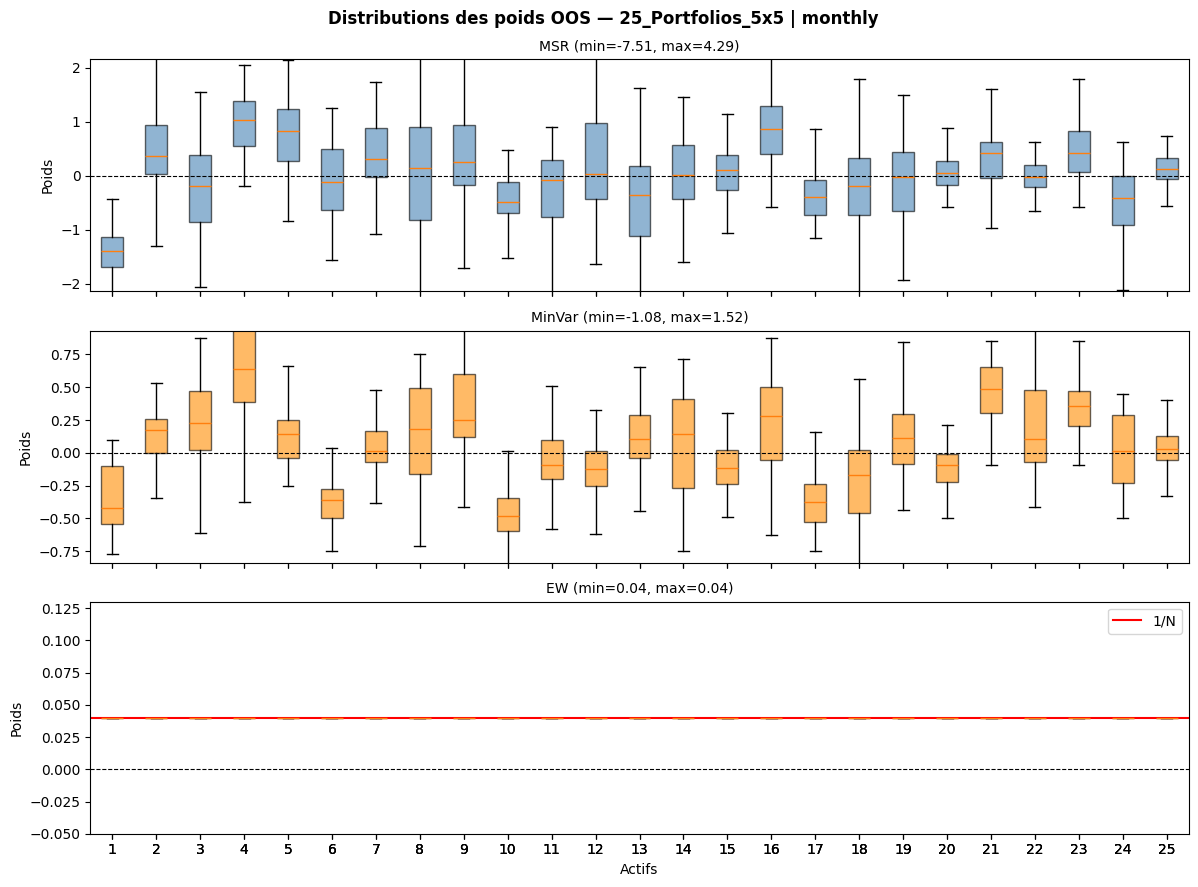


████████████████████████████████████████████████████████████
  25_Portfolios_5x5_daily  |  T=14121, N=25
████████████████████████████████████████████████████████████
  → 93 fenêtres | 11601 périodes OOS

  25_Portfolios_5x5 | DAILY
  Sharpe = Ann.Mean / Ann.Vol  (sans taux sans risque)

  ── IN-SAMPLE ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe
  ────────────────────────────────────────────────────────────
  MSR              0.3288     0.1853     1.7742
  MinVar           0.1601     0.1293     1.2381
  EW               0.1291     0.1748     0.7387

  ── OUT-OF-SAMPLE (rolling 10Y / 6M) ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────
  MSR              0.2771     0.2069     1.3396     2.9545
  MinVar           0.1987     0.1316     1.5099     0.6605
  EW               0.1359     0.1830     0.7425     0.0000


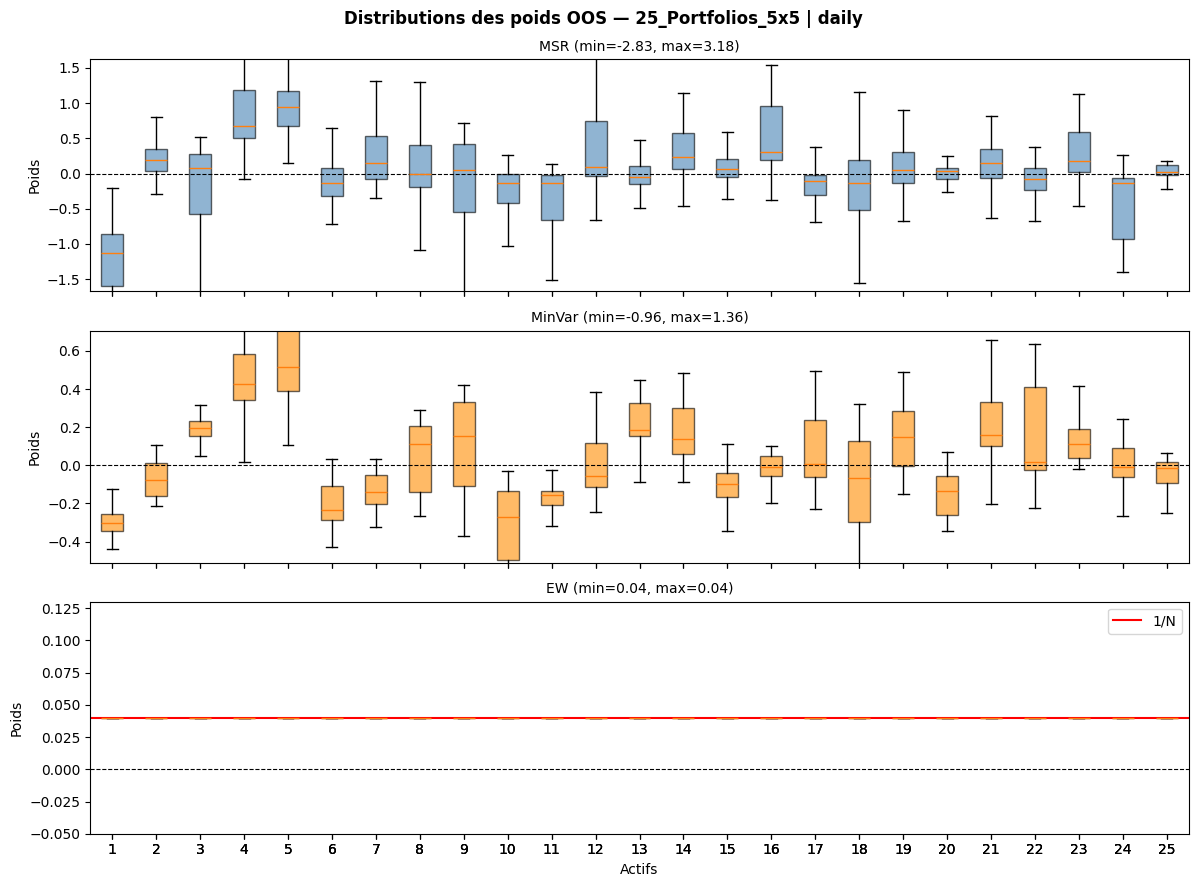


████████████████████████████████████████████████████████████
  100_Portfolios_10x10_monthly  |  T=672, N=100
████████████████████████████████████████████████████████████
  → 92 fenêtres | 552 périodes OOS

  100_Portfolios_10x10 | MONTHLY
  Sharpe = Ann.Mean / Ann.Vol  (sans taux sans risque)

  ── IN-SAMPLE ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe
  ────────────────────────────────────────────────────────────
  MSR              0.4770     0.1938     2.4615
  MinVar           0.1516     0.1092     1.3876
  EW               0.1322     0.1842     0.7179

  ── OUT-OF-SAMPLE (rolling 10Y / 6M) ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────
  MSR              1.5031    15.5141     0.0969   538.3885
  MinVar           0.1814     0.2557     0.7094    16.7240
  EW               0.1363     0.1780     0.7660     0.0000


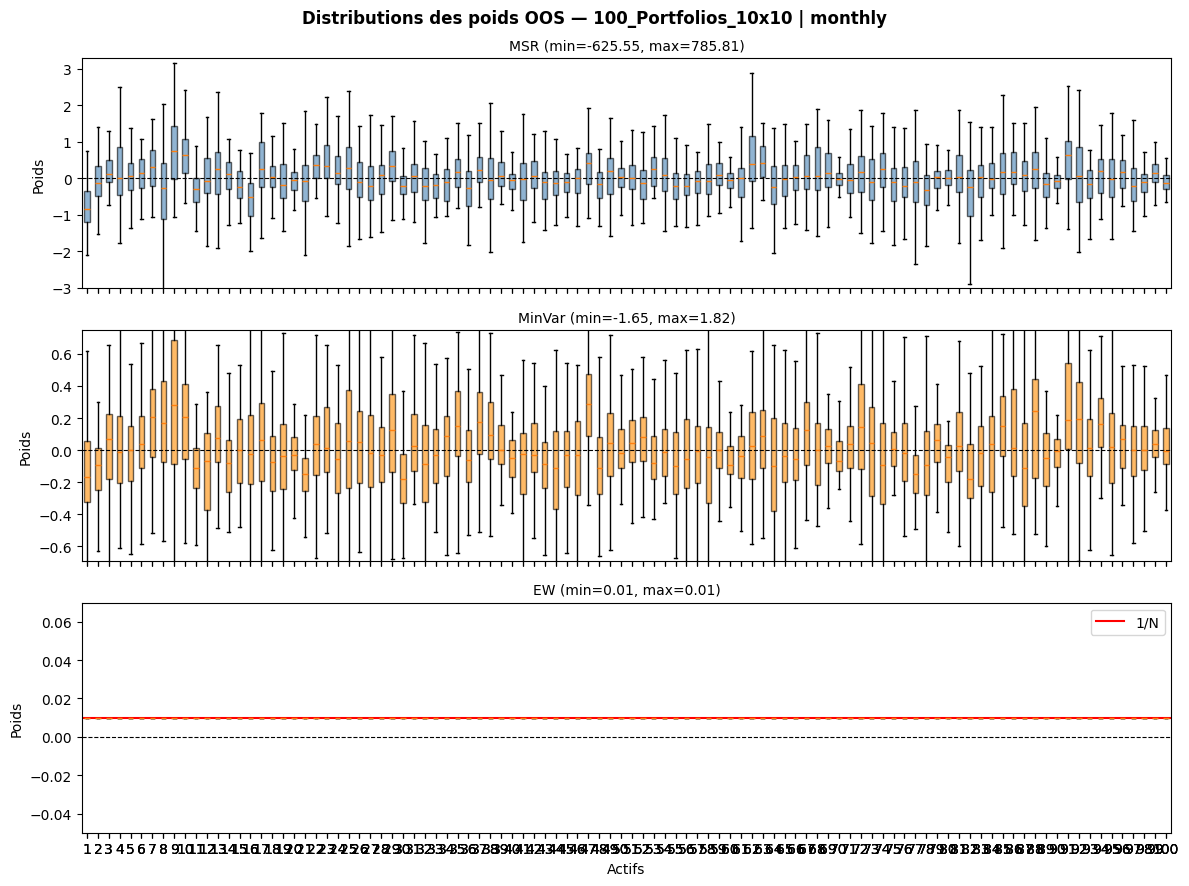


████████████████████████████████████████████████████████████
  100_Portfolios_10x10_daily  |  T=14121, N=100
████████████████████████████████████████████████████████████
  → 93 fenêtres | 11601 périodes OOS

  100_Portfolios_10x10 | DAILY
  Sharpe = Ann.Mean / Ann.Vol  (sans taux sans risque)

  ── IN-SAMPLE ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe
  ────────────────────────────────────────────────────────────
  MSR              0.4182     0.1654     2.5288
  MinVar           0.1748     0.1069     1.6350
  EW               0.1299     0.1750     0.7423

  ── OUT-OF-SAMPLE (rolling 10Y / 6M) ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────
  MSR              0.3363     0.2340     1.4373     5.0130
  MinVar           0.1951     0.1106     1.7645     0.9804
  EW               0.1367     0.1831     0.7469     0.0000


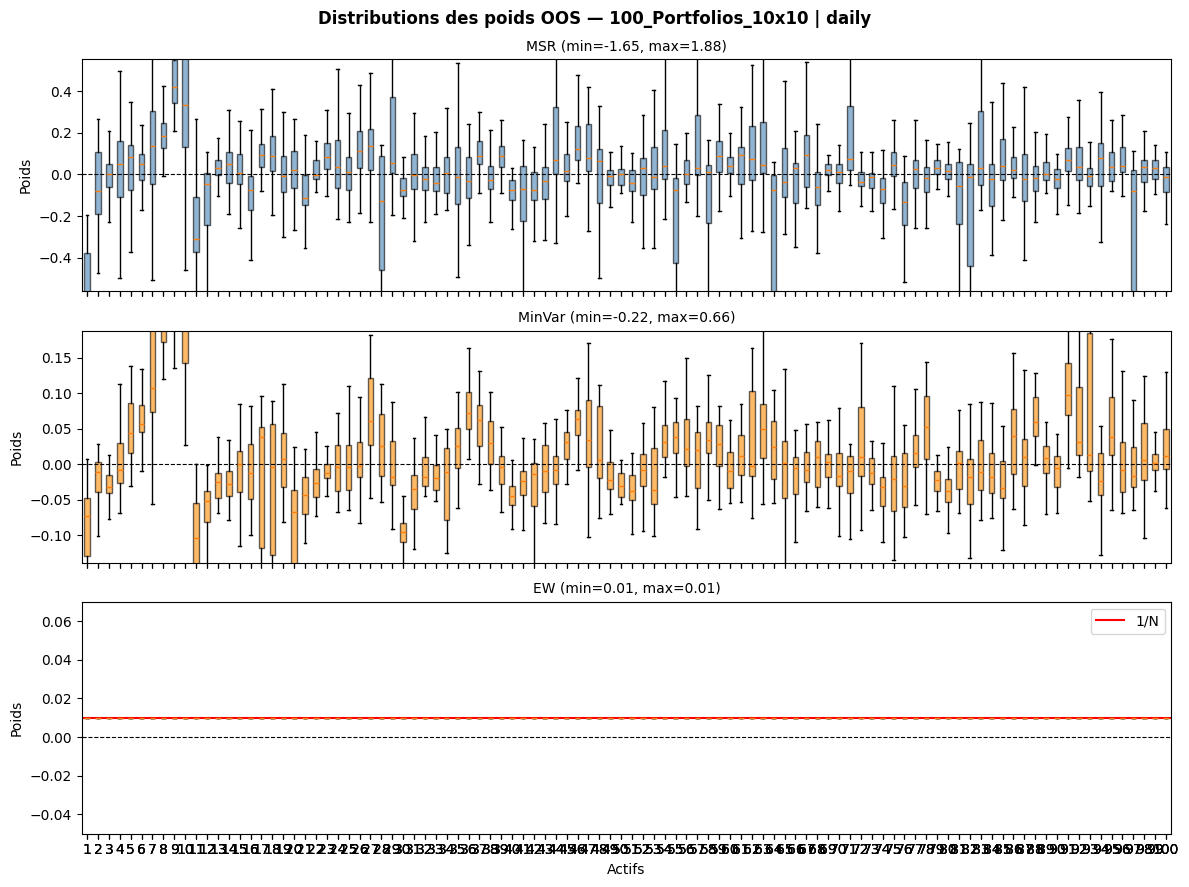


████████████████████████████████████████████████████████████
  10_Industry_Portfolios_monthly  |  T=672, N=10
████████████████████████████████████████████████████████████
  → 92 fenêtres | 552 périodes OOS

  10_Industry_Portfolios | MONTHLY
  Sharpe = Ann.Mean / Ann.Vol  (sans taux sans risque)

  ── IN-SAMPLE ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe
  ────────────────────────────────────────────────────────────
  MSR              0.1236     0.1272     0.9720
  MinVar           0.1161     0.1233     0.9421
  EW               0.1210     0.1504     0.8048

  ── OUT-OF-SAMPLE (rolling 10Y / 6M) ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────
  MSR              0.1199     0.1715     0.6995     1.2353
  MinVar           0.1217     0.1240     0.9816     0.3935
  EW               0.1312     0.1470     0.8925     0.0000


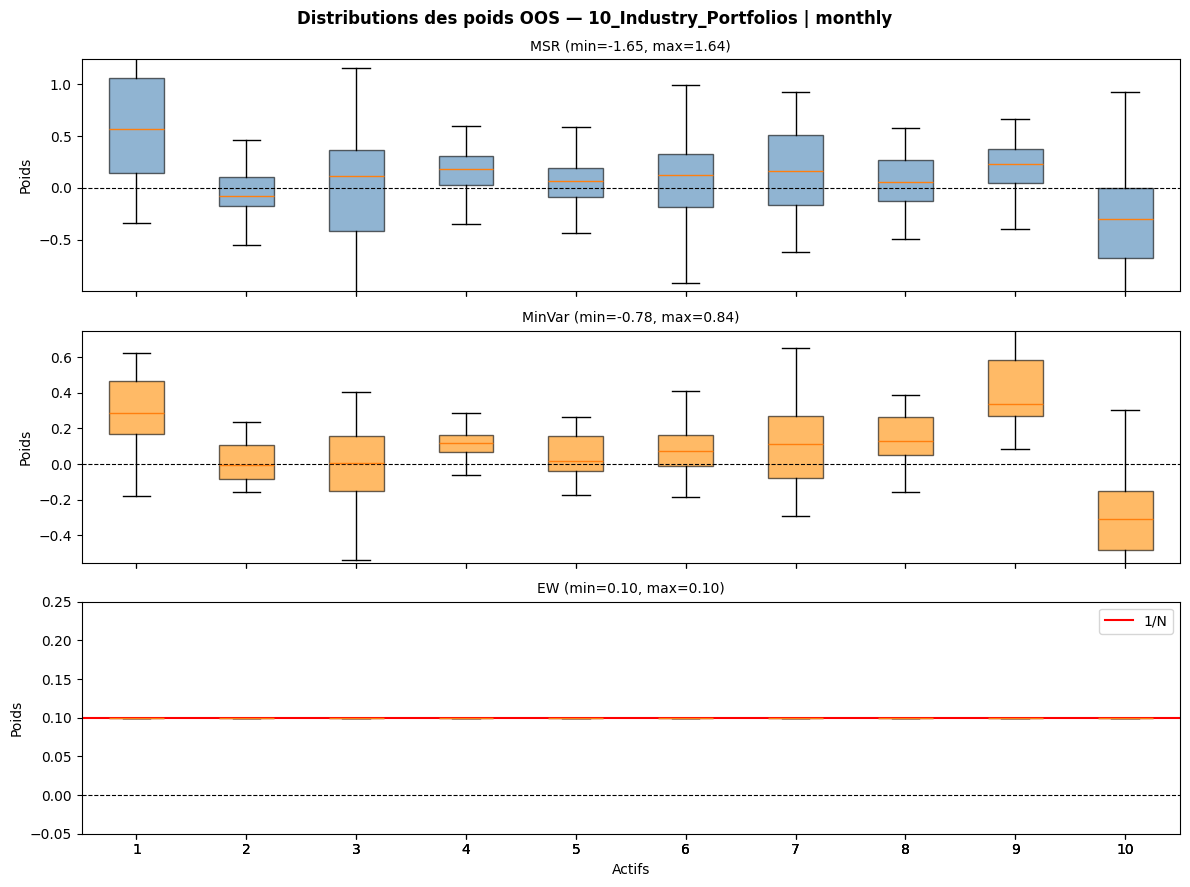


████████████████████████████████████████████████████████████
  10_Industry_Portfolios_daily  |  T=14121, N=10
████████████████████████████████████████████████████████████
  → 93 fenêtres | 11601 périodes OOS

  10_Industry_Portfolios | DAILY
  Sharpe = Ann.Mean / Ann.Vol  (sans taux sans risque)

  ── IN-SAMPLE ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe
  ────────────────────────────────────────────────────────────
  MSR              0.1230     0.1362     0.9032
  MinVar           0.1156     0.1320     0.8754
  EW               0.1217     0.1601     0.7599

  ── OUT-OF-SAMPLE (rolling 10Y / 6M) ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────
  MSR              0.1124     0.2155     0.5215     1.4213
  MinVar           0.1224     0.1340     0.9130     0.2014
  EW               0.1333     0.1662     0.8023     0.0000


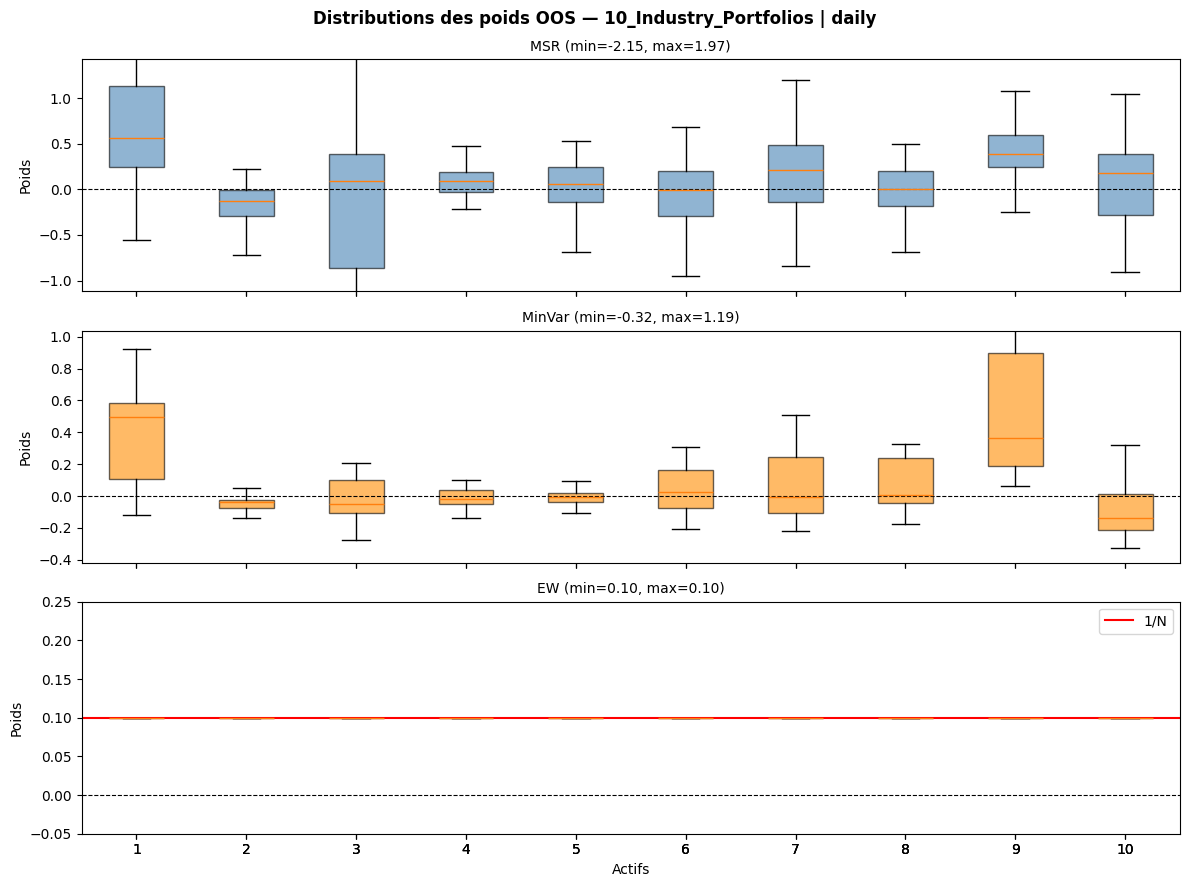


████████████████████████████████████████████████████████████
  48_Industry_Portfolios_monthly  |  T=672, N=48
████████████████████████████████████████████████████████████
  → 92 fenêtres | 552 périodes OOS

  48_Industry_Portfolios | MONTHLY
  Sharpe = Ann.Mean / Ann.Vol  (sans taux sans risque)

  ── IN-SAMPLE ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe
  ────────────────────────────────────────────────────────────
  MSR              0.2354     0.1642     1.4336
  MinVar           0.1062     0.1103     0.9627
  EW               0.1218     0.1706     0.7141

  ── OUT-OF-SAMPLE (rolling 10Y / 6M) ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────
  MSR              0.1449     0.4232     0.3423     8.1396
  MinVar           0.0997     0.1423     0.7006     1.9688
  EW               0.1303     0.1640     0.7947     0.0000


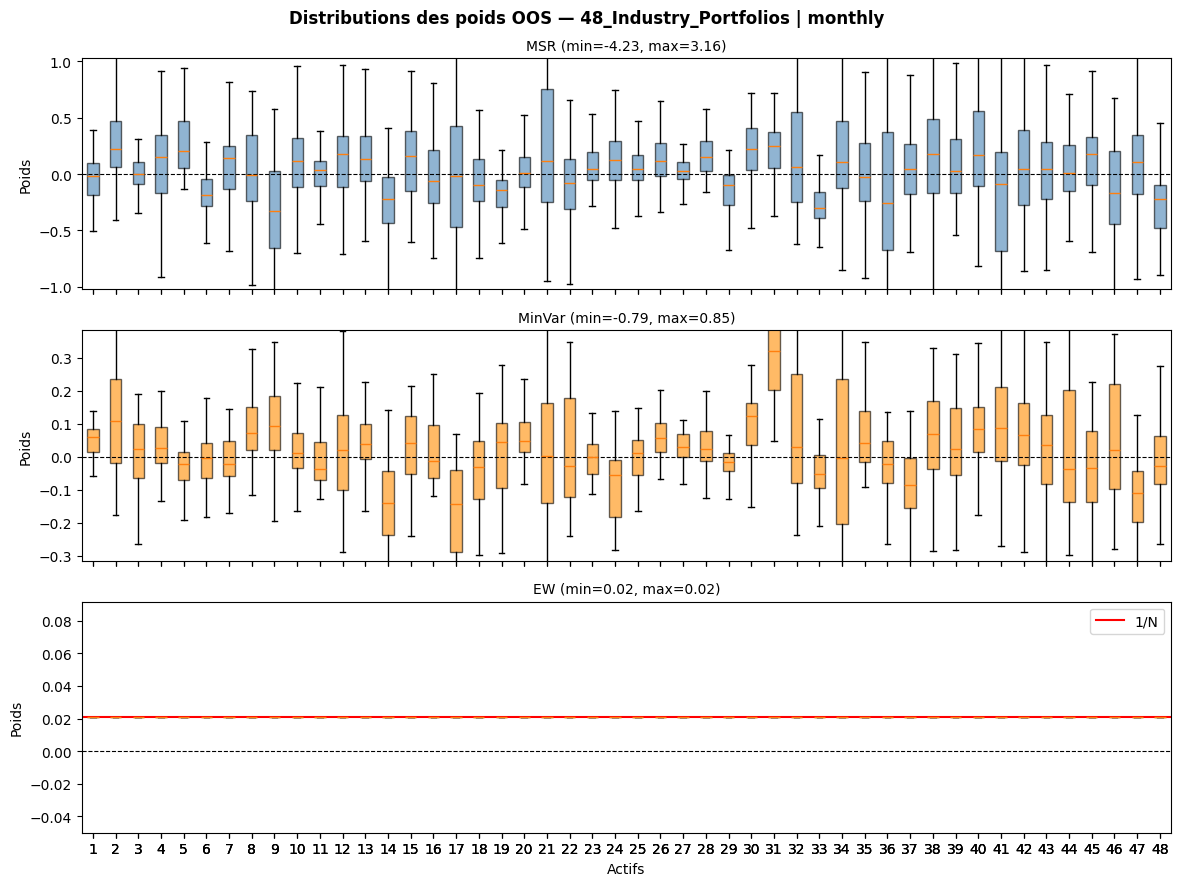


████████████████████████████████████████████████████████████
  48_Industry_Portfolios_daily  |  T=14121, N=48
████████████████████████████████████████████████████████████
  → 93 fenêtres | 11601 périodes OOS

  48_Industry_Portfolios | DAILY
  Sharpe = Ann.Mean / Ann.Vol  (sans taux sans risque)

  ── IN-SAMPLE ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe
  ────────────────────────────────────────────────────────────
  MSR              0.2331     0.1796     1.2982
  MinVar           0.1057     0.1209     0.8743
  EW               0.1208     0.1669     0.7238

  ── OUT-OF-SAMPLE (rolling 10Y / 6M) ──
  Strategy       Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────
  MSR              0.1206     0.3600     0.3350     4.2760
  MinVar           0.1111     0.1241     0.8953     0.4628
  EW               0.1319     0.1722     0.7659     0.0000


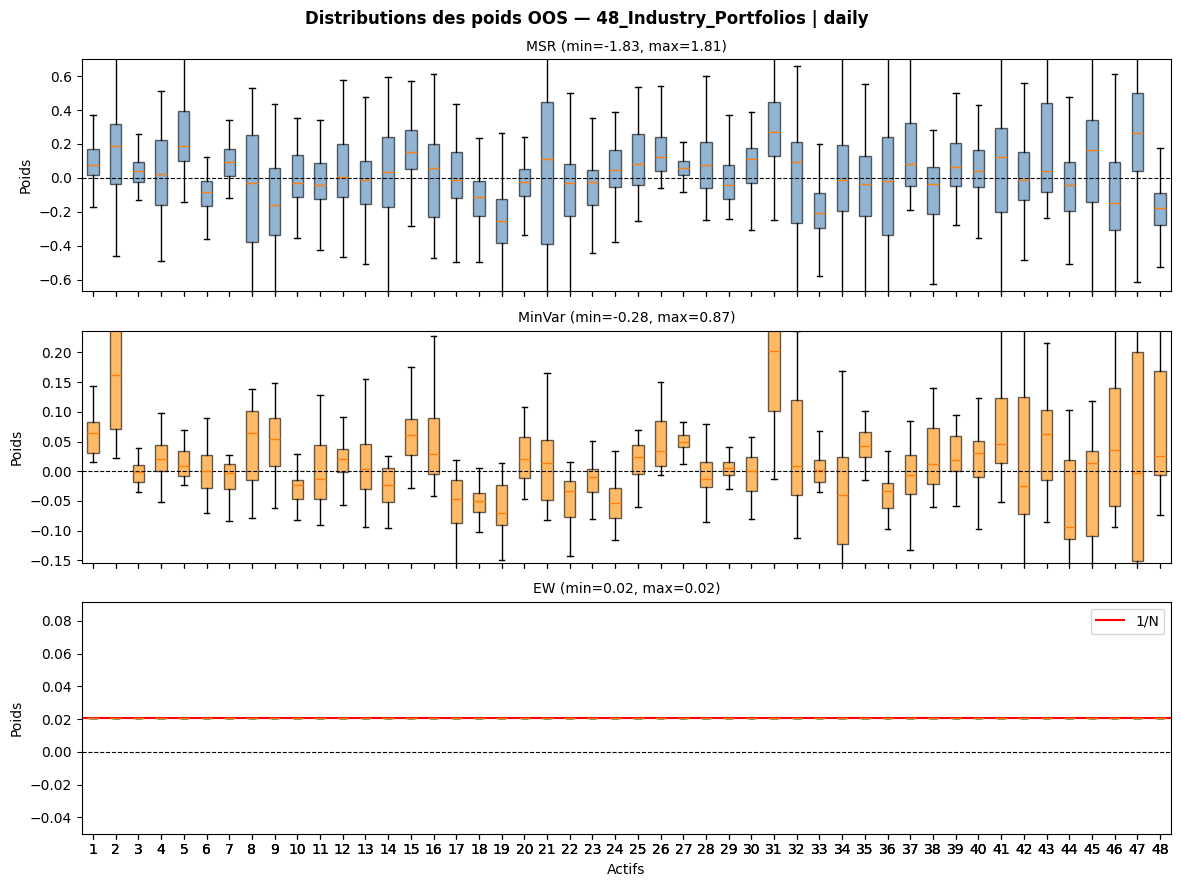

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

#============================================================
#1. OUT-OF-SAMPLE ROLLING ENGINE
#============================================================
def _run_oos_q1(returns: pd.DataFrame, freq: str, strategy: str) -> tuple:

    window, step = get_window_params(freq)
    T, N = returns.shape
    oos, ws = [], []
    t = window

    while t < T:
        s     = min(step, T - t)
        train = returns.iloc[t - window : t]
        test  = returns.iloc[t : t + s]

        if strategy == "msr":
            w = compute_msr(train)
        elif strategy == "minvar":
            w = compute_minvar(train)
        else:
            w = compute_ew(N)

        ws.append(w)
        if np.any(np.isnan(w)):
            oos.extend([np.nan] * s)
        else:
            oos.extend(test.values @ w)
        t += s

    return oos, ws

# ============================================================
# 2. AFFICHAGE DES RÉSULTATS
# ============================================================
def print_q1_results(dataset_name: str, freq: str,
                     res_is: dict, res_oos: dict, to: dict) -> None:
    bar = "─" * 60
    hbar = "=" * 65

    print(f"\n{hbar}")
    print(f"  {dataset_name} | {freq.upper()}")
    print(f"  Sharpe = Ann.Mean / Ann.Vol  (sans taux sans risque)")
    print(hbar)

    print(f"\n  ── IN-SAMPLE ──")
    print(f"  {'Strategy':<12} {'Ann.Mean':>10} {'Ann.Vol':>10} {'Sharpe':>10}")
    print(f"  {bar}")
    for s in ["MSR", "MinVar", "EW"]:
        r = res_is[s]
        print(f"  {s:<12} {r['Mean']:>10.4f} {r['Vol']:>10.4f} {r['Sharpe']:>10.4f}")

    print(f"\n  ── OUT-OF-SAMPLE (rolling 10Y / 6M) ──")
    print(f"  {'Strategy':<12} {'Ann.Mean':>10} {'Ann.Vol':>10} {'Sharpe':>10} {'Turnover':>10}")
    print(f"  {bar}")
    for s in ["MSR", "MinVar", "EW"]:
        r = res_oos[s]
        tv = to.get(s, np.nan)
        print(f"  {s:<12} {r['Mean']:>10.4f} {r['Vol']:>10.4f} {r['Sharpe']:>10.4f} {tv:>10.4f}")

# ============================================================
# 3. BOXPLOTS ROBUSTES (INSPIRÉ DE TA V1)
# ============================================================
def plot_q1_boxplots(all_ws: dict, dataset_name: str, freq: str) -> None:
    """Boxplots des distributions de poids OOS avec gestion des extrêmes."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    strategies = ['MSR', 'MinVar', 'EW']
    colors = ['steelblue', 'darkorange', 'mediumseagreen']

    N = len(all_ws["EW"][0])

    for ax, strat, color in zip(axes, strategies, colors):
        W = np.array([w for w in all_ws[strat] if w is not None and not np.any(np.isnan(w))])

        if W.size == 0:
            ax.set_title(f"{strat} — aucun poids valide")
            continue

        ax.boxplot(W, patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor=color, alpha=0.6))

        flat = W.flatten()

        if strat == 'MSR' or strat == 'MinVar':
            q1, q99 = np.nanpercentile(flat, [5, 95]) # Coupure à 5%/95% pour la lisibilité
            margin = 0.2 * (q99 - q1) if q99 > q1 else 0.1
            ax.set_ylim(q1 - margin, q99 + margin)

        if strat == 'EW':
            ax.axhline(1/N, color='red', lw=1.5, ls='-', label='1/N')
            ax.set_ylim(-0.05, (2/N) + 0.05)
            ax.legend()

        ax.axhline(0, color="black", lw=0.8, ls="--")
        ax.set_title(f"{strat} (min={np.nanmin(flat):.2f}, max={np.nanmax(flat):.2f})", fontsize=10)
        ax.set_ylabel("Poids")

    axes[-1].set_xlabel("Actifs")
    fig.suptitle(f"Distributions des poids OOS — {dataset_name} | {freq}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = f"boxplots_Q1_{dataset_name}_{freq}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def run_question1(all_data: dict) -> dict:
    print("\n" + "█" * 70)
    print("  QUESTION 1 — MSR | MinVar | EW  (rolling OOS 10Y / 6M)")
    print("█" * 70)

    all_results = {}

    for key, returns in all_data.items():
        name, freq = key.rsplit("_", 1)
        T, N = returns.shape
        window, step = get_window_params(freq)
        n_windows = max(0, (T - window + step - 1) // step)
        n_oos     = max(0, T - window)

        print(f"\n{'█'*60}")
        print(f"  {key}  |  T={T}, N={N}")
        print(f"{'█'*60}")
        print(f"  → {n_windows} fenêtres | {n_oos} périodes OOS")

        # ── In-sample ──
        res_is = {}
        for s, fn in [("MSR", compute_msr), ("MinVar", compute_minvar)]:
            w  = fn(returns)
            r  = returns.values @ w if not np.any(np.isnan(w)) else [np.nan]
            res_is[s] = compute_performance(r, freq)

        w_ew = compute_ew(N)
        res_is["EW"] = compute_performance(returns.values @ w_ew, freq)

        # ── OOS ──
        res_oos, turnovers, all_ws = {}, {}, {}
        for strat in ["msr", "minvar", "ew"]:
            oos, ws = _run_oos_q1(returns, freq, strat)
            label = {"msr": "MSR", "minvar": "MinVar", "ew": "EW"}[strat]
            res_oos[label]   = compute_performance(oos, freq)
            turnovers[label] = compute_turnover(ws)
            all_ws[label]    = ws

        print_q1_results(name, freq, res_is, res_oos, turnovers)
        plot_q1_boxplots(all_ws, name, freq)

        all_results[key] = {
            'is': res_is, 'oos': res_oos, 'turnover': turnovers, 'weights': all_ws
        }

    return all_results

# Lancement
results_q1 = run_question1(all_data)

## **Question 2**


██████████████████████████████████████████████████████████████████████
  QUESTION 2 — MinVar ℓ₂ / Ridge  (grille γ, γ normalisé)
██████████████████████████████████████████████████████████████████████

██████████████████████████████████████████████████████████████████████
  Q2 | 25_Portfolios_5x5_monthly | T=672, N=25
██████████████████████████████████████████████████████████████████████

  25_Portfolios_5x5 | MONTHLY
  γ                 Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (0.0)        0.1791     0.1355     1.3219     2.0160     0.0000
  ℓ₂ (0.001)          0.1785     0.1345     1.3275     1.9262     0.0000
  ℓ₂ (0.002)          0.1779     0.1336     1.3318     1.8472     0.0000
  ℓ₂ (0.005)          0.1764     0.1317     1.3400     1.6575     0.0000
  ℓ₂ (0.01)           0.1744     0.1297     1.3447     1.4383     0.0000
  ℓ₂ (0.02)           0.1715     0.1279     1.3409     1.1688     0

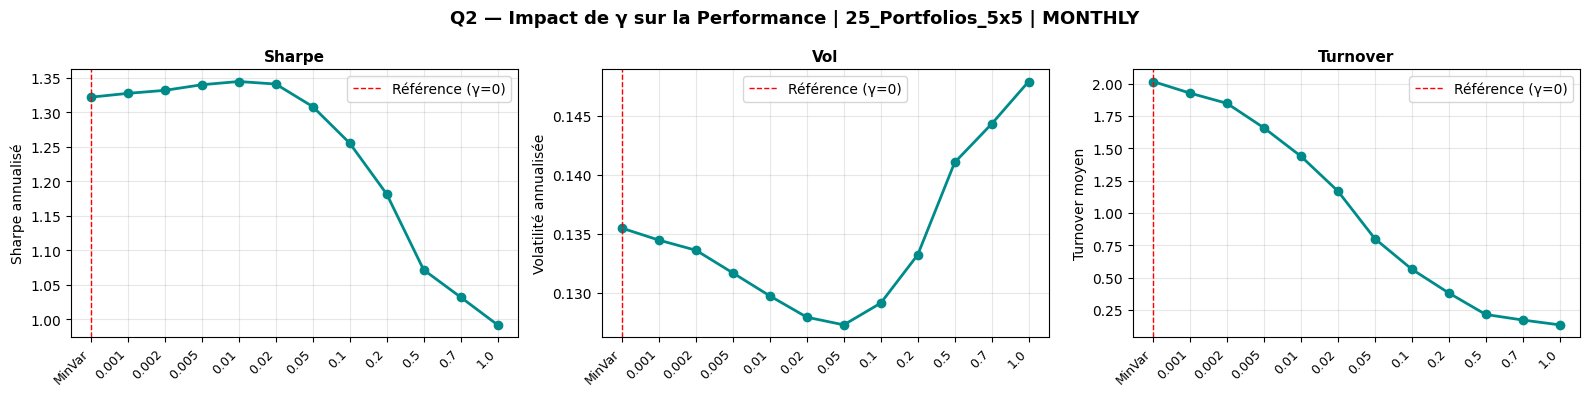

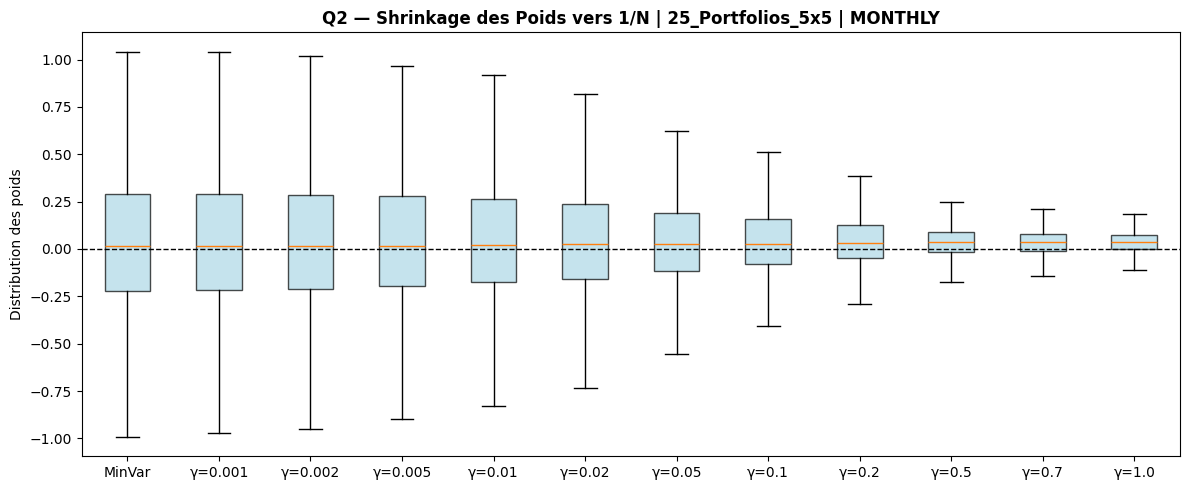


██████████████████████████████████████████████████████████████████████
  Q2 | 25_Portfolios_5x5_daily | T=14121, N=25
██████████████████████████████████████████████████████████████████████

  25_Portfolios_5x5 | DAILY
  γ                 Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (0.0)        0.1987     0.1316     1.5099     0.6605     0.0000
  ℓ₂ (0.001)          0.1982     0.1313     1.5098     0.6467     0.0000
  ℓ₂ (0.002)          0.1977     0.1310     1.5095     0.6339     0.0000
  ℓ₂ (0.005)          0.1964     0.1302     1.5076     0.6004     0.0000
  ℓ₂ (0.01)           0.1944     0.1294     1.5021     0.5561     0.0000
  ℓ₂ (0.02)           0.1913     0.1287     1.4867     0.4920     0.0000
  ℓ₂ (0.05)           0.1853     0.1292     1.4342     0.3827     0.0000
  ℓ₂ (0.1)            0.1795     0.1320     1.3600     0.2978     0.0000
  ℓ₂ (0.2)            0.1727     0.1373     1.2576 

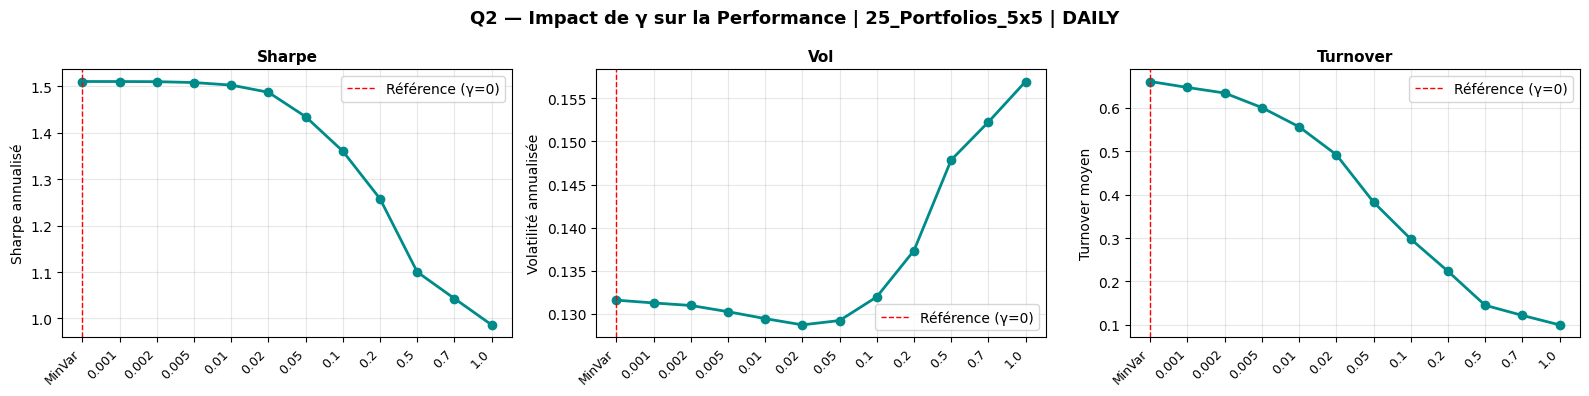

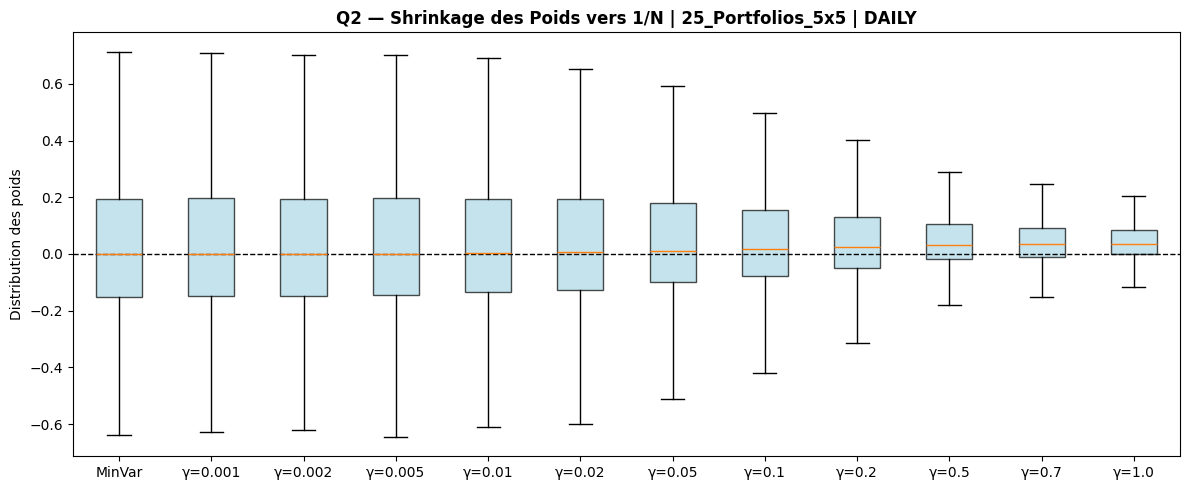


██████████████████████████████████████████████████████████████████████
  Q2 | 100_Portfolios_10x10_monthly | T=672, N=100
██████████████████████████████████████████████████████████████████████

  100_Portfolios_10x10 | MONTHLY
  γ                 Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (0.0)        0.1814     0.2557     0.7094    16.7240     0.0000
  ℓ₂ (0.001)          0.1873     0.2149     0.8717    11.4636     0.0000
  ℓ₂ (0.002)          0.1921     0.1987     0.9666     9.4364     0.0000
  ℓ₂ (0.005)          0.1988     0.1767     1.1251     6.8623     0.0000
  ℓ₂ (0.01)           0.2013     0.1614     1.2472     5.1914     0.0000
  ℓ₂ (0.02)           0.1996     0.1486     1.3439     3.8344     0.0000
  ℓ₂ (0.05)           0.1913     0.1362     1.4040     2.4969     0.0000
  ℓ₂ (0.1)            0.1824     0.1306     1.3968     1.7612     0.0000
  ℓ₂ (0.2)            0.1732     0.1280   

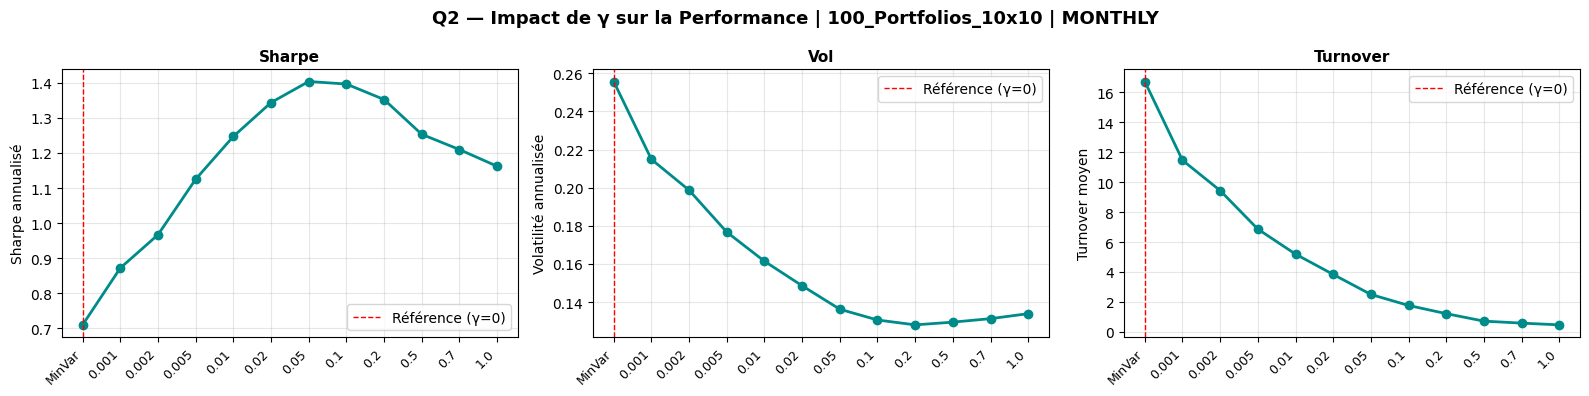

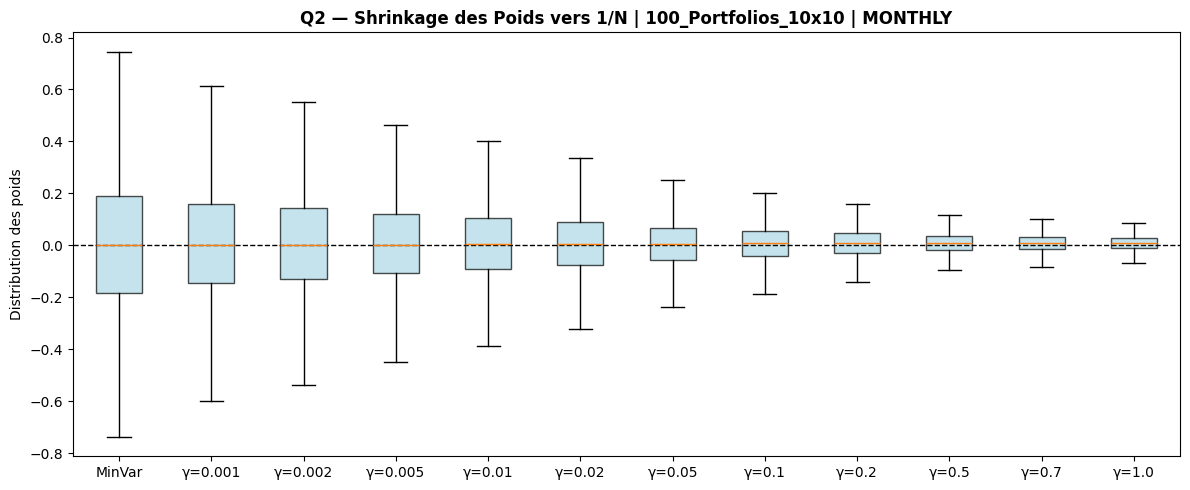


██████████████████████████████████████████████████████████████████████
  Q2 | 100_Portfolios_10x10_daily | T=14121, N=100
██████████████████████████████████████████████████████████████████████

  100_Portfolios_10x10 | DAILY
  γ                 Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (0.0)        0.1951     0.1106     1.7645     0.9804     0.0000
  ℓ₂ (0.001)          0.1948     0.1105     1.7624     0.9723     0.0000
  ℓ₂ (0.002)          0.1945     0.1105     1.7603     0.9646     0.0000
  ℓ₂ (0.005)          0.1938     0.1105     1.7542     0.9427     0.0000
  ℓ₂ (0.01)           0.1926     0.1104     1.7443     0.9101     0.0000
  ℓ₂ (0.02)           0.1906     0.1104     1.7258     0.8556     0.0000
  ℓ₂ (0.05)           0.1862     0.1110     1.6779     0.7428     0.0000
  ℓ₂ (0.1)            0.1815     0.1123     1.6157     0.6294     0.0000
  ℓ₂ (0.2)            0.1759     0.1151     

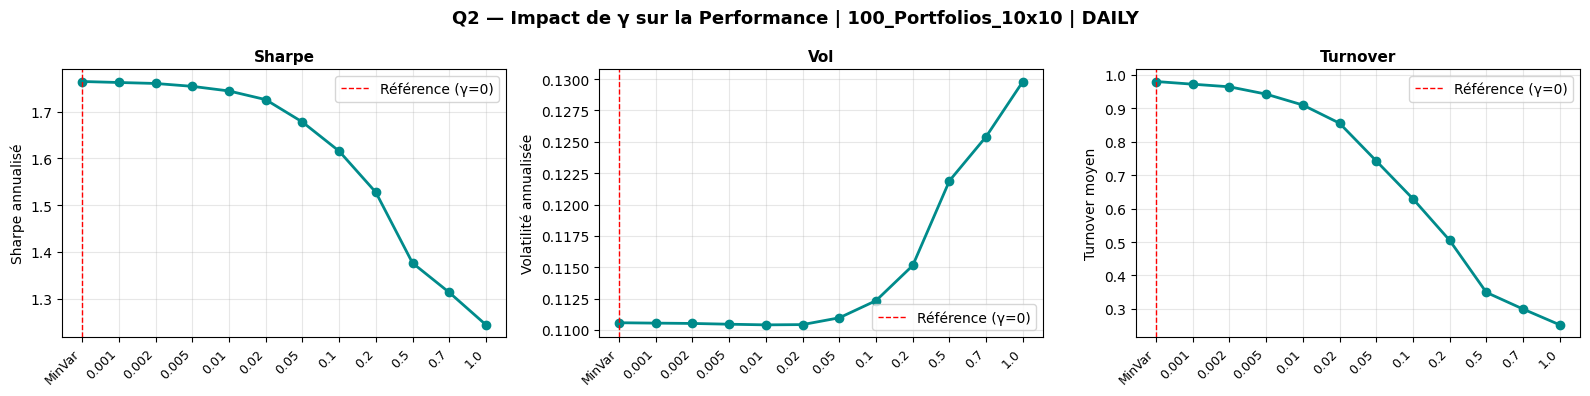

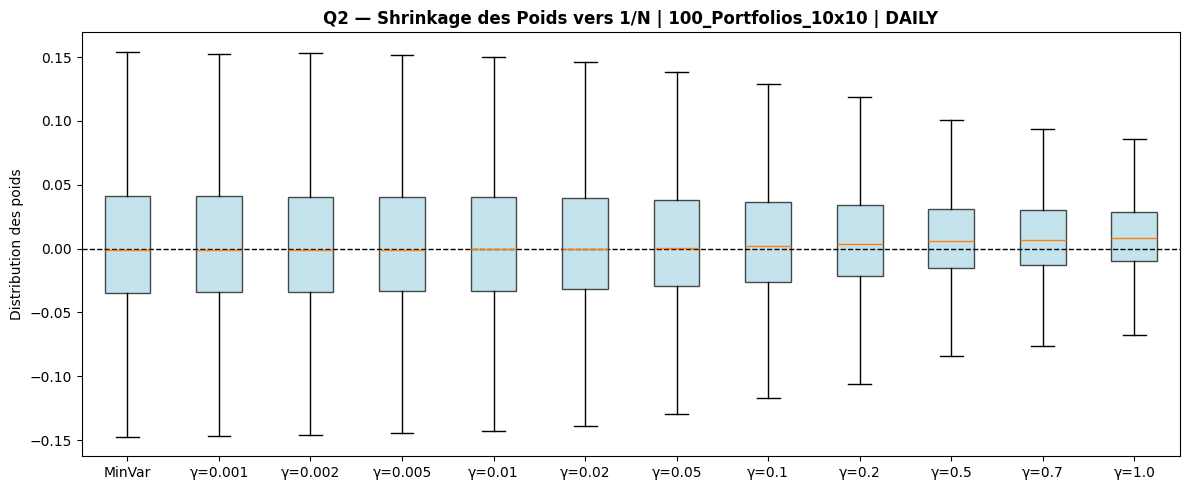


██████████████████████████████████████████████████████████████████████
  Q2 | 10_Industry_Portfolios_monthly | T=672, N=10
██████████████████████████████████████████████████████████████████████

  10_Industry_Portfolios | MONTHLY
  γ                 Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (0.0)        0.1217     0.1240     0.9816     0.3935     0.0000
  ℓ₂ (0.001)          0.1217     0.1239     0.9824     0.3894     0.0000
  ℓ₂ (0.002)          0.1217     0.1238     0.9831     0.3855     0.0000
  ℓ₂ (0.005)          0.1217     0.1235     0.9853     0.3745     0.0000
  ℓ₂ (0.01)           0.1217     0.1231     0.9885     0.3582     0.0000
  ℓ₂ (0.02)           0.1217     0.1225     0.9937     0.3313     0.0000
  ℓ₂ (0.05)           0.1217     0.1213     1.0036     0.2768     0.0000
  ℓ₂ (0.1)            0.1219     0.1205     1.0115     0.2242     0.0000
  ℓ₂ (0.2)            0.1223     0.1203

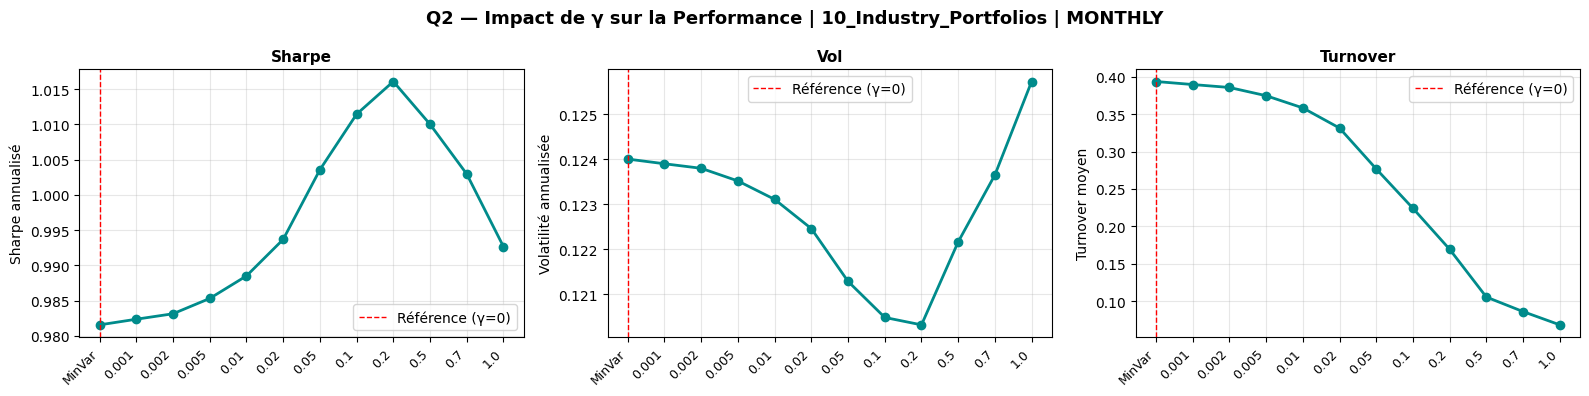

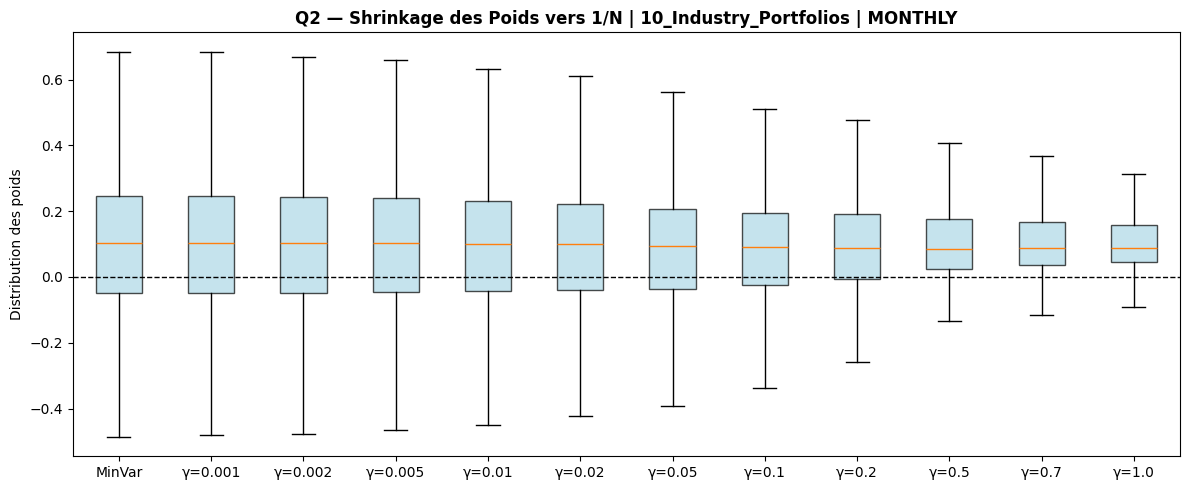


██████████████████████████████████████████████████████████████████████
  Q2 | 10_Industry_Portfolios_daily | T=14121, N=10
██████████████████████████████████████████████████████████████████████

  10_Industry_Portfolios | DAILY
  γ                 Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (0.0)        0.1224     0.1340     0.9130     0.2014     0.0000
  ℓ₂ (0.001)          0.1224     0.1340     0.9134     0.1997     0.0000
  ℓ₂ (0.002)          0.1224     0.1339     0.9138     0.1980     0.0000
  ℓ₂ (0.005)          0.1225     0.1338     0.9150     0.1934     0.0000
  ℓ₂ (0.01)           0.1226     0.1337     0.9169     0.1864     0.0000
  ℓ₂ (0.02)           0.1229     0.1335     0.9201     0.1747     0.0000
  ℓ₂ (0.05)           0.1237     0.1335     0.9269     0.1504     0.0000
  ℓ₂ (0.1)            0.1249     0.1340     0.9321     0.1257     0.0000
  ℓ₂ (0.2)            0.1266     0.1358  

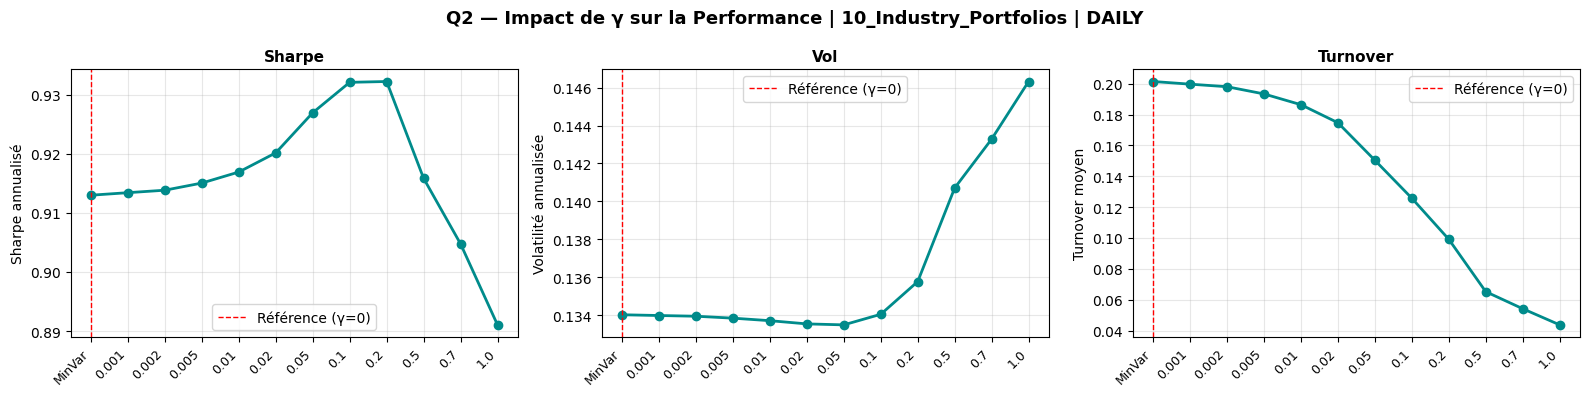

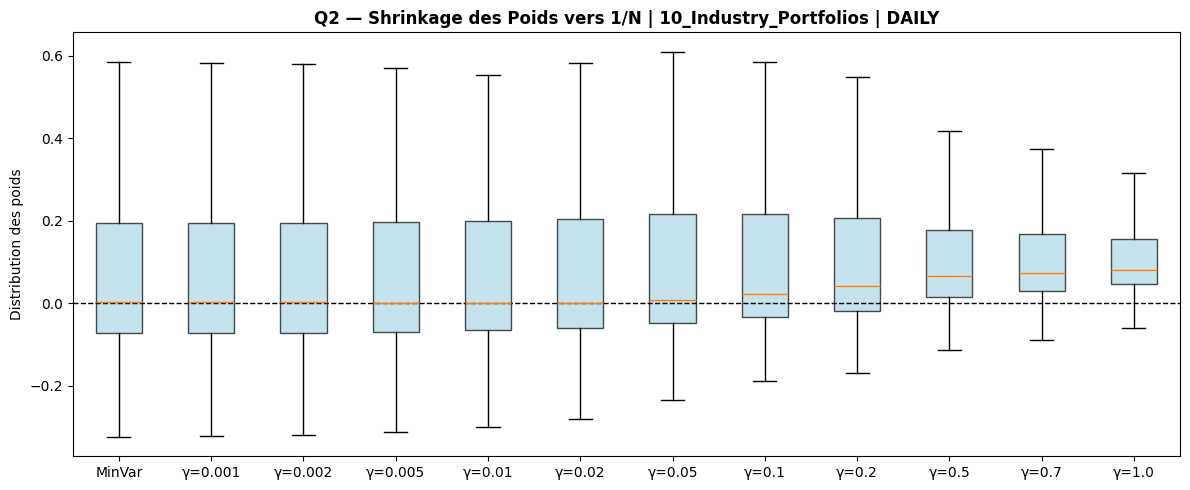


██████████████████████████████████████████████████████████████████████
  Q2 | 48_Industry_Portfolios_monthly | T=672, N=48
██████████████████████████████████████████████████████████████████████

  48_Industry_Portfolios | MONTHLY
  γ                 Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (0.0)        0.0997     0.1423     0.7006     1.9688     0.0000
  ℓ₂ (0.001)          0.0999     0.1413     0.7072     1.9145     0.0000
  ℓ₂ (0.002)          0.1001     0.1403     0.7134     1.8653     0.0000
  ℓ₂ (0.005)          0.1007     0.1378     0.7305     1.7398     0.0000
  ℓ₂ (0.01)           0.1016     0.1347     0.7544     1.5816     0.0000
  ℓ₂ (0.02)           0.1034     0.1307     0.7914     1.3689     0.0000
  ℓ₂ (0.05)           0.1074     0.1248     0.8610     1.0360     0.0000
  ℓ₂ (0.1)            0.1117     0.1210     0.9230     0.7858     0.0000
  ℓ₂ (0.2)            0.1162     0.1186

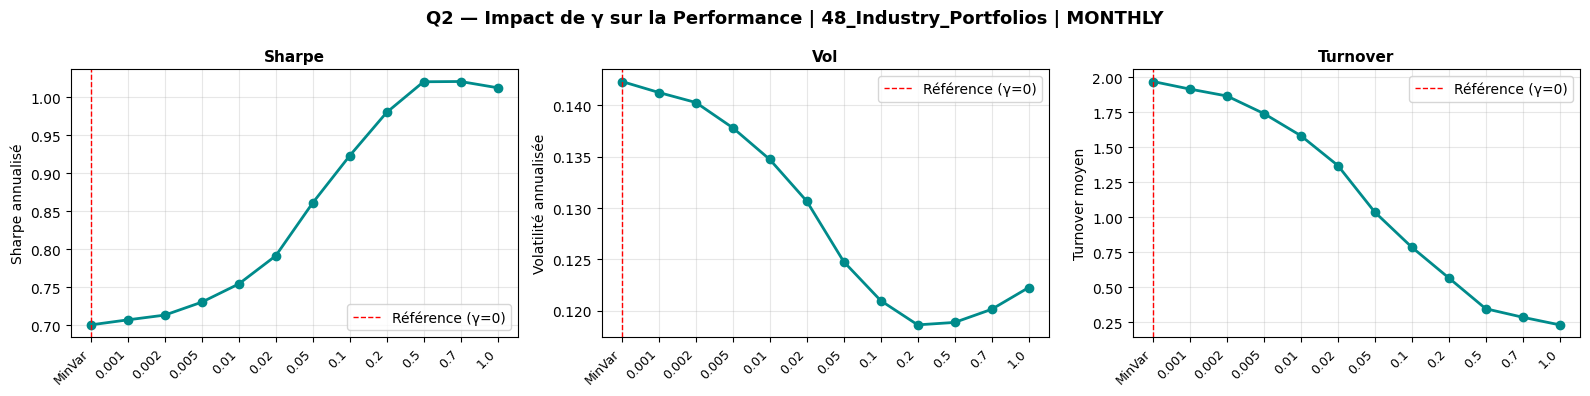

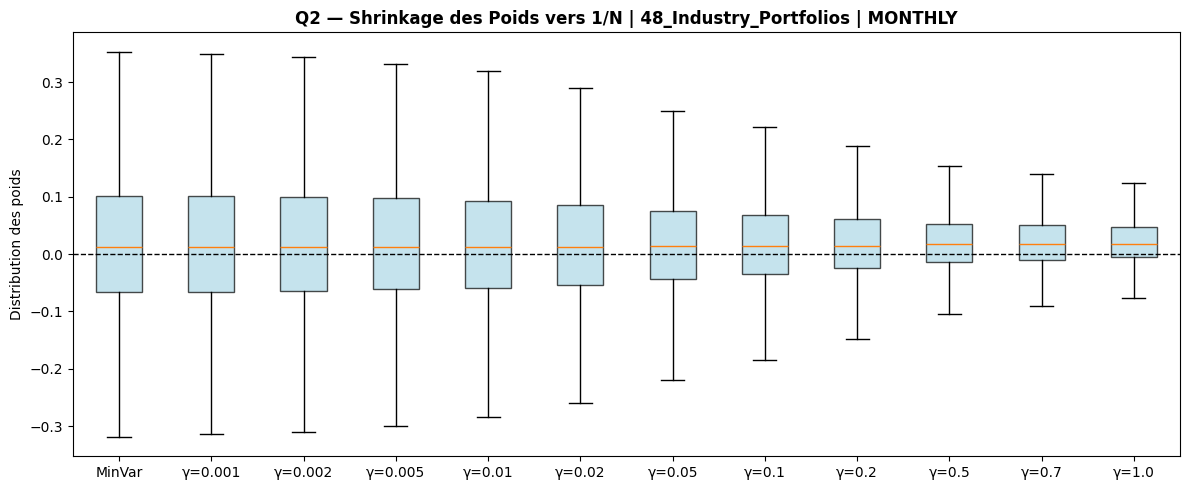


██████████████████████████████████████████████████████████████████████
  Q2 | 48_Industry_Portfolios_daily | T=14121, N=48
██████████████████████████████████████████████████████████████████████

  48_Industry_Portfolios | DAILY
  γ                 Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (0.0)        0.1111     0.1241     0.8953     0.4628     0.0000
  ℓ₂ (0.001)          0.1112     0.1240     0.8965     0.4597     0.0000
  ℓ₂ (0.002)          0.1113     0.1240     0.8976     0.4567     0.0000
  ℓ₂ (0.005)          0.1116     0.1238     0.9009     0.4481     0.0000
  ℓ₂ (0.01)           0.1120     0.1237     0.9058     0.4350     0.0000
  ℓ₂ (0.02)           0.1128     0.1234     0.9140     0.4126     0.0000
  ℓ₂ (0.05)           0.1146     0.1231     0.9309     0.3638     0.0000
  ℓ₂ (0.1)            0.1166     0.1231     0.9467     0.3121     0.0000
  ℓ₂ (0.2)            0.1192     0.1240  

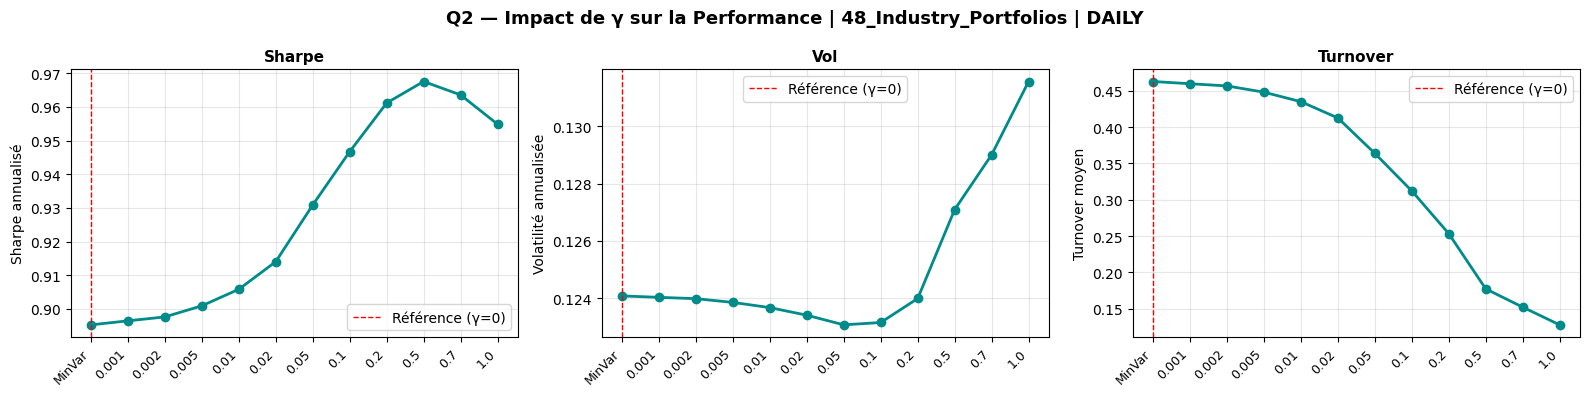

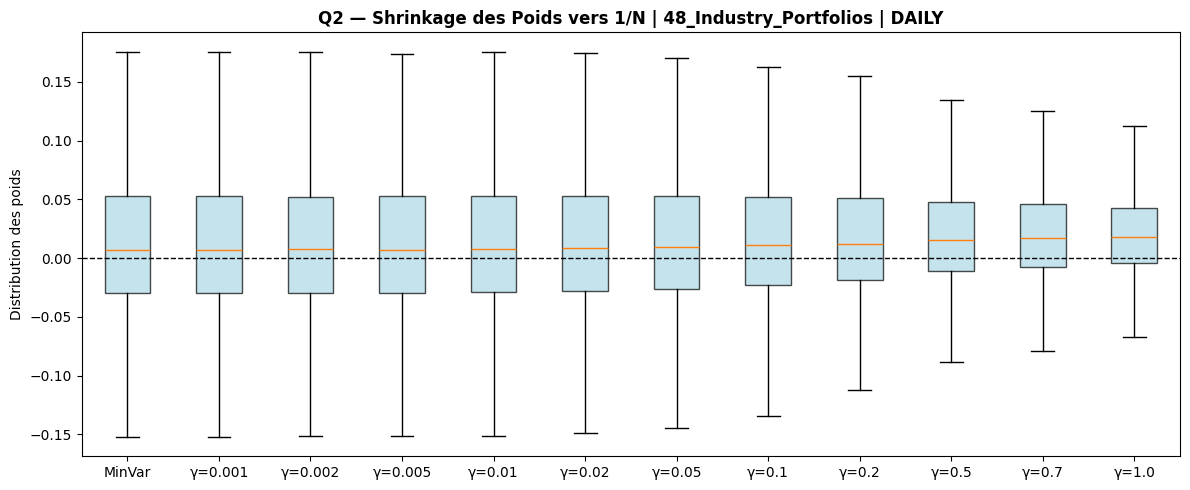

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# 1. CALCULATEUR MINVAR ℓ2 (RIDGE)
# ─────────────────────────────────────────────────────────────────────────────
def compute_minvar_l2(Sigma: np.ndarray, gamma_raw: float, tol: float = 1e-12) -> np.ndarray:

    Sigma = np.atleast_2d(Sigma)
    Sigma = (Sigma + Sigma.T) / 2
    N     = Sigma.shape[0]
    ones  = np.ones(N)

    # ── Normalisation γ ──
    trace_mean   = np.trace(Sigma) / N
    gamma_scaled = gamma_raw * trace_mean

    Sigma_reg = Sigma + gamma_scaled * np.eye(N)

    try:
        w = np.linalg.solve(Sigma_reg, ones)
    except np.linalg.LinAlgError:
        w = np.linalg.pinv(Sigma_reg) @ ones

    denom = ones @ w

    if abs(denom) < tol:
        return np.full(N, np.nan)

    return w / denom


# ─────────────────────────────────────────────────────────────────────────────
# 2. OUT-OF-SAMPLE ENGINE POUR ℓ2
# ─────────────────────────────────────────────────────────────────────────────
def _oos_l2(returns: pd.DataFrame, freq: str, gamma: float) -> tuple:
    """OOS rolling pour MinVar ℓ₂ avec un γ fixé."""
    window, step = get_window_params(freq)
    T, N = returns.shape
    oos, ws = [], []
    t = window

    while t < T:
        s     = min(step, T - t)
        train = returns.iloc[t - window : t]
        test  = returns.iloc[t : t + s]

        Sigma = train.cov().values
        w = compute_minvar_l2(Sigma, gamma)
        ws.append(w)

        if np.any(np.isnan(w)):
            oos.extend([np.nan] * s)
        else:
            oos.extend(test.values @ w)

        t += s

    return oos, ws


def _plot_q2_gamma_perf(results_g: dict, gammas: list, name: str, freq: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    labels = ["MinVar"] + [f"{g}" for g in gammas]
    metrics = ["Sharpe", "Vol", "Turnover"]  # Remplacé 'Mean' par 'Turnover' (plus pertinent)
    ylabels = ["Sharpe annualisé", "Volatilité annualisée", "Turnover moyen"]
    keys    = ["MinVar"] + gammas

    for ax, met, yl in zip(axes, metrics, ylabels):
        # Le turnover est stocké à l'index [1] dans results_g, la perf à l'index [0]
        if met == "Turnover":
            vals = [results_g[k][1] for k in keys]
        else:
            vals = [results_g[k][0].get(met, np.nan) for k in keys]

        ax.plot(range(len(labels)), vals, "o-", lw=2, color="darkcyan")
        ax.axvline(x=0, color="red", linestyle="--", linewidth=1, label="Référence (γ=0)")
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
        ax.set_ylabel(yl, fontsize=10)
        ax.set_title(met, fontsize=11, fontweight="bold")
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle(f"Q2 — Impact de γ sur la Performance | {name} | {freq.upper()}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = f"q2_gamma_perf_{name}_{freq}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()  # <--- AFFICHE LE GRAPHIQUE
    plt.close()


def _plot_q2_boxplots(results_g: dict, gammas: list, name: str, freq: str) -> None:
    keys   = ["MinVar"] + gammas
    labels = ["MinVar"] + [f"γ={g}" for g in gammas]

    fig, ax = plt.subplots(figsize=(12, 5))
    data = []

    for k in keys:
        ws = results_g[k][2]
        W  = np.array([w for w in ws if w is not None and not np.any(np.isnan(w))])
        data.append(W.flatten() if W.size > 0 else [np.nan])

    box = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)

    for patch in box['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)

    ax.set_ylabel("Distribution des poids", fontsize=10)
    ax.set_title(f"Q2 — Shrinkage des Poids vers 1/N | {name} | {freq.upper()}", fontsize=12, fontweight="bold")
    ax.axhline(0, color="black", lw=1, ls="--")

    plt.tight_layout()
    fname = f"q2_boxplots_{name}_{freq}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()  # <--- AFFICHE LE GRAPHIQUE
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# 4. PIPELINE PRINCIPAL Q2
# ─────────────────────────────────────────────────────────────────────────────
def run_question2(all_data: dict, gammas: list = None) -> dict:
    if gammas is None:
        gammas = [0.0001, 0.001, 0.01, 0.1, 1.0]

    print("\n" + "█" * 70)
    print("  QUESTION 2 — MinVar ℓ₂ / Ridge  (grille γ, γ normalisé)")
    print("█" * 70)

    all_results_q2 = {}

    for key, returns in all_data.items():
        name, freq = key.rsplit("_", 1)
        T, N = returns.shape

        print(f"\n{'█'*70}")
        print(f"  Q2 | {key} | T={T}, N={N}")
        print(f"{'█'*70}")

        # Référence MinVar (γ=0)
        oos_ref, ws_ref = _oos_l2(returns, freq, 0.0)
        perf_ref  = compute_performance(oos_ref, freq)
        to_ref    = compute_turnover(ws_ref)

        print(f"\n{'='*80}")
        print(f"  {name} | {freq.upper()}")
        print(f"{'='*80}")

        hdr = (f"  {'γ':<15} {'Ann.Mean':>10} {'Ann.Vol':>10} "
               f"{'Sharpe':>10} {'Turnover':>10} {'FailRate':>10}")
        bar = "  " + "─" * 70
        print(hdr); print(bar)

        print(f"  {'MinVar (0.0)':<15} {perf_ref['Mean']:>10.4f} "
              f"{perf_ref['Vol']:>10.4f} {perf_ref['Sharpe']:>10.4f} "
              f"{to_ref:>10.4f} {perf_ref['FailRate']:>10.4f}")

        results_g = {"MinVar": (perf_ref, to_ref, ws_ref)}

        for g in gammas:
            oos_g, ws_g = _oos_l2(returns, freq, g)
            perf_g = compute_performance(oos_g, freq)
            to_g   = compute_turnover(ws_g)
            results_g[g] = (perf_g, to_g, ws_g)

            label = f"ℓ₂ ({g})"
            print(f"  {label:<15} {perf_g['Mean']:>10.4f} "
                  f"{perf_g['Vol']:>10.4f} {perf_g['Sharpe']:>10.4f} "
                  f"{to_g:>10.4f} {perf_g['FailRate']:>10.4f}")

        # ── Affichage des Graphiques ──
        _plot_q2_gamma_perf(results_g, gammas, name, freq)
        _plot_q2_boxplots(results_g, gammas, name, freq)

        all_results_q2[key] = results_g

    return all_results_q2


gammas_to_test = [0.001,0.002,0.005,0.01,0.02, 0.05, 0.1,0.2, 0.5,0.7, 1.0]
results_q2 = run_question2(all_data, gammas_to_test)

## **Question 3**


██████████████████████████████████████████████████████████████████████
  QUESTION 3 — Sélection de γ* via K-Fold Cross-Validation
██████████████████████████████████████████████████████████████████████

  25_Portfolios_5x5 | MONTHLY | T=672, N=25
  Strategy                    Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (γ=0)                  0.1791     0.1355     1.3219     2.0160     0.0000
  ℓ₂ (γ* Dynamique)             0.1668     0.1271     1.3128     1.1701     0.0000

  Statistiques des γ* choisis au fil du temps :
    Min=0.0100 | Max=0.3000 | Moyenne=0.0607


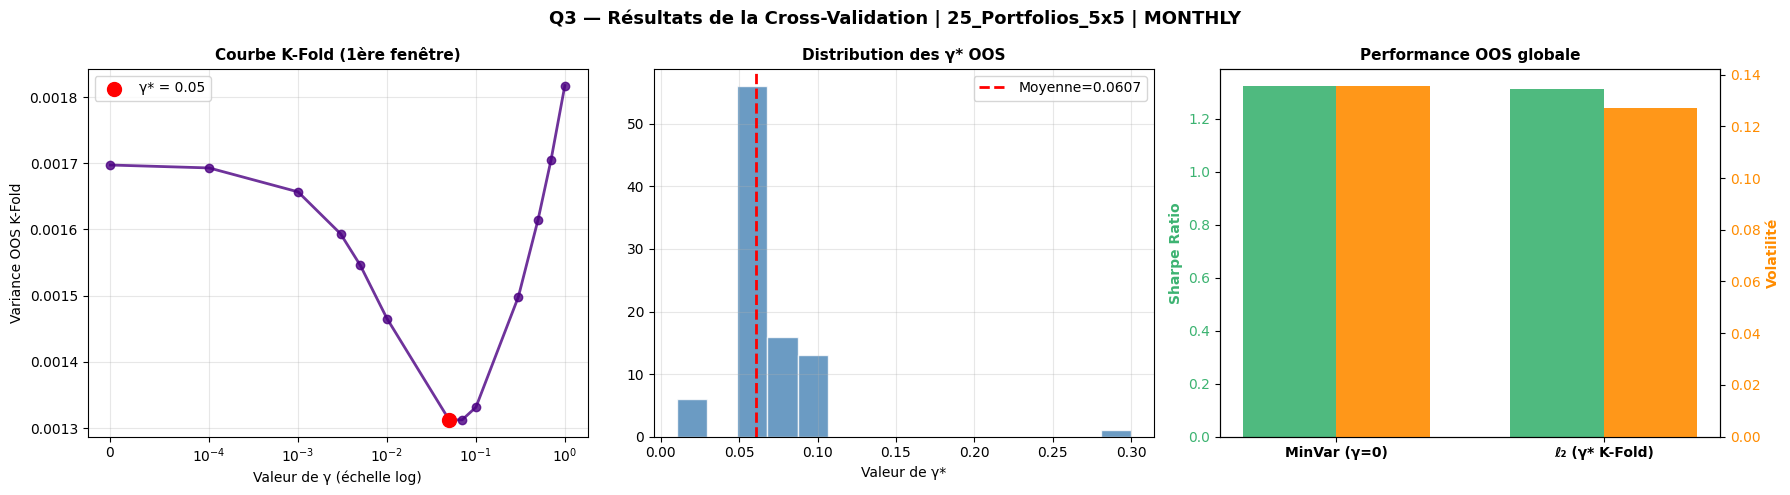


  25_Portfolios_5x5 | DAILY | T=14121, N=25
  Strategy                    Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (γ=0)                  0.1987     0.1316     1.5099     0.6605     0.0000
  ℓ₂ (γ* Dynamique)             0.1965     0.1301     1.5106     0.6417     0.0000

  Statistiques des γ* choisis au fil du temps :
    Min=0.0000 | Max=0.1000 | Moyenne=0.0159


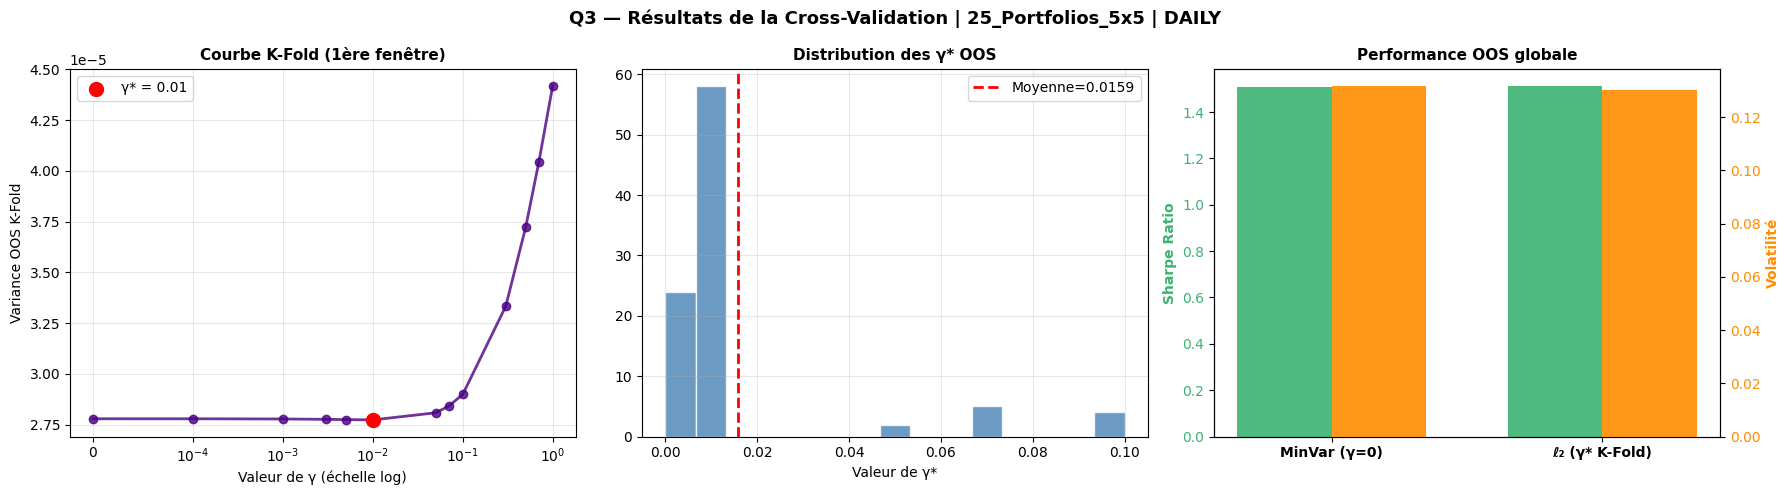


  100_Portfolios_10x10 | MONTHLY | T=672, N=100
  Strategy                    Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (γ=0)                  0.1814     0.2557     0.7094    16.7240     0.0000
  ℓ₂ (γ* Dynamique)             0.1738     0.1305     1.3315     1.6712     0.0000

  Statistiques des γ* choisis au fil du temps :
    Min=0.0500 | Max=0.7000 | Moyenne=0.2643


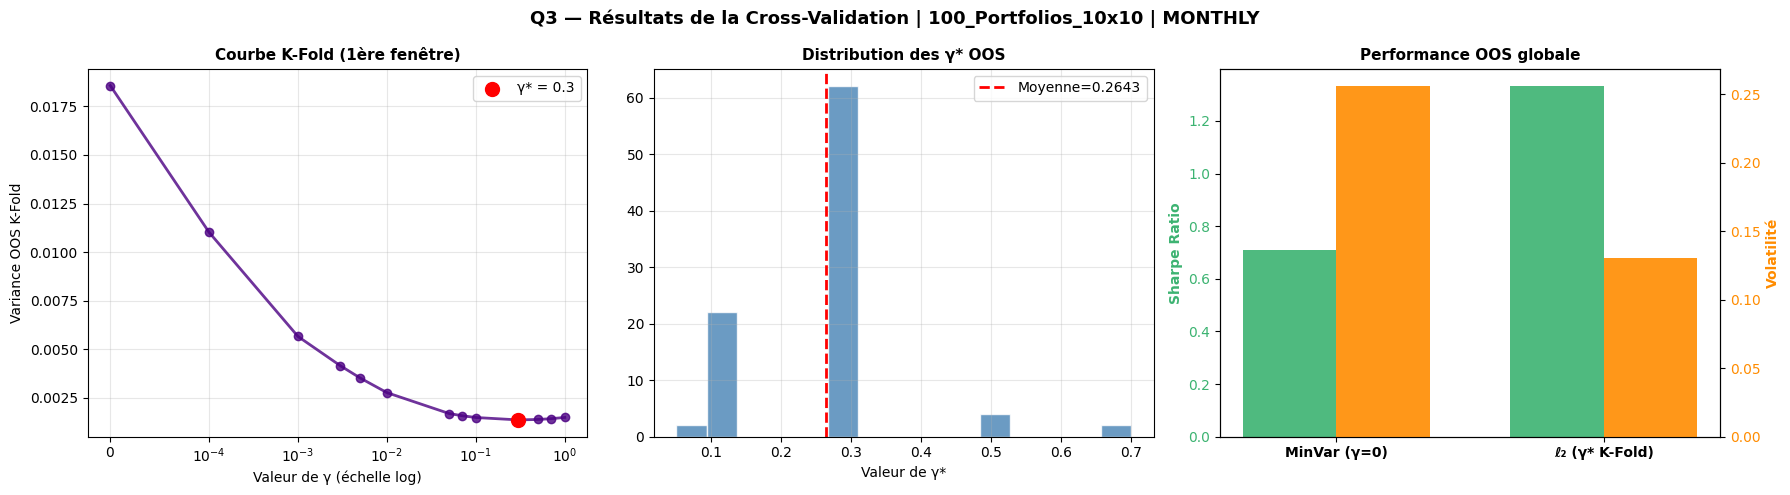


  100_Portfolios_10x10 | DAILY | T=14121, N=100
  Strategy                    Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (γ=0)                  0.1951     0.1106     1.7645     0.9804     0.0000
  ℓ₂ (γ* Dynamique)             0.1895     0.1102     1.7202     0.9500     0.0000

  Statistiques des γ* choisis au fil du temps :
    Min=0.0000 | Max=0.1000 | Moyenne=0.0362


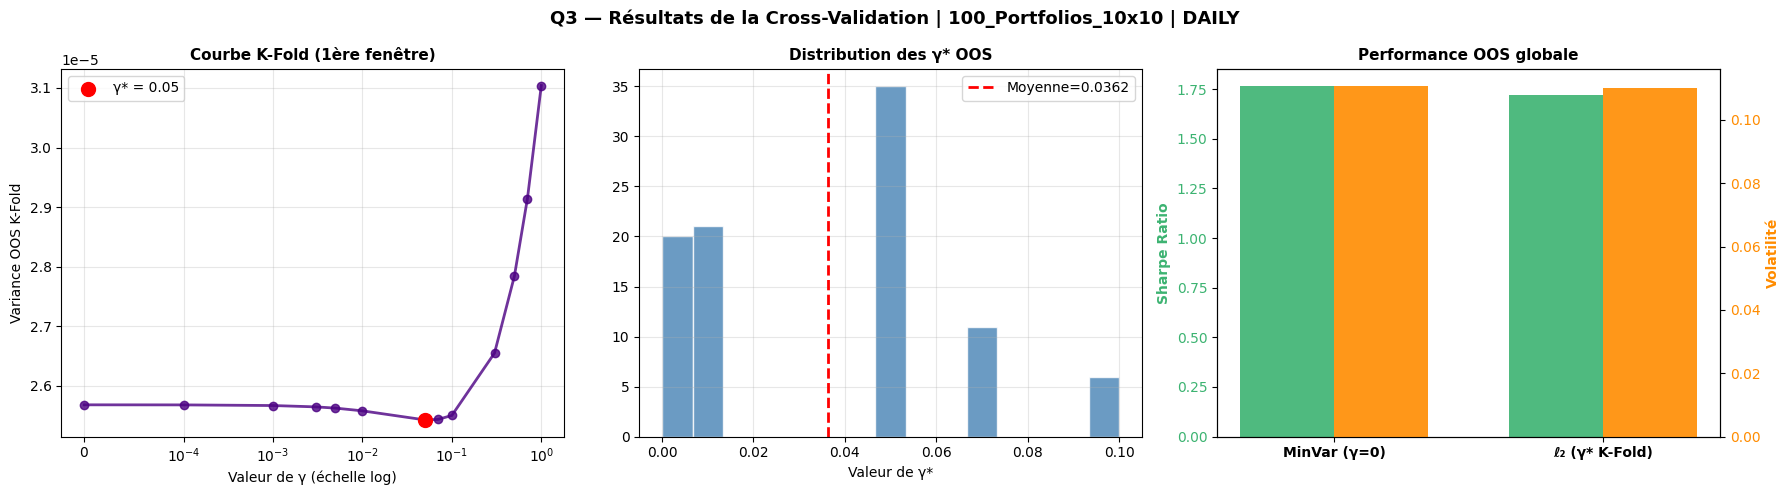


  10_Industry_Portfolios | MONTHLY | T=672, N=10
  Strategy                    Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (γ=0)                  0.1217     0.1240     0.9816     0.3935     0.0000
  ℓ₂ (γ* Dynamique)             0.1227     0.1222     1.0045     0.3319     0.0000

  Statistiques des γ* choisis au fil du temps :
    Min=0.0100 | Max=0.5000 | Moyenne=0.1575


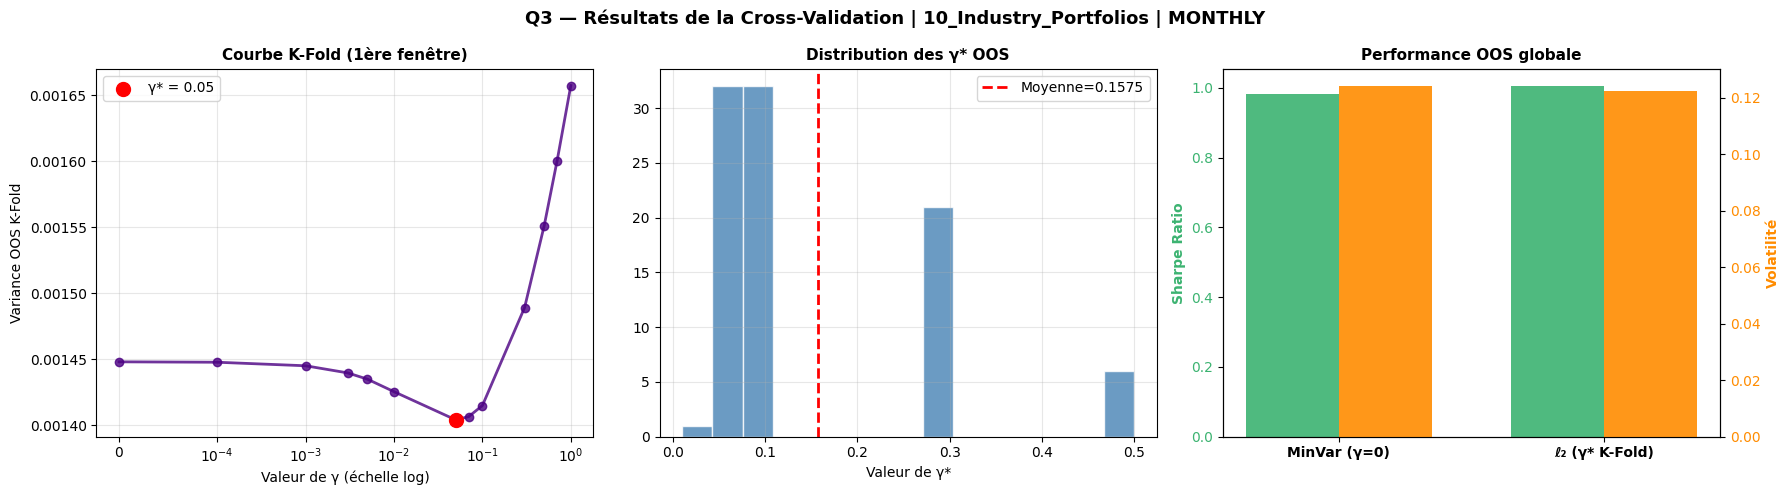


  10_Industry_Portfolios | DAILY | T=14121, N=10
  Strategy                    Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (γ=0)                  0.1224     0.1340     0.9130     0.2014     0.0000
  ℓ₂ (γ* Dynamique)             0.1243     0.1335     0.9313     0.2151     0.0000

  Statistiques des γ* choisis au fil du temps :
    Min=0.0000 | Max=0.1000 | Moyenne=0.0308


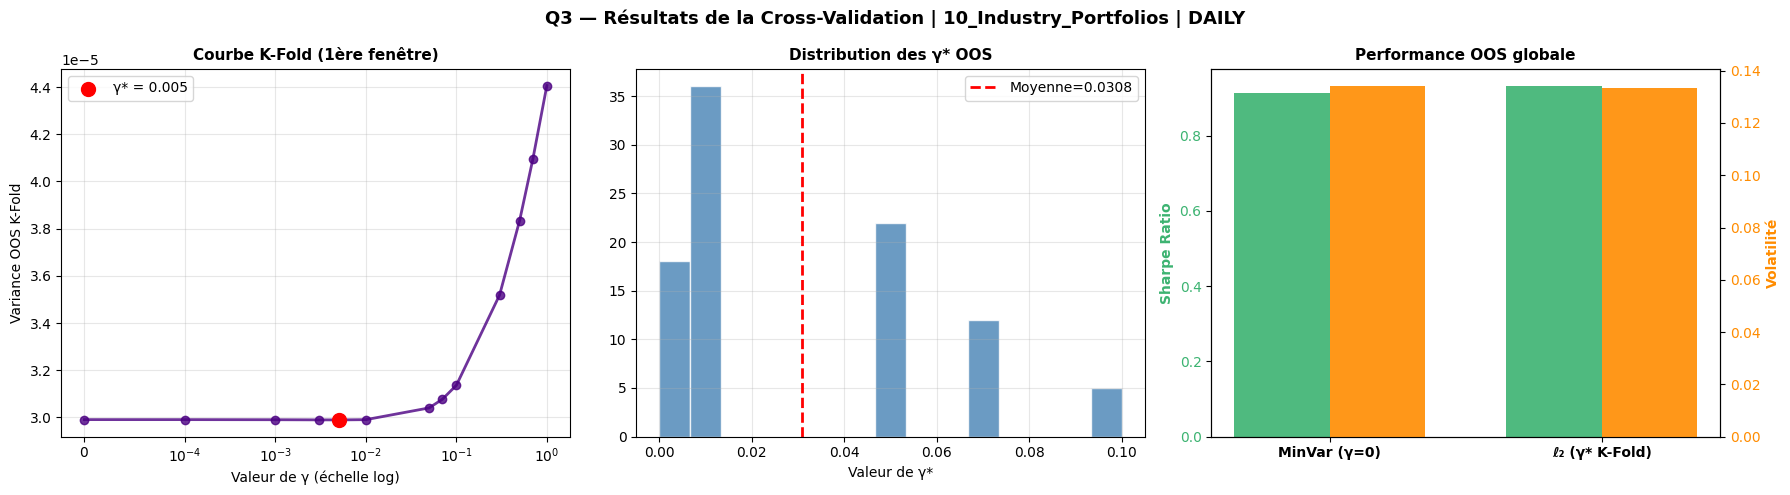


  48_Industry_Portfolios | MONTHLY | T=672, N=48
  Strategy                    Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (γ=0)                  0.0997     0.1423     0.7006     1.9688     0.0000
  ℓ₂ (γ* Dynamique)             0.1181     0.1178     1.0028     0.6846     0.0000

  Statistiques des γ* choisis au fil du temps :
    Min=0.1000 | Max=1.0000 | Moyenne=0.3576


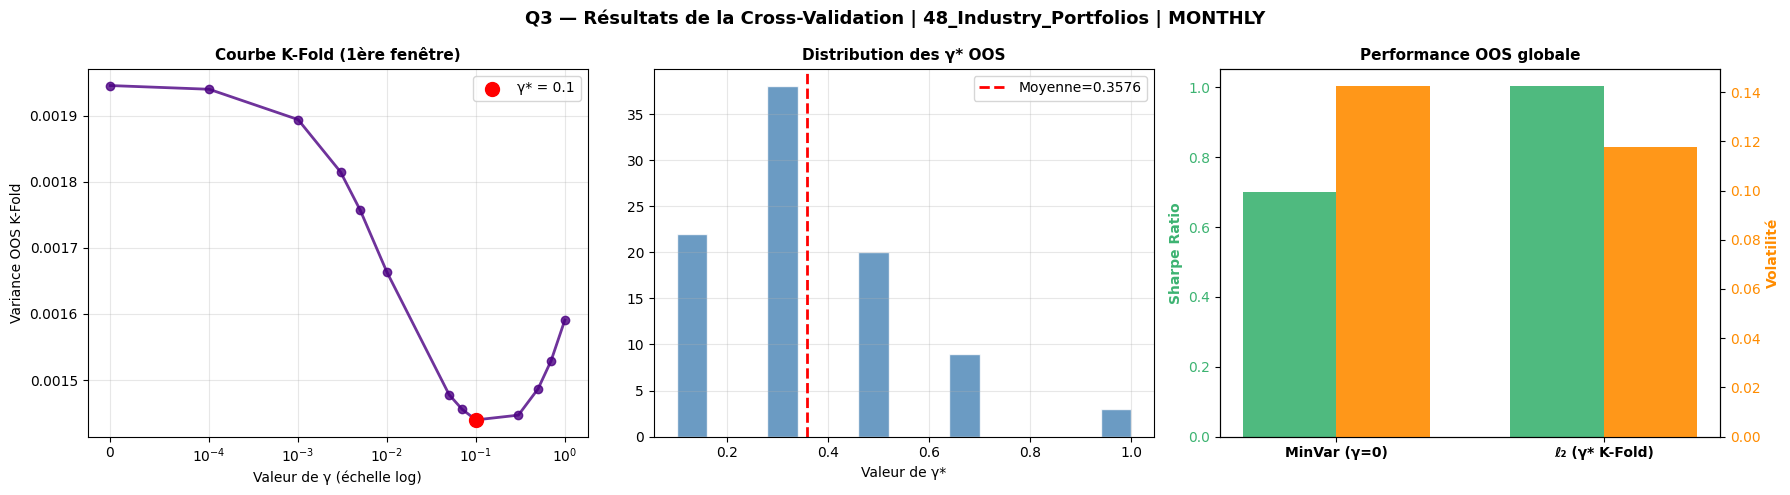


  48_Industry_Portfolios | DAILY | T=14121, N=48
  Strategy                    Ann.Mean    Ann.Vol     Sharpe   Turnover   FailRate
  ──────────────────────────────────────────────────────────────────────
  MinVar (γ=0)                  0.1111     0.1241     0.8953     0.4628     0.0000
  ℓ₂ (γ* Dynamique)             0.1155     0.1231     0.9386     0.4524     0.0000

  Statistiques des γ* choisis au fil du temps :
    Min=0.0000 | Max=0.3000 | Moyenne=0.0464


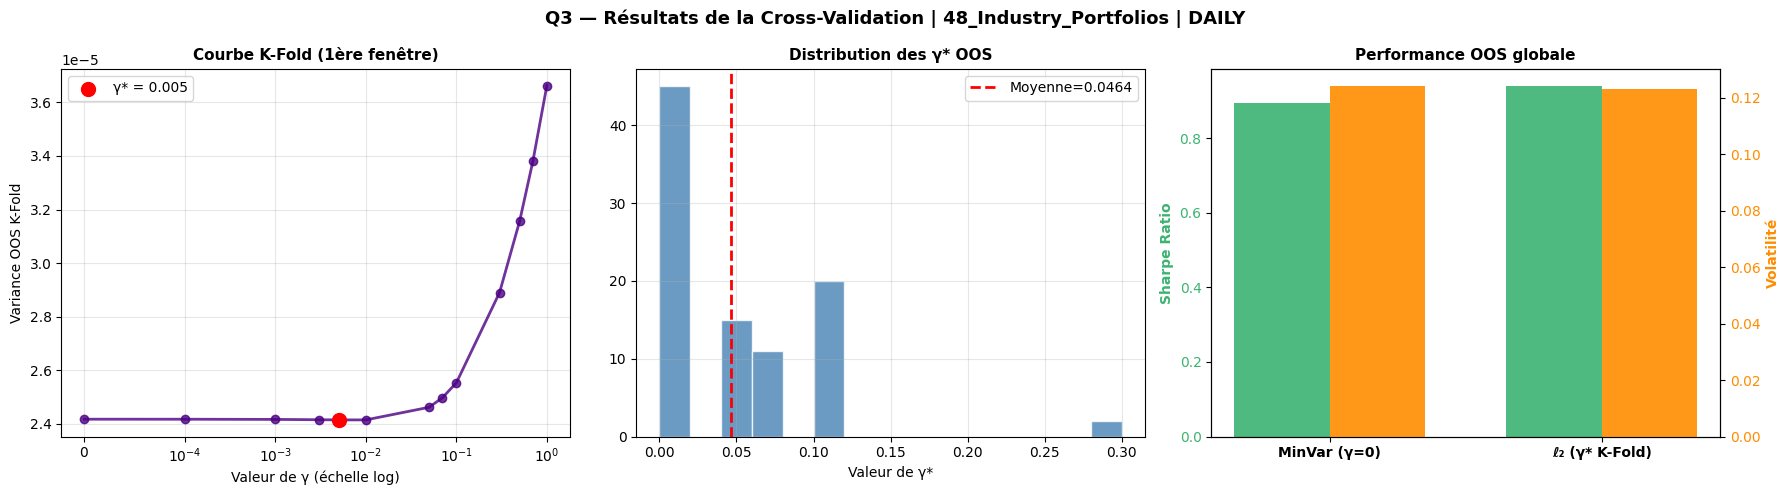

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import warnings

warnings.filterwarnings("ignore")

def compute_minvar_l2(Sigma: np.ndarray, gamma_raw: float, tol: float = 1e-12) -> np.ndarray:
    """MinVar Ridge avec γ_scaled = γ_raw * trace(Σ)/N"""
    Sigma = np.atleast_2d(Sigma)
    Sigma = (Sigma + Sigma.T) / 2
    N     = Sigma.shape[0]
    ones  = np.ones(N)

    trace_mean   = np.trace(Sigma) / N
    gamma_scaled = gamma_raw * trace_mean

    Sigma_reg = Sigma + gamma_scaled * np.eye(N)

    try:
        w = np.linalg.solve(Sigma_reg, ones)
    except np.linalg.LinAlgError:
        w = np.linalg.pinv(Sigma_reg) @ ones

    denom = ones @ w
    if abs(denom) < tol:
        return np.full(N, np.nan)
    return w / denom


def _kfold_optimal_gamma(train_df: pd.DataFrame, gammas: list, K: int = 10):
    """
    Retourne le gamma optimal ET le dictionnaire des variances moyennes pour chaque gamma.
    """
    X = train_df.values
    T_train = X.shape[0]

    if T_train < 2 * K:
        dummy_scores = {g: np.nan for g in gammas}
        return gammas[0], dummy_scores

    kf = KFold(n_splits=K, shuffle=False)
    scores_var = {g: [] for g in gammas}

    for idx_tr, idx_val in kf.split(X):
        X_tr  = X[idx_tr]
        X_val = X[idx_val]

        Sigma_tr = np.cov(X_tr.T)

        for g in gammas:
            w = compute_minvar_l2(Sigma_tr, g)
            if np.any(np.isnan(w)):
                scores_var[g].append(np.inf)
            else:
                port_val_returns = X_val @ w
                scores_var[g].append(np.var(port_val_returns))

    # Calcul de la variance moyenne sur les K Folds pour chaque gamma
    mean_vars = {g: np.mean(scores_var[g]) for g in gammas}

    # Sélection du meilleur gamma
    best_gamma = min(gammas, key=lambda g: mean_vars[g])

    return best_gamma, mean_vars


# ─────────────────────────────────────────────────────────────────────────────
# 3. OUT-OF-SAMPLE ENGINE
# ─────────────────────────────────────────────────────────────────────────────
def compute_oos_optimal_gamma(returns: pd.DataFrame, freq: str, gammas: list, K: int = 10):
    window, step = get_window_params(freq)
    T, N = returns.shape

    if T <= window:
        return {"Mean": np.nan, "Vol": np.nan, "Sharpe": np.nan, "FailRate": 1.0}, np.nan, [], [], {}

    oos_returns = []
    all_weights = []
    optimal_gammas = []
    first_cv_curve = {} # Pour stocker la courbe de la première fenêtre
    t = window

    while t < T:
        s     = min(step, T - t)
        train = returns.iloc[t - window : t]
        test  = returns.iloc[t : t + s]

        # 1. Sélectionne le meilleur gamma et récupère la courbe
        gamma_star, cv_curve = _kfold_optimal_gamma(train, gammas, K)
        optimal_gammas.append(gamma_star)

        # Sauvegarde la courbe uniquement pour la première fenêtre étudiée
        if not first_cv_curve:
            first_cv_curve = cv_curve

        # 2. Entraînement final
        Sigma_full = train.cov().values
        w = compute_minvar_l2(Sigma_full, gamma_star)
        all_weights.append(w)

        # 3. Rendements OOS
        if np.any(np.isnan(w)):
            oos_returns.extend([np.nan] * s)
        else:
            oos_returns.extend(test.values @ w)

        t += s

    perf = compute_performance(oos_returns, freq)
    turnover = compute_turnover(all_weights)

    return perf, turnover, all_weights, optimal_gammas, first_cv_curve


# ─────────────────────────────────────────────────────────────────────────────
# 4. GRAPHIQUES ET AFFICHAGE
# ─────────────────────────────────────────────────────────────────────────────
def _plot_q3(opt_gammas: list, perf_mv: dict, perf_opt: dict, first_cv_curve: dict, name: str, freq: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Graphique 1 : LA COURBE DE CROSS-VALIDATION (Ce que tu as demandé !)
    ax0 = axes[0]
    gammas_list = list(first_cv_curve.keys())
    vars_list = list(first_cv_curve.values())

    # On trouve le point minimum à mettre en évidence
    min_idx = np.argmin(vars_list)
    opt_g = gammas_list[min_idx]
    min_v = vars_list[min_idx]

    ax0.plot(gammas_list, vars_list, marker='o', linestyle='-', color='indigo', linewidth=2, alpha=0.8)
    ax0.scatter([opt_g], [min_v], color='red', s=100, zorder=5, label=f'γ* = {opt_g}')
    ax0.set_xscale('symlog', linthresh=1e-4) # Échelle log car les gammas sont très étalés
    ax0.set_title("Courbe K-Fold (1ère fenêtre)", fontsize=11, fontweight="bold")
    ax0.set_xlabel("Valeur de γ (échelle log)")
    ax0.set_ylabel("Variance OOS K-Fold")
    ax0.legend()
    ax0.grid(alpha=0.3)

    # Graphique 2 : Distribution des Gammas choisis
    ax1 = axes[1]
    ax1.hist(opt_gammas, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
    ax1.axvline(np.mean(opt_gammas), color="red", lw=2, linestyle="--", label=f"Moyenne={np.mean(opt_gammas):.4f}")
    ax1.set_title("Distribution des γ* OOS", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Valeur de γ*")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Graphique 3 : Comparaison Sharpe/Vol
    ax2 = axes[2]
    labels = ["MinVar (γ=0)", "ℓ₂ (γ* K-Fold)"]
    sharpes = [perf_mv.get("Sharpe", 0), perf_opt.get("Sharpe", 0)]
    vols = [perf_mv.get("Vol", 0), perf_opt.get("Vol", 0)]

    x = np.arange(len(labels))
    w = 0.35

    b1 = ax2.bar(x - w/2, sharpes, w, label="Sharpe", color="mediumseagreen", alpha=0.9)
    ax2.set_ylabel("Sharpe Ratio", color="mediumseagreen", fontweight="bold")
    ax2.tick_params(axis='y', labelcolor="mediumseagreen")

    ax3 = ax2.twinx()
    b2 = ax3.bar(x + w/2, vols, w, label="Volatilité", color="darkorange", alpha=0.9)
    ax3.set_ylabel("Volatilité", color="darkorange", fontweight="bold")
    ax3.tick_params(axis='y', labelcolor="darkorange")

    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, fontsize=10, fontweight="bold")
    ax2.set_title("Performance OOS globale", fontsize=11, fontweight="bold")

    fig.suptitle(f"Q3 — Résultats de la Cross-Validation | {name} | {freq.upper()}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = f"q3_{name}_{freq}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# 5. PIPELINE PRINCIPAL Q3
# ─────────────────────────────────────────────────────────────────────────────
def run_question3(all_data: dict, gammas: list = None) -> dict:
    if gammas is None:
        gammas = [0.0, 1e-4, 1e-3, 3e-3, 5e-3, 1e-2, 5e-2, 7e-2, 1e-1, 3e-1, 5e-1, 7e-1, 1.0]

    print("\n" + "█" * 70)
    print("  QUESTION 3 — Sélection de γ* via K-Fold Cross-Validation")
    print("█" * 70)

    all_results_q3 = {}

    for key, returns in all_data.items():
        name, freq = key.rsplit("_", 1)
        T, N = returns.shape

        print(f"\n{'='*75}")
        print(f"  {name} | {freq.upper()} | T={T}, N={N}")
        print(f"{'='*75}")

        train_wins = get_window_params(freq)[0]
        step_wins = get_window_params(freq)[1]

        oos_ref, ws_ref = [], []
        t = train_wins
        while t < T:
            s = min(step_wins, T - t)
            train = returns.iloc[t - train_wins : t]
            test = returns.iloc[t : t + s]
            w = compute_minvar_l2(train.cov().values, 0.0)
            ws_ref.append(w)
            oos_ref.extend(test.values @ w if not np.any(np.isnan(w)) else [np.nan]*s)
            t += s

        perf_mv = compute_performance(oos_ref, freq)
        to_mv = compute_turnover(ws_ref)

        # OOS avec K-Fold Dynamique
        perf_opt, to_opt, w_opt, opt_gammas, first_cv_curve = compute_oos_optimal_gamma(returns, freq, gammas, K=10)

        hdr = (f"  {'Strategy':<25} {'Ann.Mean':>10} {'Ann.Vol':>10} "
               f"{'Sharpe':>10} {'Turnover':>10} {'FailRate':>10}")
        print(hdr); print("  " + "─" * 70)

        print(f"  {'MinVar (γ=0)':<25} {perf_mv['Mean']:>10.4f} {perf_mv['Vol']:>10.4f} "
              f"{perf_mv['Sharpe']:>10.4f} {to_mv:>10.4f} {perf_mv['FailRate']:>10.4f}")

        print(f"  {'ℓ₂ (γ* Dynamique)':<25} {perf_opt['Mean']:>10.4f} {perf_opt['Vol']:>10.4f} "
              f"{perf_opt['Sharpe']:>10.4f} {to_opt:>10.4f} {perf_opt['FailRate']:>10.4f}")

        g_arr = np.array(opt_gammas)
        print(f"\n  Statistiques des γ* choisis au fil du temps :")
        print(f"    Min={g_arr.min():.4f} | Max={g_arr.max():.4f} | Moyenne={g_arr.mean():.4f}")

        _plot_q3(opt_gammas, perf_mv, perf_opt, first_cv_curve, name, freq)

        all_results_q3[key] = {
            "perf_opt": perf_opt, "to_opt": to_opt, "optimal_gammas": opt_gammas
        }

    return all_results_q3

# Lancement
results_q3 = run_question3(all_data)

## **Question 4**


██████████████████████████████████████████████████████████████████████
  QUESTION 4 — Comparaison MinVar | ℓ₂ | ℓ₁ (LASSO) | ℓ₁-ℓ∞ (XING)
██████████████████████████████████████████████████████████████████████

  25_Portfolios_5x5 | MONTHLY | T=672, N=25
  [1/4] MinVar classique...
  [2/4] ℓ₂ Ridge (importé de Q3)...
  [3/4] ℓ₁ LASSO (Optimisation CVXPY)...
  [4/4] ℓ₁-ℓ∞ XING (Optimisation CVXPY)...

  Strategy                 Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────────────
  ℓ₂ (γ* K-Fold)             0.1668     0.1271     1.3128     1.1701
  ℓ₁ (LASSO)                 0.1630     0.1309     1.2445     0.9224
  ℓ₁-ℓ∞ (Xing)               0.1588     0.1328     1.1961     0.5605


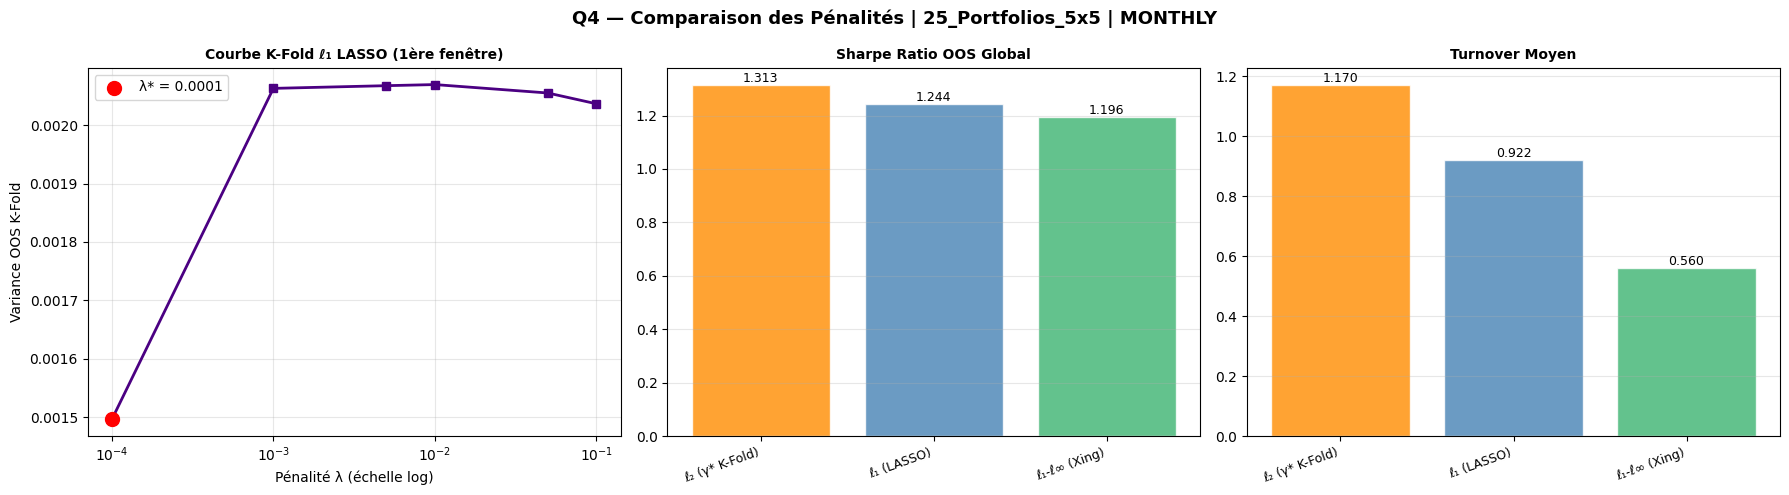


  25_Portfolios_5x5 | DAILY | T=14121, N=25
  [1/4] MinVar classique...
  [2/4] ℓ₂ Ridge (importé de Q3)...
  [3/4] ℓ₁ LASSO (Optimisation CVXPY)...
  [4/4] ℓ₁-ℓ∞ XING (Optimisation CVXPY)...

  Strategy                 Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────────────
  ℓ₂ (γ* K-Fold)             0.1965     0.1301     1.5106     0.6417
  ℓ₁ (LASSO)                 0.1379     0.1780     0.7745     0.0315
  ℓ₁-ℓ∞ (Xing)               0.1362     0.1772     0.7690     0.1327


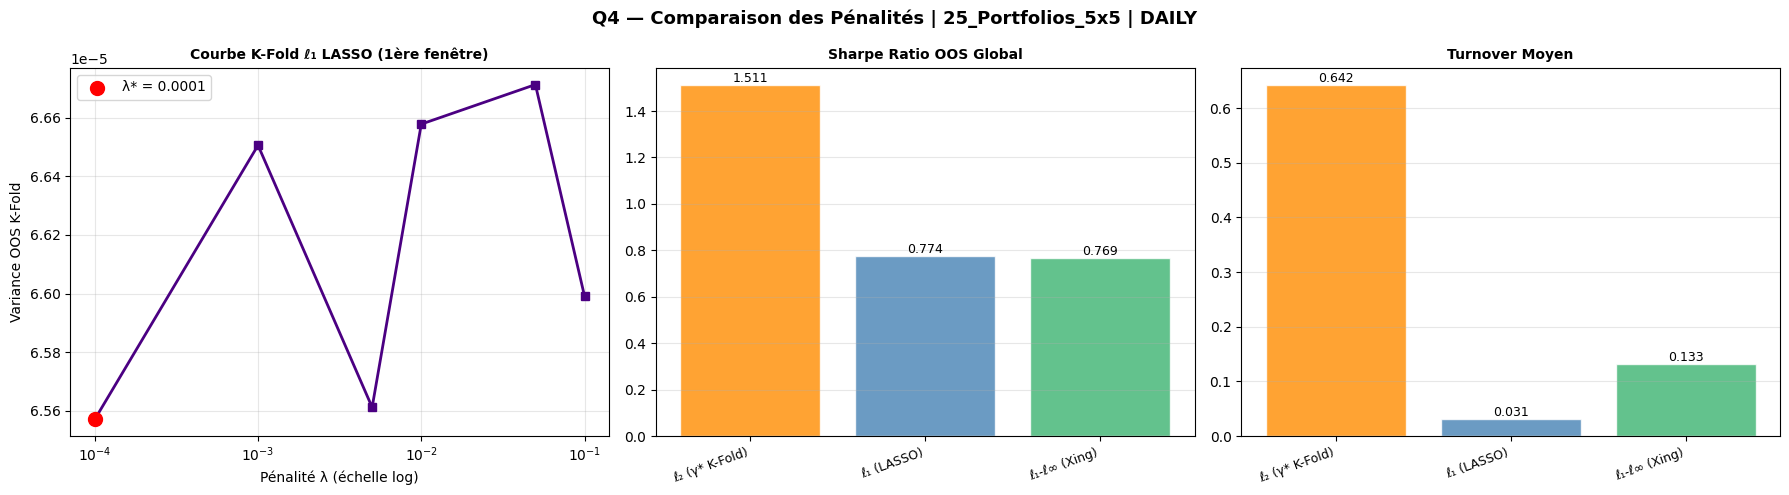


  100_Portfolios_10x10 | MONTHLY | T=672, N=100
  [1/4] MinVar classique...
  [2/4] ℓ₂ Ridge (importé de Q3)...
  [3/4] ℓ₁ LASSO (Optimisation CVXPY)...
  [4/4] ℓ₁-ℓ∞ XING (Optimisation CVXPY)...

  Strategy                 Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────────────
  ℓ₂ (γ* K-Fold)             0.1738     0.1305     1.3315     1.6712
  ℓ₁ (LASSO)                 0.1788     0.1284     1.3923     1.4258
  ℓ₁-ℓ∞ (Xing)               0.1672     0.1309     1.2770     0.7850


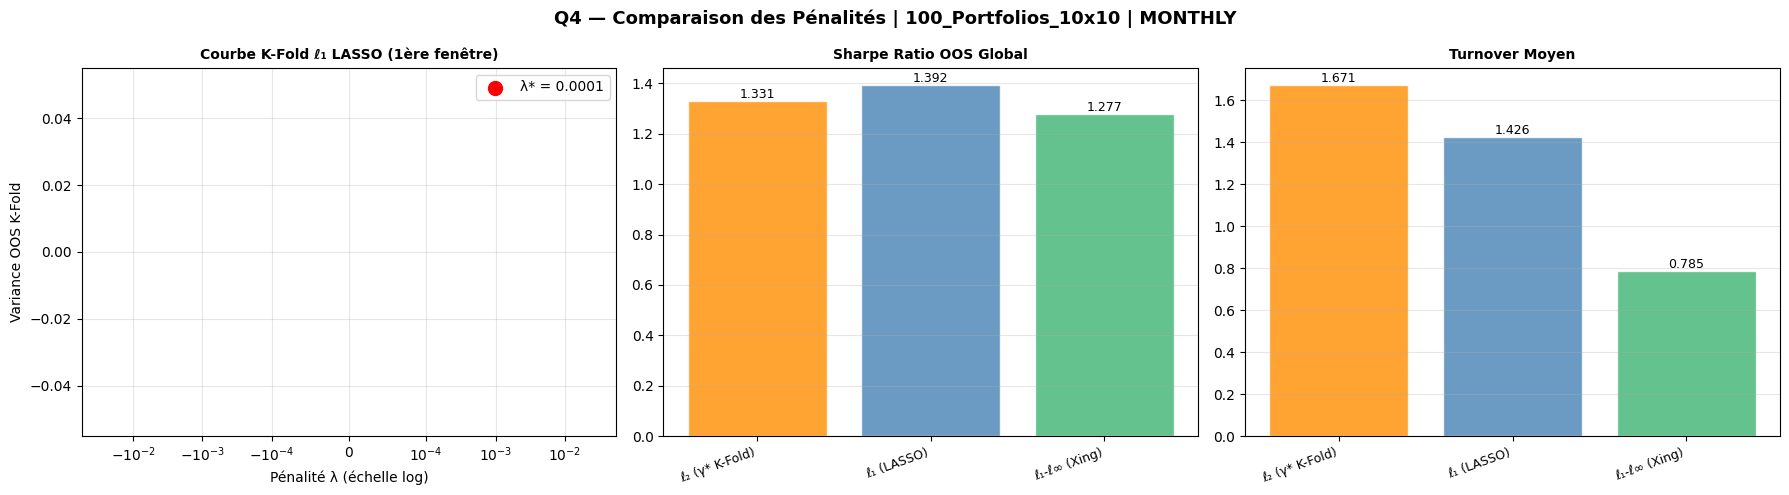


  100_Portfolios_10x10 | DAILY | T=14121, N=100
  [1/4] MinVar classique...
  [2/4] ℓ₂ Ridge (importé de Q3)...
  [3/4] ℓ₁ LASSO (Optimisation CVXPY)...
  [4/4] ℓ₁-ℓ∞ XING (Optimisation CVXPY)...

  Strategy                 Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────────────
  ℓ₂ (γ* K-Fold)             0.1895     0.1102     1.7202     0.9500
  ℓ₁ (LASSO)                 0.1381     0.1666     0.8285     0.1758
  ℓ₁-ℓ∞ (Xing)               0.1379     0.1396     0.9880     0.4999


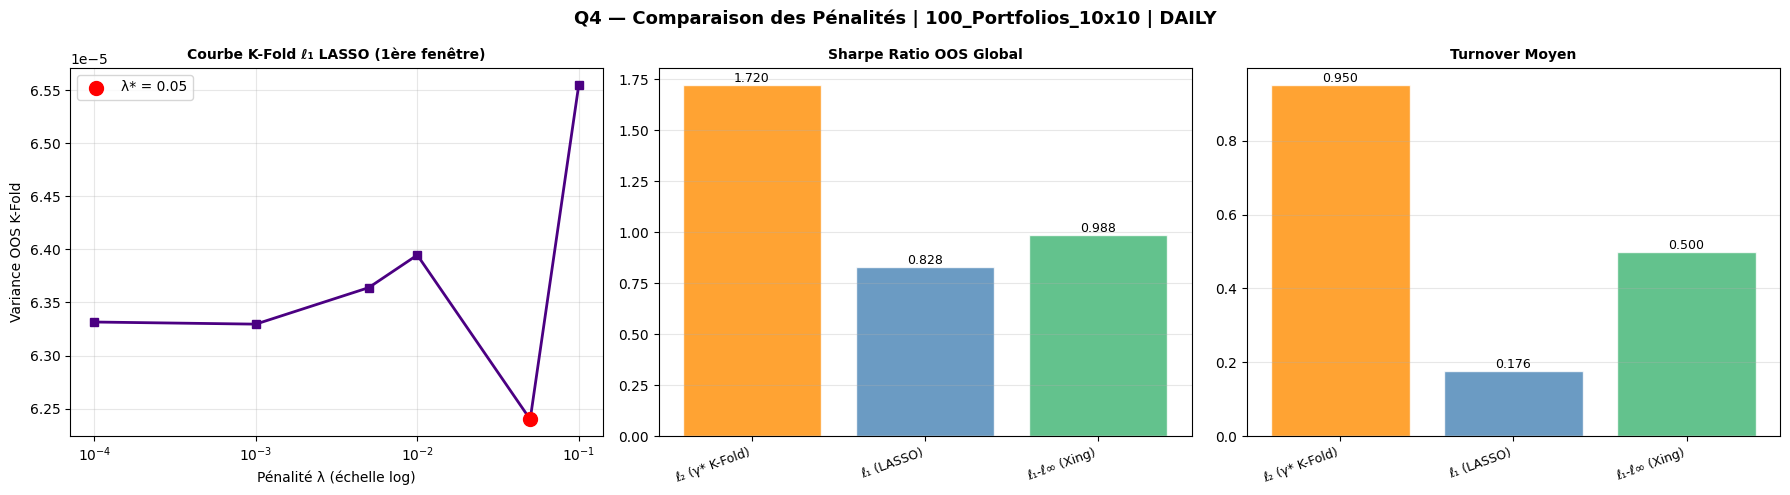


  10_Industry_Portfolios | MONTHLY | T=672, N=10
  [1/4] MinVar classique...
  [2/4] ℓ₂ Ridge (importé de Q3)...
  [3/4] ℓ₁ LASSO (Optimisation CVXPY)...
  [4/4] ℓ₁-ℓ∞ XING (Optimisation CVXPY)...

  Strategy                 Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────────────
  ℓ₂ (γ* K-Fold)             0.1227     0.1222     1.0045     0.3319
  ℓ₁ (LASSO)                 0.1233     0.1238     0.9957     0.3354
  ℓ₁-ℓ∞ (Xing)               0.1249     0.1214     1.0285     0.3104


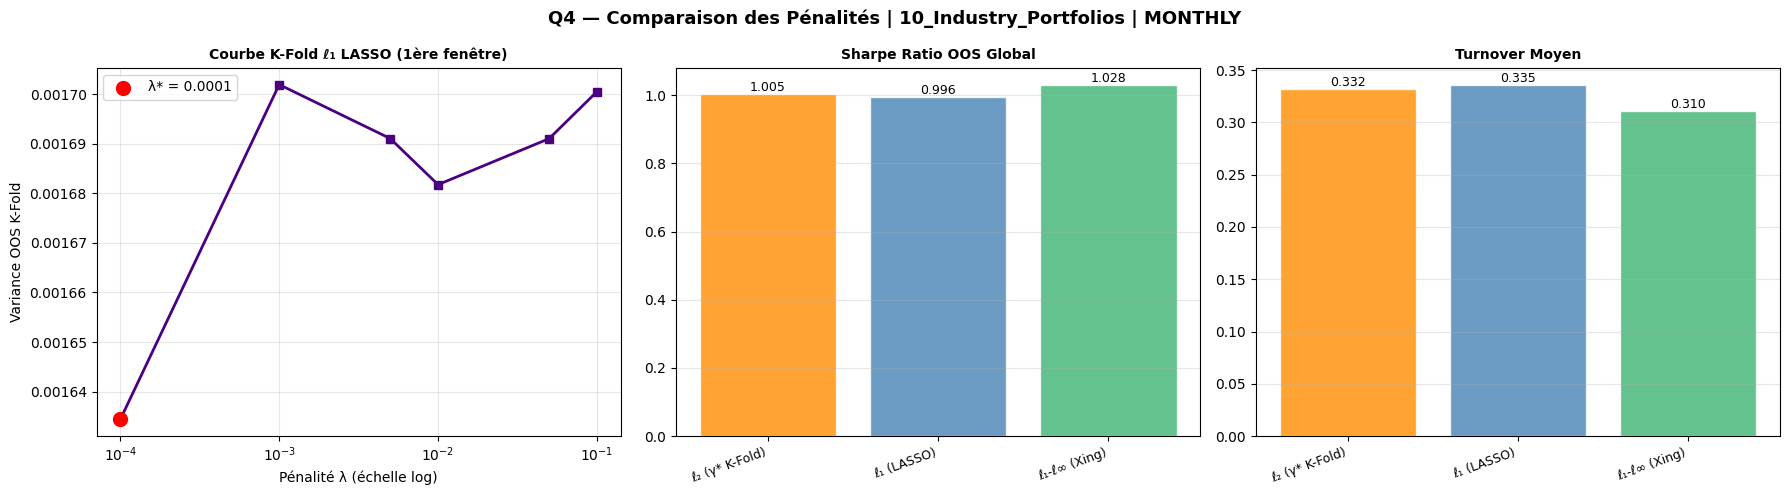


  10_Industry_Portfolios | DAILY | T=14121, N=10
  [1/4] MinVar classique...
  [2/4] ℓ₂ Ridge (importé de Q3)...
  [3/4] ℓ₁ LASSO (Optimisation CVXPY)...
  [4/4] ℓ₁-ℓ∞ XING (Optimisation CVXPY)...

  Strategy                 Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────────────
  ℓ₂ (γ* K-Fold)             0.1243     0.1335     0.9313     0.2151
  ℓ₁ (LASSO)                 0.1265     0.1537     0.8231     0.3198
  ℓ₁-ℓ∞ (Xing)               0.1332     0.1617     0.8239     0.1049


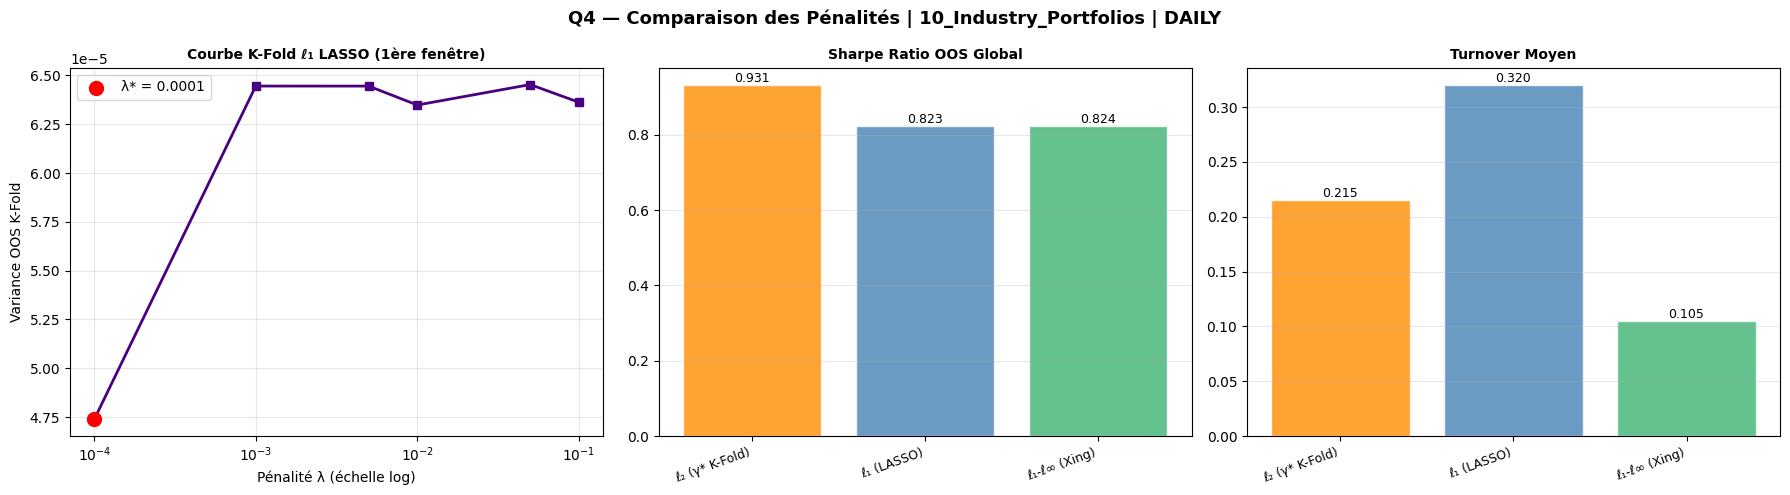


  48_Industry_Portfolios | MONTHLY | T=672, N=48
  [1/4] MinVar classique...
  [2/4] ℓ₂ Ridge (importé de Q3)...
  [3/4] ℓ₁ LASSO (Optimisation CVXPY)...
  [4/4] ℓ₁-ℓ∞ XING (Optimisation CVXPY)...

  Strategy                 Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────────────
  ℓ₂ (γ* K-Fold)             0.1181     0.1178     1.0028     0.6846
  ℓ₁ (LASSO)                 0.1133     0.1202     0.9422     0.7748
  ℓ₁-ℓ∞ (Xing)               0.1138     0.1200     0.9484     0.7673


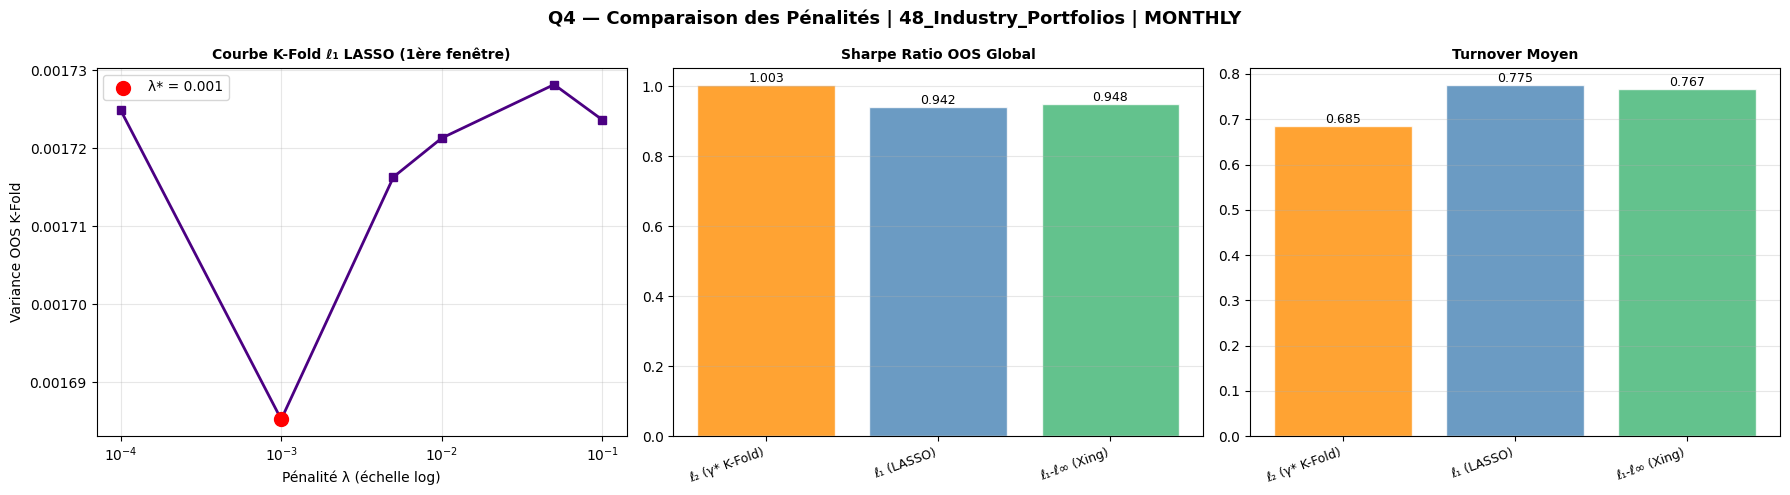


  48_Industry_Portfolios | DAILY | T=14121, N=48
  [1/4] MinVar classique...
  [2/4] ℓ₂ Ridge (importé de Q3)...
  [3/4] ℓ₁ LASSO (Optimisation CVXPY)...
  [4/4] ℓ₁-ℓ∞ XING (Optimisation CVXPY)...

  Strategy                 Ann.Mean    Ann.Vol     Sharpe   Turnover
  ────────────────────────────────────────────────────────────────────
  ℓ₂ (γ* K-Fold)             0.1155     0.1231     0.9386     0.4524
  ℓ₁ (LASSO)                 0.1290     0.1503     0.8587     0.1094
  ℓ₁-ℓ∞ (Xing)               0.1191     0.1413     0.8428     0.5389


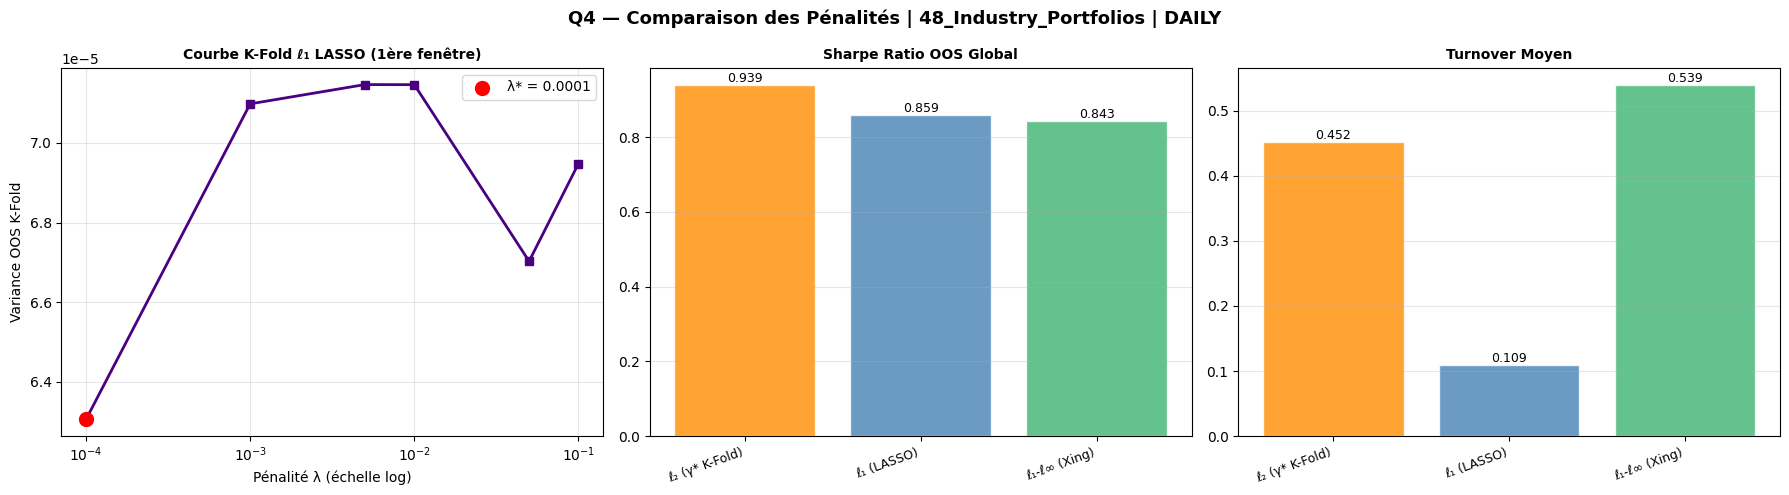

In [ ]:
import cvxpy as cp
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")

def solve_l1(Sigma: np.ndarray, lam: float, N: int) -> np.ndarray:
    Sigma = np.atleast_2d(Sigma)
    Sigma = (Sigma + Sigma.T) / 2

    w = cp.Variable(N)
    objective = cp.Minimize(cp.quad_form(w, Sigma) + lam * cp.norm1(w))
    constraints = [cp.sum(w) == 1]
    prob = cp.Problem(objective, constraints)

    try:
        prob.solve(solver=cp.SCS, verbose=False, eps=1e-4, max_iters=5000)
        if w.value is None or prob.status in ("infeasible", "unbounded"):
            prob.solve(solver=cp.CLARABEL, verbose=False)
        if w.value is None:
            return np.full(N, np.nan)
        return np.asarray(w.value).flatten()
    except Exception:
        return np.full(N, np.nan)


def solve_l1_linf(Sigma: np.ndarray, alpha: float, c: float, N: int) -> np.ndarray:
    """MinVar ℓ₁-ℓ∞ (OSCAR / Xing et al. 2014)"""
    c_min = 1.0 + alpha / N
    if c <= c_min + 1e-8:
        return np.full(N, np.nan)

    Sigma = np.atleast_2d(Sigma)
    Sigma = (Sigma + Sigma.T) / 2

    w = cp.Variable(N)
    objective = cp.Minimize(cp.quad_form(w, Sigma))
    constraints = [
        cp.sum(w) == 1,
        cp.norm1(w) + alpha * cp.norm_inf(w) <= c
    ]
    prob = cp.Problem(objective, constraints)

    try:
        prob.solve(solver=cp.SCS, verbose=False, eps=1e-4, max_iters=5000)
        if w.value is None or prob.status in ("infeasible", "unbounded"):
            prob.solve(solver=cp.CLARABEL, verbose=False)
        if w.value is None:
            return np.full(N, np.nan)
        return np.asarray(w.value).flatten()
    except Exception:
        return np.full(N, np.nan)


# ─────────────────────────────────────────────────────────────────────────────
# 2. K-FOLD CROSS-VALIDATION
# ─────────────────────────────────────────────────────────────────────────────

def kfold_l1_curve(X: np.ndarray, lambdas: list, K: int = 5):
    """K-Fold pour choisir λ* (ℓ₁) et retourner la courbe de variance."""
    T, N = X.shape
    K_eff = max(3, min(K, T // 10))
    blocks = np.array_split(np.arange(T), K_eff)

    mean_vars = {}
    for lam in lambdas:
        fold_vars = []
        for k in range(K_eff):
            test_idx = blocks[k]
            train_idx = np.concatenate([blocks[j] for j in range(K_eff) if j != k])

            if len(train_idx) < N + 2:
                fold_vars.append(np.inf)
                continue

            Sigma_k = np.cov(X[train_idx].T)
            w = solve_l1(Sigma_k, lam, N)

            if np.any(np.isnan(w)):
                fold_vars.append(np.inf)
            else:
                fold_vars.append(np.var(X[test_idx] @ w))

        mean_vars[lam] = np.mean(fold_vars)

    best_lam = min(mean_vars, key=mean_vars.get)
    return best_lam, mean_vars


def kfold_linf(X: np.ndarray, params_grid: list, K: int = 5):
    T, N = X.shape
    K_eff = max(3, min(K, T // 10))
    blocks = np.array_split(np.arange(T), K_eff)

    best_var = np.inf
    best_params = params_grid[0]

    for alpha, c in params_grid:
        fold_vars = []
        for k in range(K_eff):
            test_idx = blocks[k]
            train_idx = np.concatenate([blocks[j] for j in range(K_eff) if j != k])

            Sigma_k = np.cov(X[train_idx].T)
            w = solve_l1_linf(Sigma_k, alpha, c, N)

            if np.any(np.isnan(w)):
                fold_vars.append(np.inf)
            else:
                fold_vars.append(np.var(X[test_idx] @ w))

        var_oos = np.mean(fold_vars)
        if var_oos < best_var:
            best_var = var_oos
            best_params = (alpha, c)

    return best_params


# ─────────────────────────────────────────────────────────────────────────────
# 3. ROLLING OUT-OF-SAMPLE ENGINES
# ─────────────────────────────────────────────────────────────────────────────

def compute_oos_l1(returns: pd.DataFrame, freq: str, lambdas: list):
    window, roll_step = get_window_params(freq)
    T, N = returns.shape
    oos_returns, all_weights, opt_params = [], [], []
    first_cv_curve = {}

    t = window
    while t < T:
        s = min(roll_step, T - t)
        X_train = returns.iloc[t - window:t].values
        X_test = returns.iloc[t:t + s].values

        lam_star, cv_curve = kfold_l1_curve(X_train, lambdas, K=5)
        opt_params.append(lam_star)

        if not first_cv_curve:
            first_cv_curve = cv_curve

        w = solve_l1(np.cov(X_train.T), lam_star, N)
        all_weights.append(w)

        if np.any(np.isnan(w)):
            oos_returns.extend([np.nan] * len(X_test))
        else:
            oos_returns.extend(X_test @ w)

        t += s

    perf = compute_performance(oos_returns, freq)
    turnover = compute_turnover(all_weights)
    return perf, turnover, all_weights, first_cv_curve


def compute_oos_linf(returns: pd.DataFrame, freq: str, params_grid: list):
    window, roll_step = get_window_params(freq)
    T, N = returns.shape
    oos_returns, all_weights = [], []

    t = window
    while t < T:
        s = min(roll_step, T - t)
        X_train = returns.iloc[t - window:t].values
        X_test = returns.iloc[t:t + s].values

        best_params = kfold_linf(X_train, params_grid, K=5)
        w = solve_l1_linf(np.cov(X_train.T), best_params[0], best_params[1], N)
        all_weights.append(w)

        if np.any(np.isnan(w)):
            oos_returns.extend([np.nan] * len(X_test))
        else:
            oos_returns.extend(X_test @ w)

        t += s

    perf = compute_performance(oos_returns, freq)
    turnover = compute_turnover(all_weights)
    return perf, turnover, all_weights


# ─────────────────────────────────────────────────────────────────────────────
# 4. GRAPHIQUES ET AFFICHAGE
# ─────────────────────────────────────────────────────────────────────────────
def _plot_q4_combined(results_dict: dict, first_cv_curve: dict, dataset_name: str, freq: str):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Courbe CV pour le LASSO
    ax0 = axes[0]
    lams = list(first_cv_curve.keys())
    vars_oos = list(first_cv_curve.values())
    min_idx = np.argmin(vars_oos)

    ax0.plot(lams, vars_oos, marker='s', linestyle='-', color='indigo', lw=2)
    ax0.scatter([lams[min_idx]], [vars_oos[min_idx]], color='red', s=100, zorder=5, label=f'λ* = {lams[min_idx]}')
    ax0.set_xscale('symlog', linthresh=1e-4)
    ax0.set_title("Courbe K-Fold ℓ₁ LASSO (1ère fenêtre)", fontsize=10, fontweight="bold")
    ax0.set_xlabel("Pénalité λ (échelle log)")
    ax0.set_ylabel("Variance OOS K-Fold")
    ax0.grid(alpha=0.3)
    ax0.legend()

    # 2. Sharpe Ratio Comparaison
    ax1 = axes[1]
    names = list(results_dict.keys())
    sharpes = [results_dict[n]["perf"]["Sharpe"] for n in names]
    colors = ["darkorange", "steelblue", "mediumseagreen", "mediumpurple"]

    bars = ax1.bar(names, sharpes, color=colors, alpha=0.8, edgecolor="white")
    ax1.set_title("Sharpe Ratio OOS Global", fontsize=10, fontweight="bold")
    ax1.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax1.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, sharpes):
        if not np.isnan(val):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    # 3. Turnover Comparaison
    ax2 = axes[2]
    turnovers = [results_dict[n]["turnover"] for n in names]

    bars2 = ax2.bar(names, turnovers, color=colors, alpha=0.8, edgecolor="white")
    ax2.set_title("Turnover Moyen", fontsize=10, fontweight="bold")
    ax2.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax2.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars2, turnovers):
        if not np.isnan(val):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    fig.suptitle(f"Q4 — Comparaison des Pénalités | {dataset_name} | {freq.upper()}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"q4_summary_{dataset_name}_{freq}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# 5. PIPELINE PRINCIPAL Q4
# ─────────────────────────────────────────────────────────────────────────────
def run_question4(all_data: dict, all_results_q3: dict):

    lambdas_l1 = [1e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]
    params_linf = [(0.5, 1.5), (1.0, 1.5), (1.0, 2.0), (2.0, 3.0)] # Grille allégée pour vitesse

    all_results_q4 = {}

    print("\n" + "█" * 70)
    print("  QUESTION 4 — Comparaison MinVar | ℓ₂ | ℓ₁ (LASSO) | ℓ₁-ℓ∞ (XING)")
    print("█" * 70)

    for key, returns in all_data.items():
        name, freq = key.rsplit("_", 1)
        T, N = returns.shape

        print(f"\n{'='*80}")
        print(f"  {name} | {freq.upper()} | T={T}, N={N}")
        print(f"{'='*80}")

        results_dict = {}

        print("  [1/4] MinVar classique...")
        # On peut tricher et récupérer le MinVar du dictionnaire Q3 si existant, sinon on recalcule
        q3 = all_results_q3.get(key, {})

        print("  [2/4] ℓ₂ Ridge (importé de Q3)...")
        results_dict["ℓ₂ (γ* K-Fold)"] = {
            "perf": q3.get("perf_opt", {"Mean": np.nan, "Vol": np.nan, "Sharpe": np.nan, "FailRate": np.nan}),
            "turnover": q3.get("to_opt", np.nan),
            "weights": q3.get("ws_opt", [])
        }

        print("  [3/4] ℓ₁ LASSO (Optimisation CVXPY)...")
        perf_l1, to_l1, w_l1, cv_curve_l1 = compute_oos_l1(returns, freq, lambdas_l1)
        results_dict["ℓ₁ (LASSO)"] = {
            "perf": perf_l1, "turnover": to_l1, "weights": w_l1
        }

        print("  [4/4] ℓ₁-ℓ∞ XING (Optimisation CVXPY)...")
        perf_lx, to_lx, w_lx = compute_oos_linf(returns, freq, params_linf)
        results_dict["ℓ₁-ℓ∞ (Xing)"] = {
            "perf": perf_lx, "turnover": to_lx, "weights": w_lx
        }

        print(f"\n  {'Strategy':<22} {'Ann.Mean':>10} {'Ann.Vol':>10} {'Sharpe':>10} {'Turnover':>10}")
        print("  " + "─" * 68)
        for strat, data in results_dict.items():
            p = data["perf"]
            print(f"  {strat:<22} {p.get('Mean', np.nan):>10.4f} {p.get('Vol', np.nan):>10.4f} "
                  f"{p.get('Sharpe', np.nan):>10.4f} {data.get('turnover', np.nan):>10.4f}")

        _plot_q4_combined(results_dict, cv_curve_l1, name, freq)
        all_results_q4[key] = results_dict

    return all_results_q4

# Lancement
results_q4 = run_question4(all_data, results_q3)

## **Question 5**


████████████████████████████████████████████████████████████████████████████████
QUESTION 5 — PCA covariance + Stein eigenvalues + Bai & Ng
████████████████████████████████████████████████████████████████████████████████

Q5 | 25_Portfolios_5x5_monthly | T=672, N=25

  Grille de K évaluée : [1, 2, 3, 5, 8, 10, 15, 20, 24, 25]
    Fenêtre  10 calculée...
    Fenêtre  20 calculée...
    Fenêtre  30 calculée...
    Fenêtre  40 calculée...
    Fenêtre  50 calculée...
    Fenêtre  60 calculée...
    Fenêtre  70 calculée...
    Fenêtre  80 calculée...
    Fenêtre  90 calculée...

Q5 — PCA covariance | 25_Portfolios_5x5 | MONTHLY

--- Minimum-Variance ---
    K |  Sample Sharpe |  Stein Sharpe |  Sample Vol |  Stein Vol |  Sample TO |  Stein TO
------------------------------------------------------------------------------------------
    1 |         0.8326 |        0.8351 |      0.2022 |     0.1994 |     0.3358 |    0.4324
    2 |         1.0708 |        1.0832 |      0.1737 |     0.1696 |  

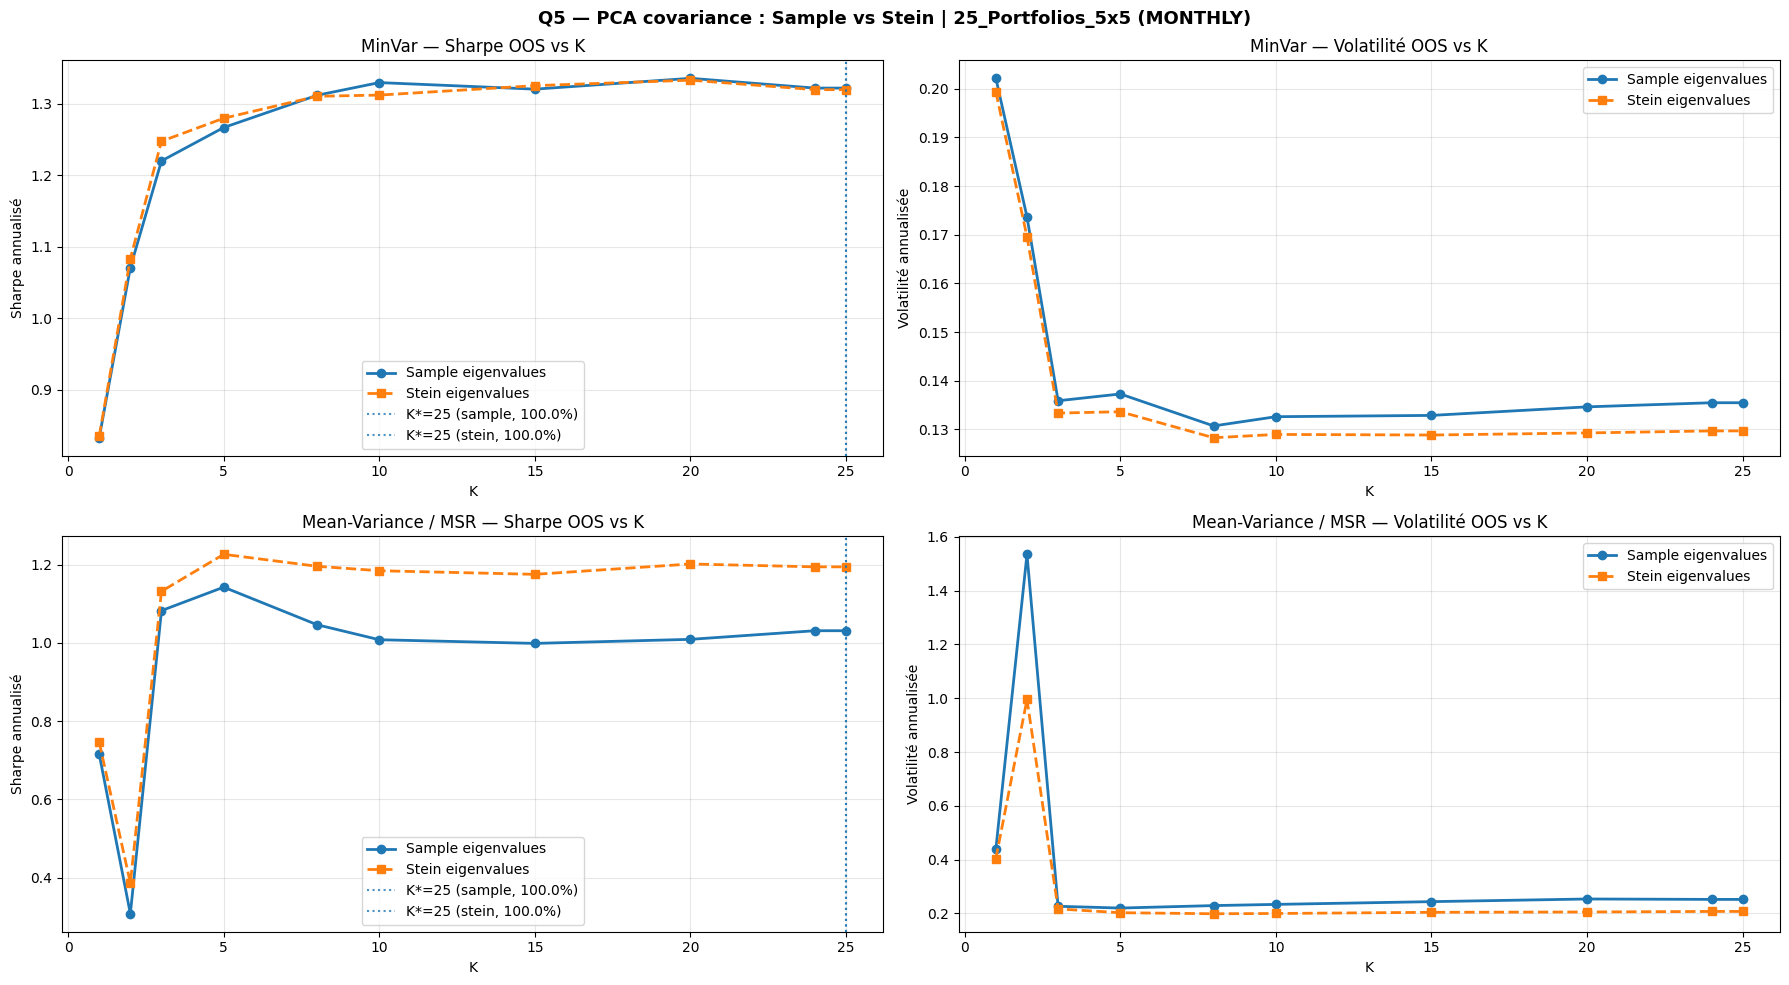

Figure sauvegardée : q5_pca_stein_25_Portfolios_5x5_monthly.png

Q5 | 25_Portfolios_5x5_daily | T=14121, N=25

  Grille de K évaluée : [1, 2, 3, 5, 8, 10, 15, 20, 24, 25]
    Fenêtre  10 calculée...
    Fenêtre  20 calculée...
    Fenêtre  30 calculée...
    Fenêtre  40 calculée...
    Fenêtre  50 calculée...
    Fenêtre  60 calculée...
    Fenêtre  70 calculée...
    Fenêtre  80 calculée...
    Fenêtre  90 calculée...

Q5 — PCA covariance | 25_Portfolios_5x5 | DAILY

--- Minimum-Variance ---
    K |  Sample Sharpe |  Stein Sharpe |  Sample Vol |  Stein Vol |  Sample TO |  Stein TO
------------------------------------------------------------------------------------------
    1 |         1.0496 |        1.0497 |      0.1661 |     0.1661 |     0.3640 |    0.3639
    2 |         1.2293 |        1.2294 |      0.1659 |     0.1658 |     0.3564 |    0.3561
    3 |         1.3380 |        1.3382 |      0.1339 |     0.1339 |     0.4989 |    0.4979
    5 |         1.3936 |        1.3938 |      0

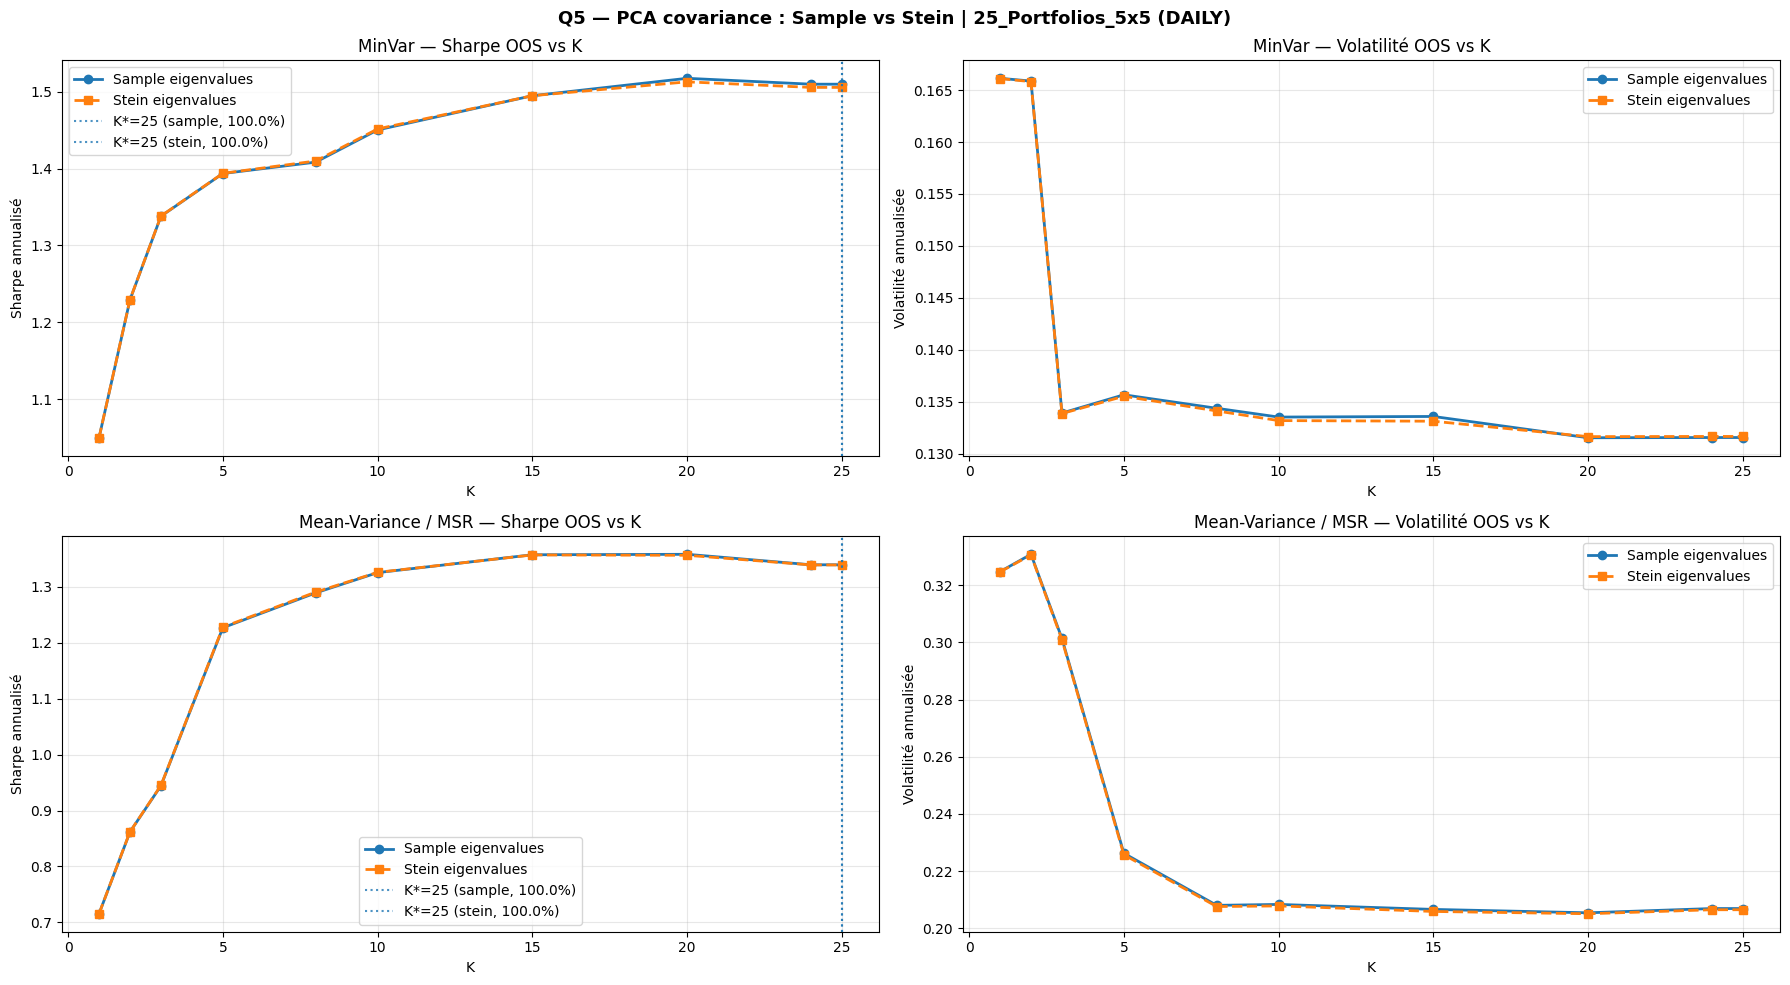

Figure sauvegardée : q5_pca_stein_25_Portfolios_5x5_daily.png

Q5 | 100_Portfolios_10x10_monthly | T=672, N=100

  Grille de K évaluée : [1, 2, 3, 5, 8, 10, 15, 20, 25, 30]
    Fenêtre  10 calculée...
    Fenêtre  20 calculée...
    Fenêtre  30 calculée...
    Fenêtre  40 calculée...
    Fenêtre  50 calculée...
    Fenêtre  60 calculée...
    Fenêtre  70 calculée...
    Fenêtre  80 calculée...
    Fenêtre  90 calculée...

Q5 — PCA covariance | 100_Portfolios_10x10 | MONTHLY

--- Minimum-Variance ---
    K |  Sample Sharpe |  Stein Sharpe |  Sample Vol |  Stein Vol |  Sample TO |  Stein TO
------------------------------------------------------------------------------------------
    1 |         0.8453 |        0.8780 |      0.1991 |     0.1907 |     0.4299 |    0.5132
    2 |         1.0381 |        1.1099 |      0.1696 |     0.1594 |     0.8934 |    1.0091
    3 |         1.2275 |        1.2525 |      0.1355 |     0.1304 |     1.0101 |    1.1680
    5 |         1.3060 |        1.3156 |

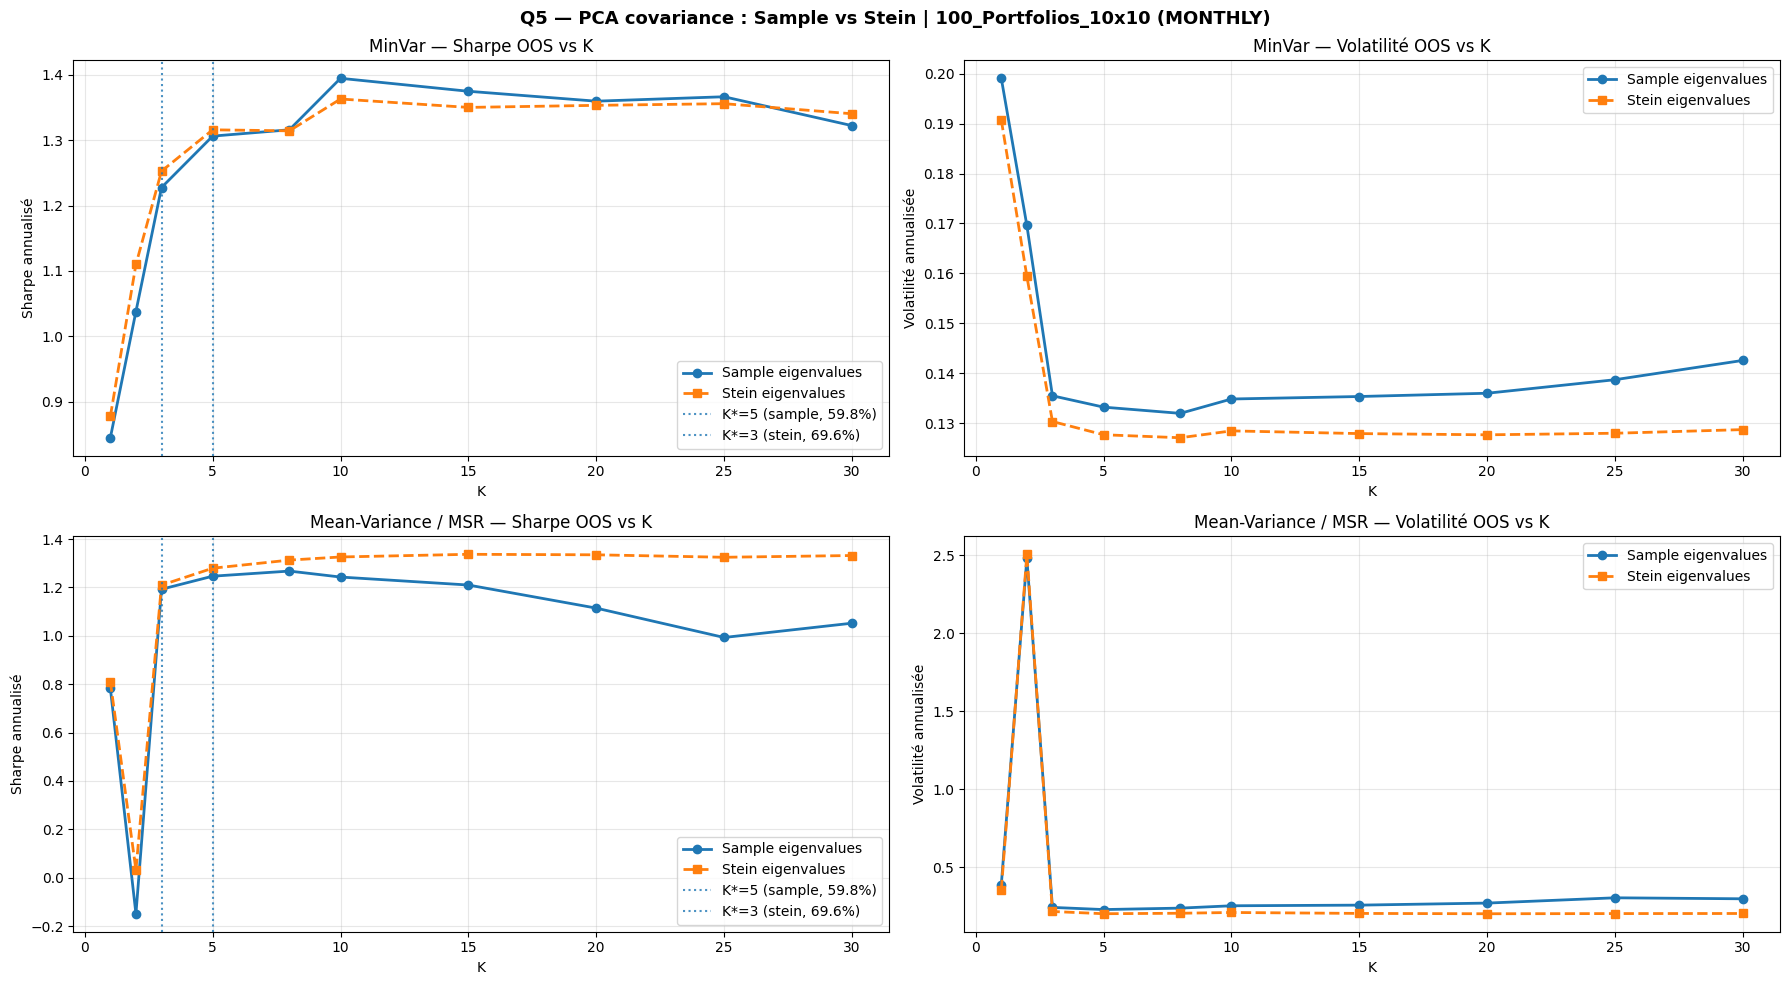

Figure sauvegardée : q5_pca_stein_100_Portfolios_10x10_monthly.png

Q5 | 100_Portfolios_10x10_daily | T=14121, N=100

  Grille de K évaluée : [1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 75, 100]
    Fenêtre  10 calculée...
    Fenêtre  20 calculée...
    Fenêtre  30 calculée...
    Fenêtre  40 calculée...
    Fenêtre  50 calculée...
    Fenêtre  60 calculée...
    Fenêtre  70 calculée...
    Fenêtre  80 calculée...
    Fenêtre  90 calculée...

Q5 — PCA covariance | 100_Portfolios_10x10 | DAILY

--- Minimum-Variance ---
    K |  Sample Sharpe |  Stein Sharpe |  Sample Vol |  Stein Vol |  Sample TO |  Stein TO
------------------------------------------------------------------------------------------
    1 |         1.0979 |        1.0966 |      0.1504 |     0.1502 |     0.3935 |    0.4037
    2 |         1.2869 |        1.2830 |      0.1438 |     0.1436 |     0.3800 |    0.3941
    3 |         1.3736 |        1.3724 |      0.1245 |     0.1243 |     0.5775 |    0.6062
    5 |         1.3797 |    

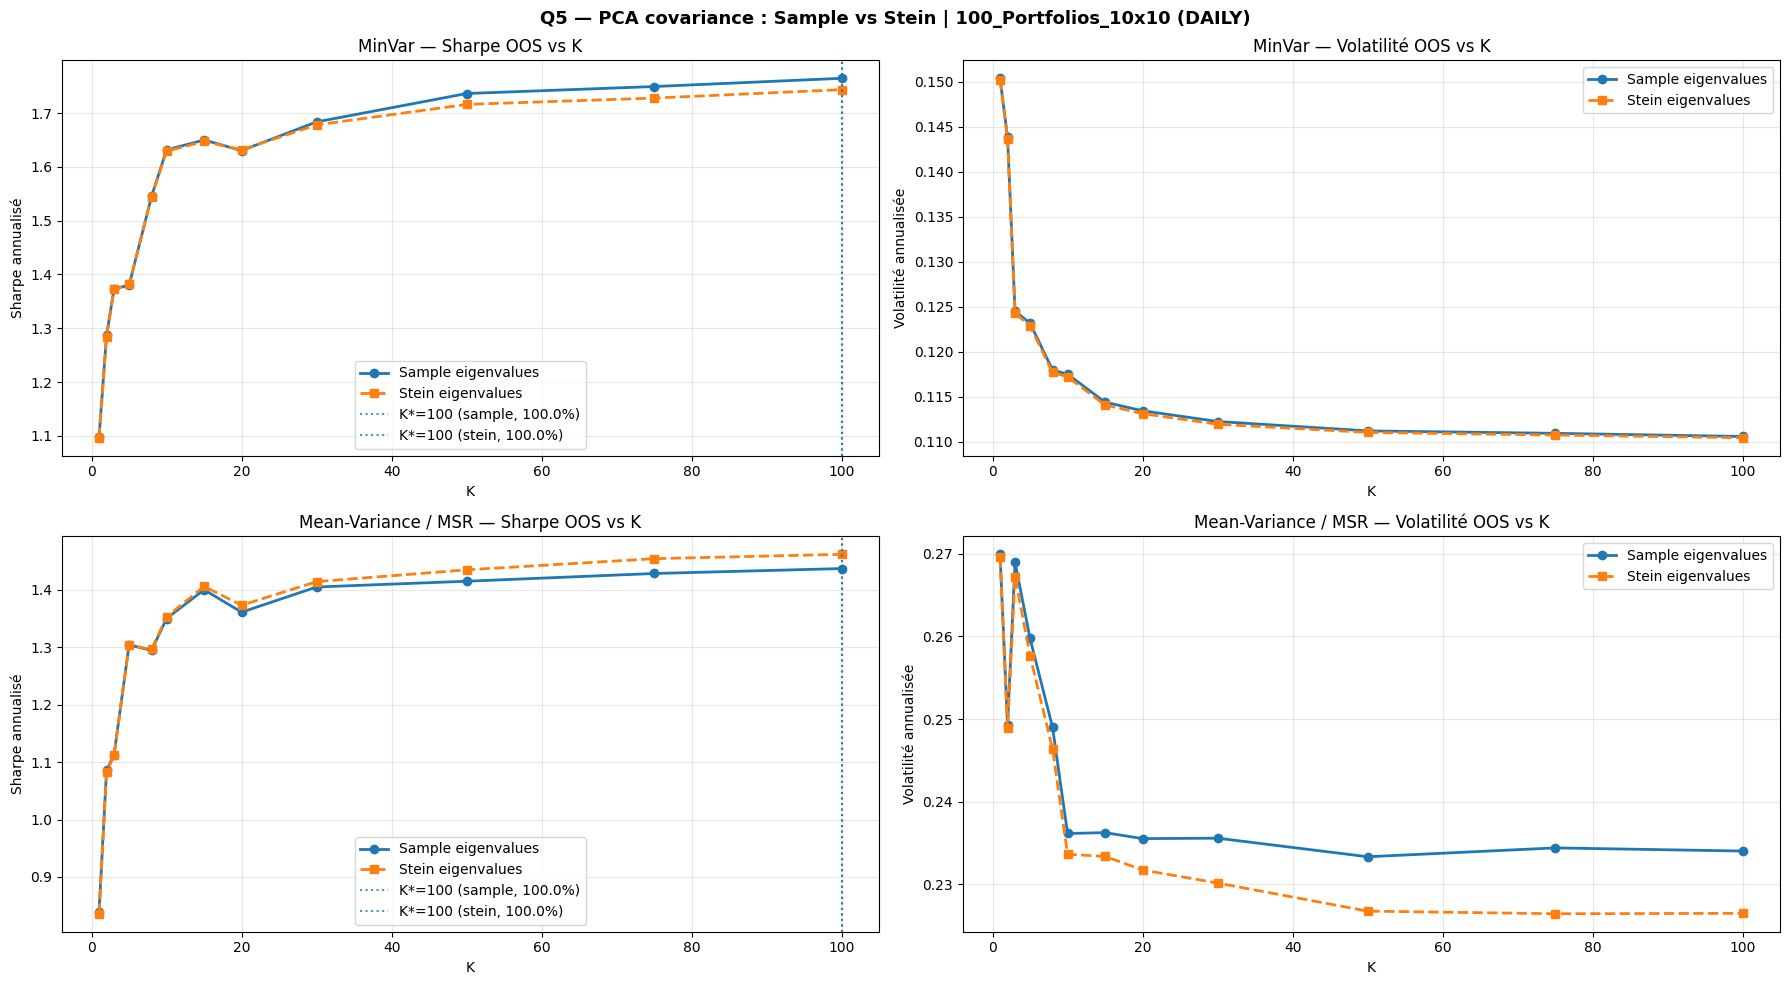

Figure sauvegardée : q5_pca_stein_100_Portfolios_10x10_daily.png

Q5 | 10_Industry_Portfolios_monthly | T=672, N=10

  Grille de K évaluée : [1, 2, 3, 5, 8, 10]
    Fenêtre  10 calculée...
    Fenêtre  20 calculée...
    Fenêtre  30 calculée...
    Fenêtre  40 calculée...
    Fenêtre  50 calculée...
    Fenêtre  60 calculée...
    Fenêtre  70 calculée...
    Fenêtre  80 calculée...
    Fenêtre  90 calculée...

Q5 — PCA covariance | 10_Industry_Portfolios | MONTHLY

--- Minimum-Variance ---
    K |  Sample Sharpe |  Stein Sharpe |  Sample Vol |  Stein Vol |  Sample TO |  Stein TO
------------------------------------------------------------------------------------------
    1 |         0.8630 |        0.8736 |      0.1340 |     0.1331 |     0.1401 |    0.1401
    2 |         0.9556 |        0.9638 |      0.1346 |     0.1331 |     0.2436 |    0.2343
    3 |         0.9279 |        0.9350 |      0.1263 |     0.1250 |     0.3228 |    0.3046
    5 |         0.9544 |        0.9633 |      0.12

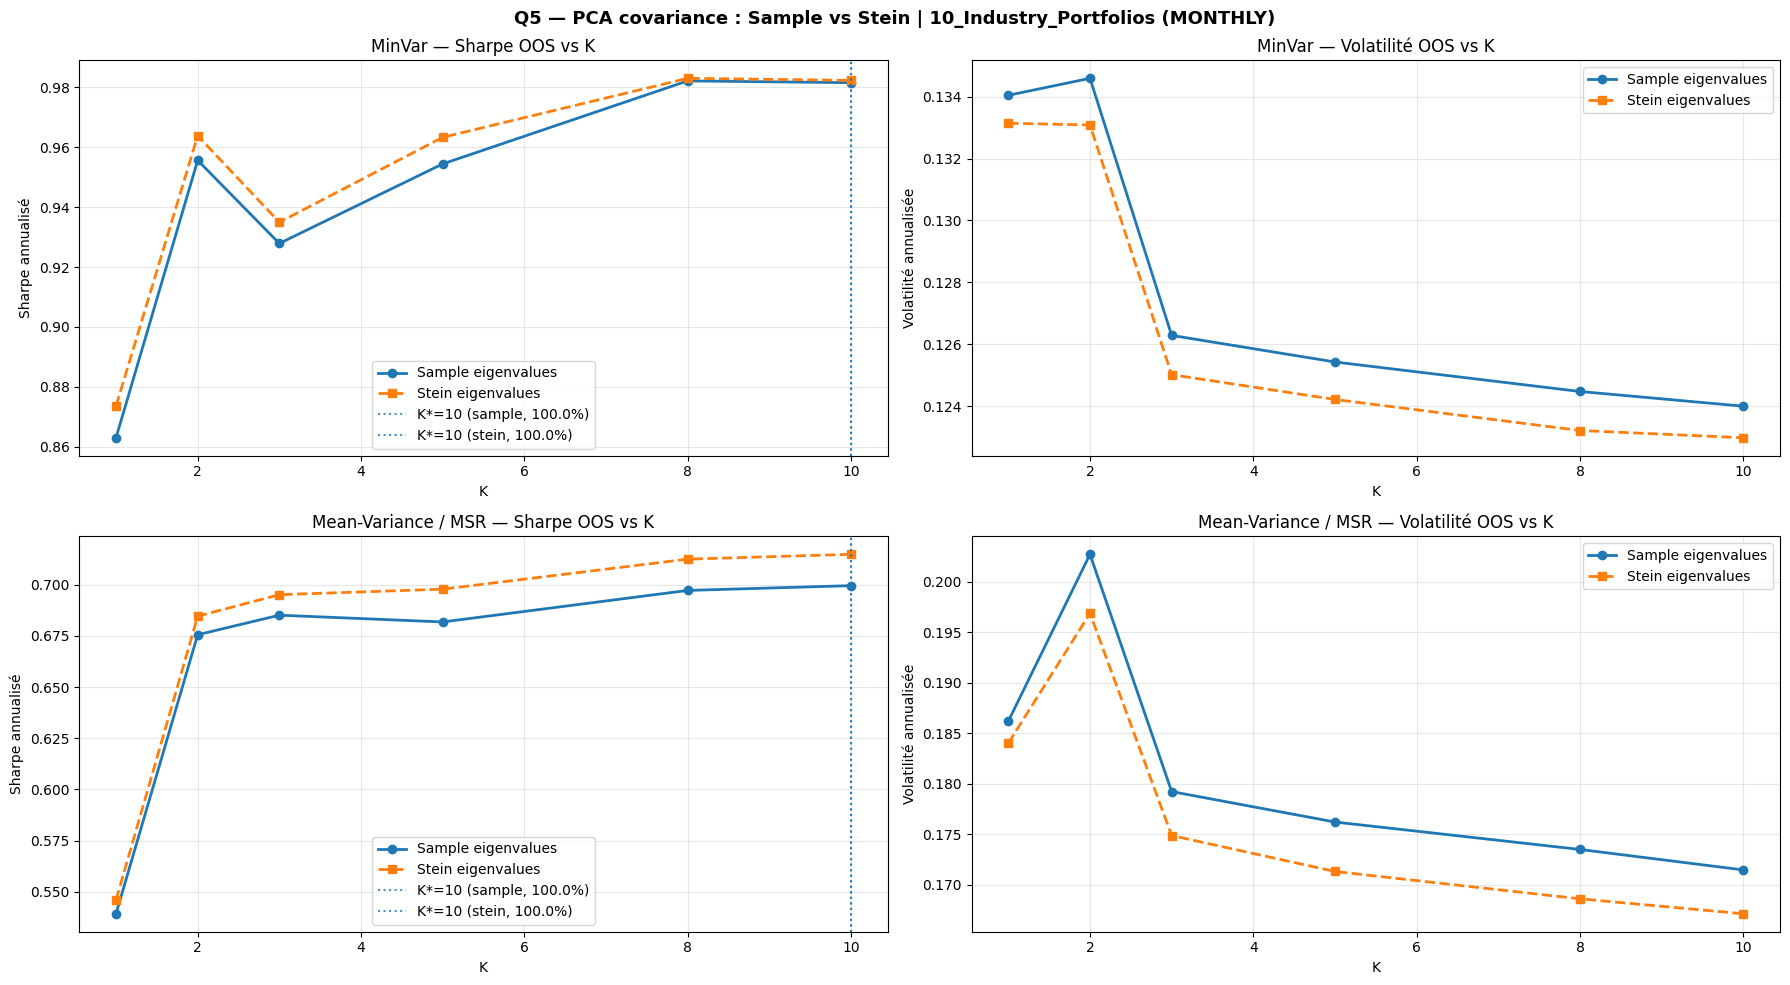

Figure sauvegardée : q5_pca_stein_10_Industry_Portfolios_monthly.png

Q5 | 10_Industry_Portfolios_daily | T=14121, N=10

  Grille de K évaluée : [1, 2, 3, 5, 8, 10]
    Fenêtre  10 calculée...
    Fenêtre  20 calculée...
    Fenêtre  30 calculée...
    Fenêtre  40 calculée...
    Fenêtre  50 calculée...
    Fenêtre  60 calculée...
    Fenêtre  70 calculée...
    Fenêtre  80 calculée...
    Fenêtre  90 calculée...

Q5 — PCA covariance | 10_Industry_Portfolios | DAILY

--- Minimum-Variance ---
    K |  Sample Sharpe |  Stein Sharpe |  Sample Vol |  Stein Vol |  Sample TO |  Stein TO
------------------------------------------------------------------------------------------
    1 |         0.8085 |        0.8087 |      0.1509 |     0.1509 |     0.1341 |    0.1341
    2 |         0.8217 |        0.8222 |      0.1477 |     0.1476 |     0.1677 |    0.1671
    3 |         0.8858 |        0.8865 |      0.1356 |     0.1356 |     0.2129 |    0.2119
    5 |         0.8616 |        0.8622 |      0.

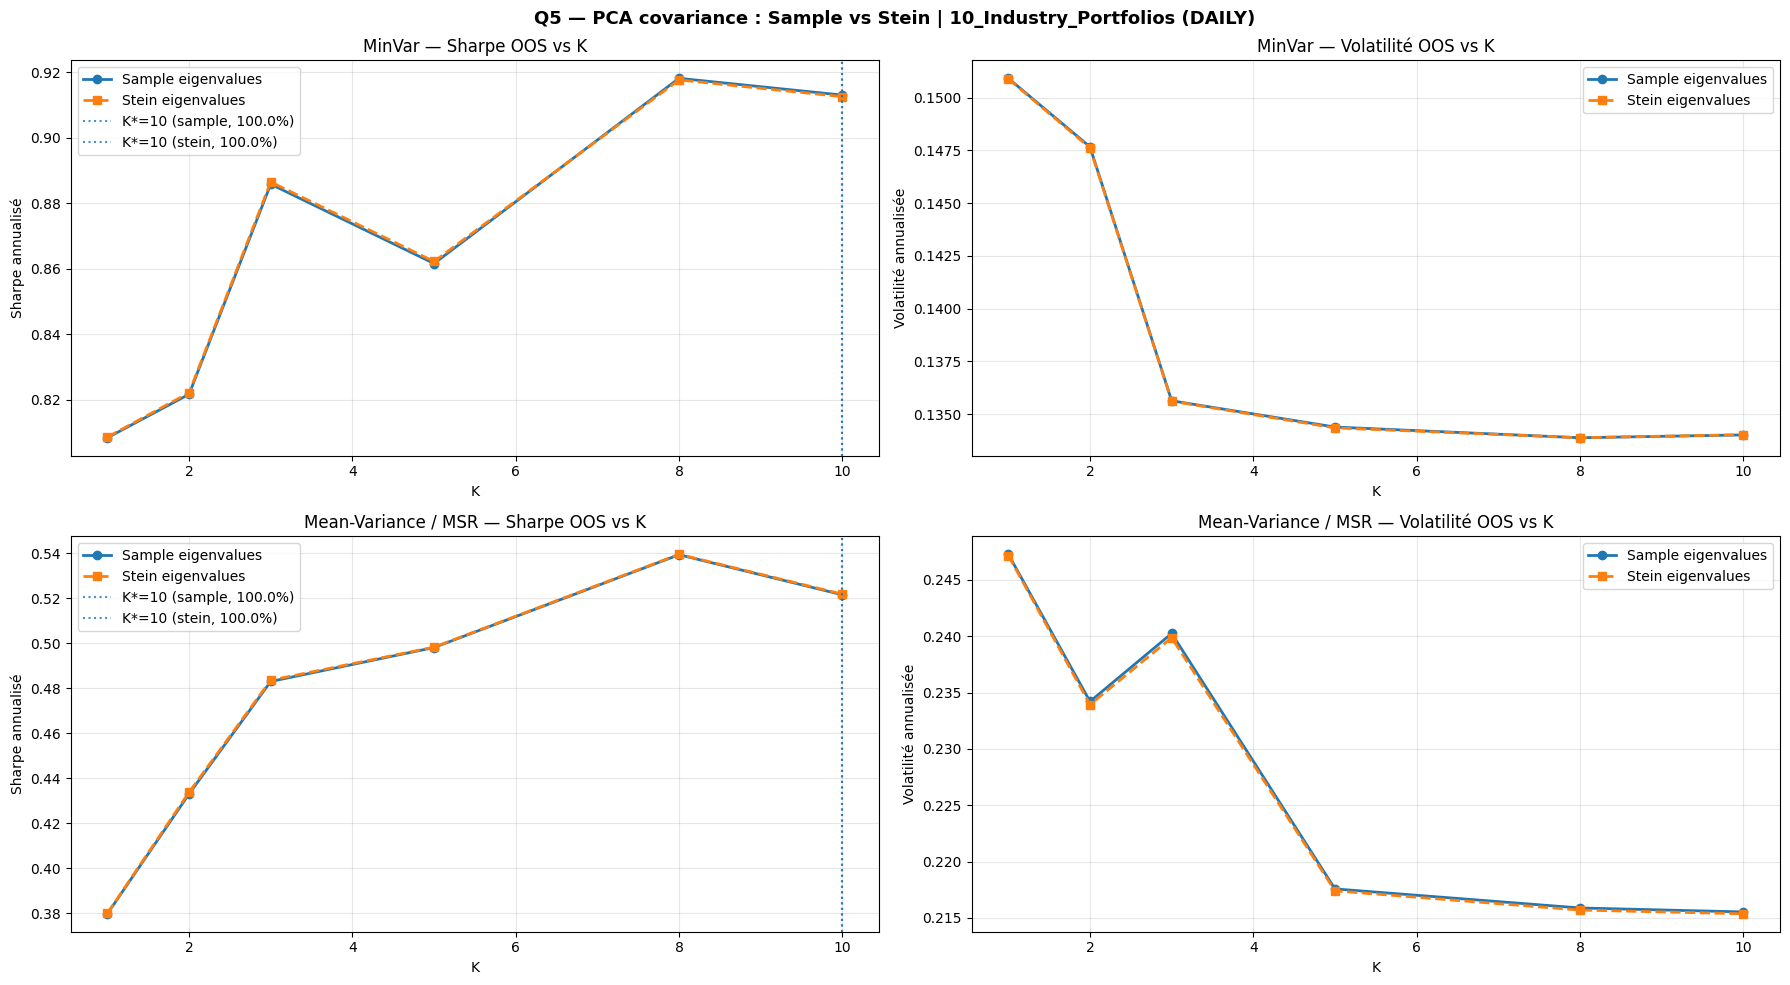

Figure sauvegardée : q5_pca_stein_10_Industry_Portfolios_daily.png

Q5 | 48_Industry_Portfolios_monthly | T=672, N=48

  Grille de K évaluée : [1, 2, 3, 5, 8, 10, 15, 20, 24, 30, 40, 48]
    Fenêtre  10 calculée...
    Fenêtre  20 calculée...
    Fenêtre  30 calculée...
    Fenêtre  40 calculée...
    Fenêtre  50 calculée...
    Fenêtre  60 calculée...
    Fenêtre  70 calculée...
    Fenêtre  80 calculée...
    Fenêtre  90 calculée...

Q5 — PCA covariance | 48_Industry_Portfolios | MONTHLY

--- Minimum-Variance ---
    K |  Sample Sharpe |  Stein Sharpe |  Sample Vol |  Stein Vol |  Sample TO |  Stein TO
------------------------------------------------------------------------------------------
    1 |         0.8920 |        0.9205 |      0.1388 |     0.1358 |     0.2785 |    0.3736
    2 |         0.9122 |        0.9481 |      0.1313 |     0.1279 |     0.3240 |    0.4303
    3 |         1.0425 |        1.0543 |      0.1244 |     0.1220 |     0.4743 |    0.5516
    5 |         0.9847 |

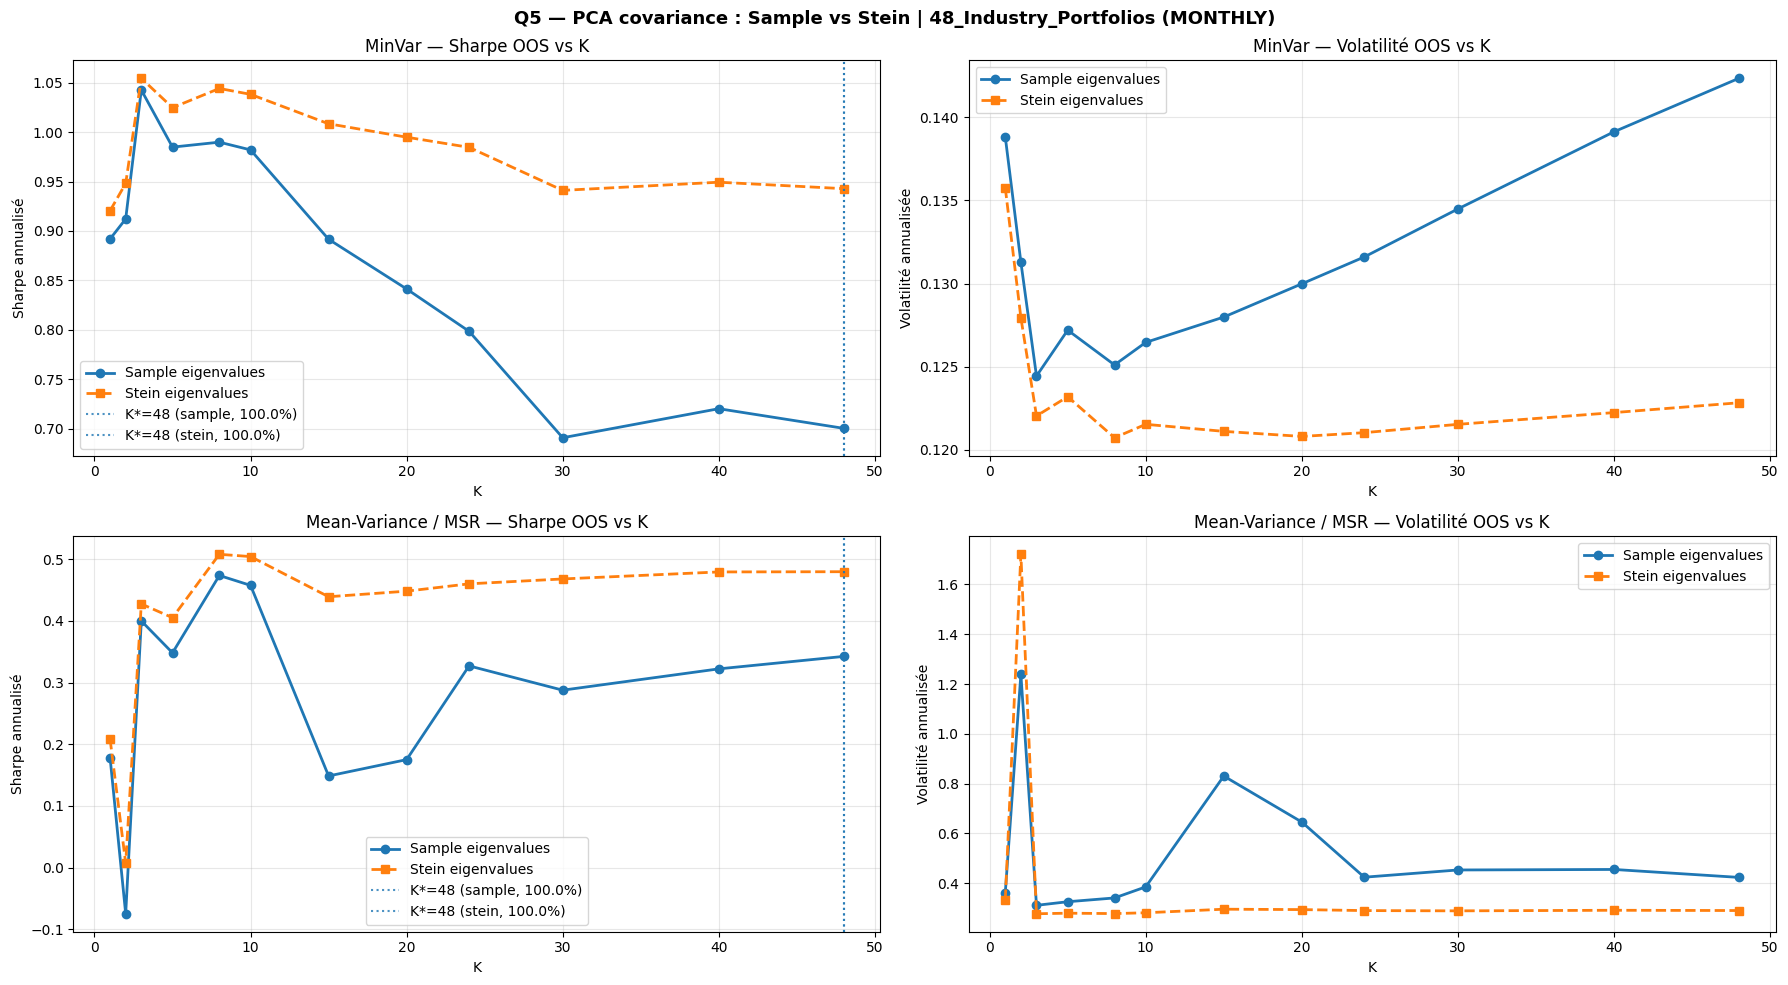

Figure sauvegardée : q5_pca_stein_48_Industry_Portfolios_monthly.png

Q5 | 48_Industry_Portfolios_daily | T=14121, N=48

  Grille de K évaluée : [1, 2, 3, 5, 8, 10, 15, 20, 24, 30, 40, 48]
    Fenêtre  10 calculée...
    Fenêtre  20 calculée...
    Fenêtre  30 calculée...
    Fenêtre  40 calculée...
    Fenêtre  50 calculée...
    Fenêtre  60 calculée...
    Fenêtre  70 calculée...
    Fenêtre  80 calculée...
    Fenêtre  90 calculée...

Q5 — PCA covariance | 48_Industry_Portfolios | DAILY

--- Minimum-Variance ---
    K |  Sample Sharpe |  Stein Sharpe |  Sample Vol |  Stein Vol |  Sample TO |  Stein TO
------------------------------------------------------------------------------------------
    1 |         0.7713 |        0.7716 |      0.1535 |     0.1534 |     0.2051 |    0.2049
    2 |         0.8568 |        0.8575 |      0.1421 |     0.1420 |     0.2632 |    0.2626
    3 |         0.8431 |        0.8445 |      0.1413 |     0.1412 |     0.3292 |    0.3277
    5 |         0.8658 |

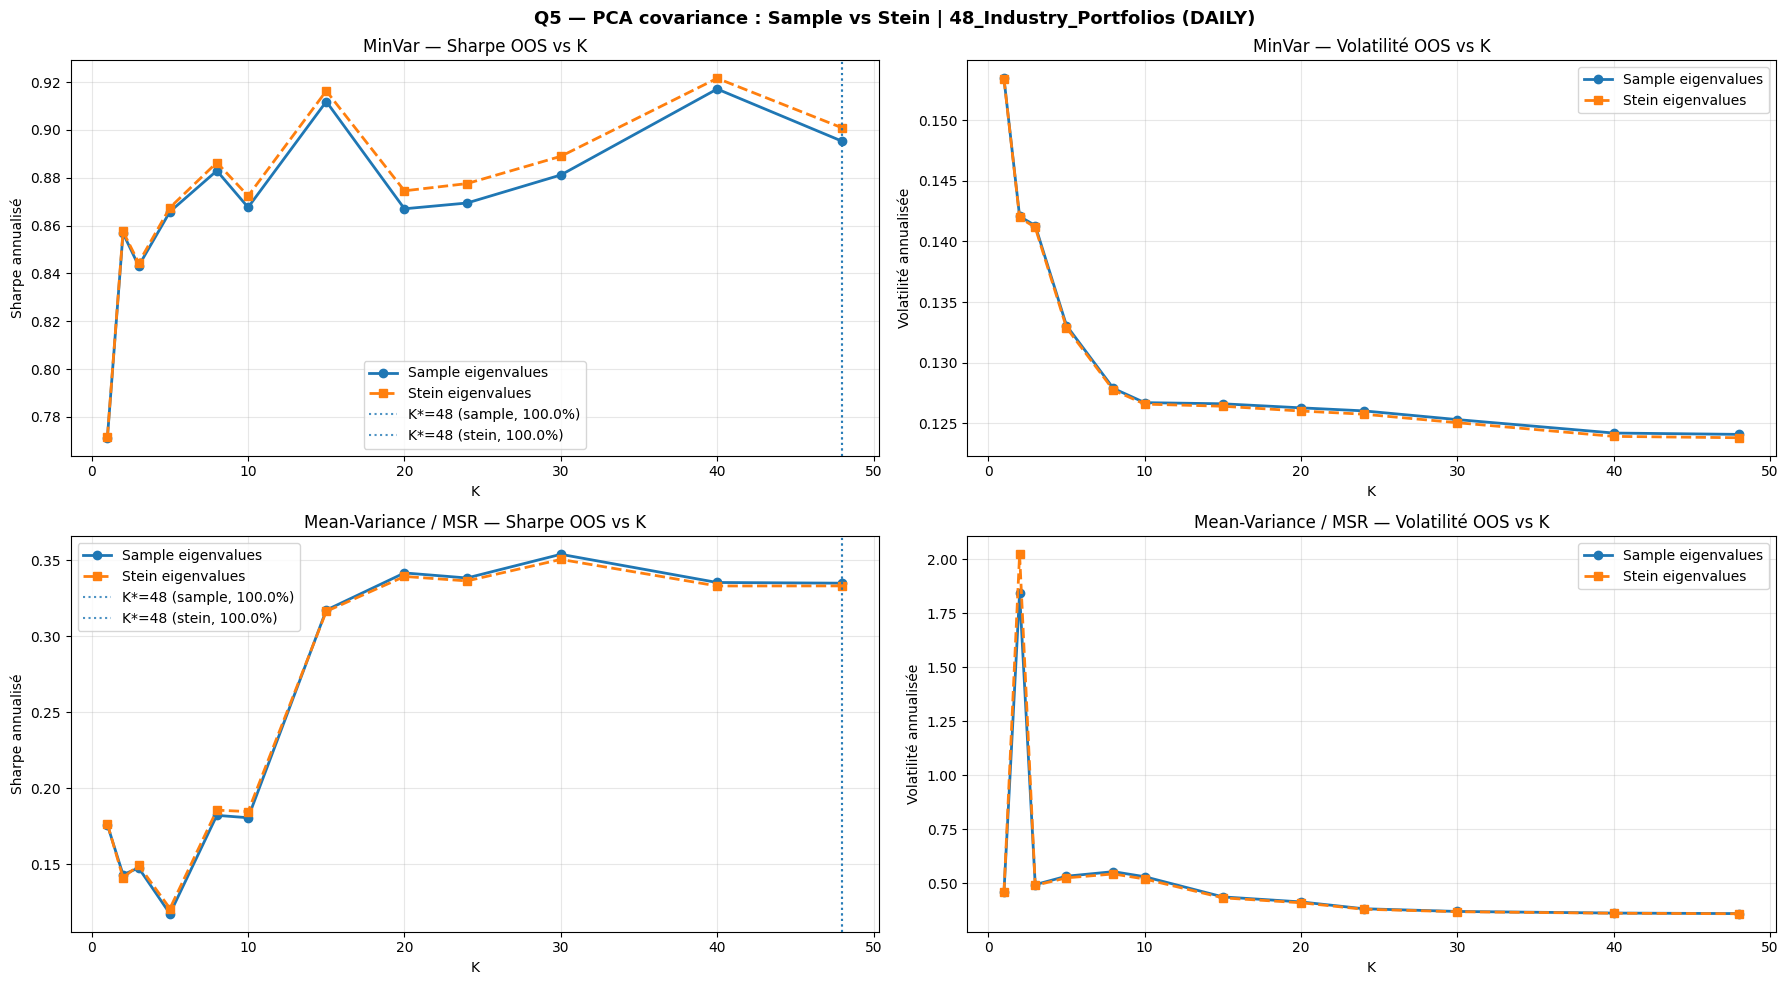

Figure sauvegardée : q5_pca_stein_48_Industry_Portfolios_daily.png


In [ ]:
from collections import Counter
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 0. PARAMÈTRES GÉNÉRAUX
# ============================================================

def get_window_params(freq):
    if freq == "monthly":
        return 120, 6          # 10 ans / 6 mois
    else:
        return 2520, 126       # 10 ans / 6 mois daily


def annualize(mean_ret, vol_ret, freq):
    factor = 12 if freq == "monthly" else 252
    ann_mean = mean_ret * factor
    ann_vol = vol_ret * np.sqrt(factor)
    ann_sr = ann_mean / ann_vol if ann_vol > 1e-10 else np.nan
    return ann_mean, ann_vol, ann_sr


def compute_performance(port_returns, freq):
    r = np.asarray(port_returns, dtype=float)
    valid = np.isfinite(r)

    if valid.sum() == 0:
        return {
            "Mean": np.nan,
            "Vol": np.nan,
            "Sharpe": np.nan,
            "FailRate": 1.0
        }

    rv = r[valid]
    ann_mean, ann_vol, ann_sr = annualize(
        np.mean(rv),
        np.std(rv, ddof=1),
        freq
    )

    return {
        "Mean": ann_mean,
        "Vol": ann_vol,
        "Sharpe": ann_sr,
        "FailRate": 1 - valid.sum() / len(r)
    }


def compute_turnover(weights_list):
    valid = [
        w for w in weights_list
        if w is not None and np.all(np.isfinite(w))
    ]

    if len(valid) < 2:
        return np.nan

    return np.mean([
        np.sum(np.abs(valid[t] - valid[t-1]))
        for t in range(1, len(valid))
    ])


# ============================================================
# 1. OUTILS PCA ET STEIN
# ============================================================

def _pava_decreasing(y):

    y = np.asarray(y, dtype=float)
    n = len(y)

    levels = []
    weights = []

    for i in range(n):
        levels.append(y[i])
        weights.append(1.0)

        while len(levels) >= 2 and levels[-2] < levels[-1]:
            w_new = weights[-2] + weights[-1]
            lev_new = (
                weights[-2] * levels[-2]
                + weights[-1] * levels[-1]
            ) / w_new

            levels[-2] = lev_new
            weights[-2] = w_new
            levels.pop()
            weights.pop()

    out = np.empty(n)
    idx = 0

    for lev, wgt in zip(levels, weights):
        m = int(round(wgt))
        out[idx:idx+m] = lev
        idx += m

    return out


def stein_eigenvalues(lambdas, T, N, eps=1e-10):

    if T < N:
        return lambdas

    lambdas = np.maximum(np.asarray(lambdas, dtype=float), eps)
    alpha = np.zeros(N)

    for i in range(N):
        diffs = lambdas[i] - lambdas
        mask = np.arange(N) != i
        d = diffs[mask]

        d = np.where(np.abs(d) < eps, np.sign(d) * eps + eps, d)

        alpha[i] = (T - N + 1) + 2 * lambdas[i] * np.sum(1.0 / d)

    lambdas_stein = np.where(
        np.abs(alpha) < eps,
        lambdas,
        T * lambdas / alpha
    )

    bad = ~np.isfinite(lambdas_stein) | (lambdas_stein <= eps)
    lambdas_stein[bad] = lambdas[bad]

    lambdas_stein = _pava_decreasing(lambdas_stein)

    return np.maximum(lambdas_stein, eps)


def eigen_decomp_array(X):

    Sigma = np.cov(X.T)
    Sigma = (Sigma + Sigma.T) / 2

    eigvals, eigvecs = np.linalg.eigh(Sigma)
    idx = np.argsort(eigvals)[::-1]

    eigvals = np.maximum(eigvals[idx], 1e-12)
    eigvecs = eigvecs[:, idx]

    return eigvals, eigvecs


def build_sigma_pca(eigvals, eigvecs, K, N):


    K = int(np.clip(K, 1, N))

    Vk = eigvecs[:, :K]
    Lk = np.diag(eigvals[:K])

    if K < N:
        sigma_noise = np.mean(eigvals[K:])
    else:
        sigma_noise = 1e-12

    Pk = Vk @ Vk.T

    Sigma_K = Vk @ Lk @ Vk.T + sigma_noise * (np.eye(N) - Pk)
    Sigma_K = (Sigma_K + Sigma_K.T) / 2

    return Sigma_K


# ============================================================
# 2. CRITÈRE DE BAI & NG POUR CHOISIR K
# ============================================================

def bai_ng_criterion(lambdas, K, T, N):
    """
    Critère de Bai & Ng :

    """

    if K >= N:
        V_K = 1e-12
    else:
        V_K = np.sum(lambdas[K:]) / N

    V_K = max(V_K, 1e-12)

    penalty = K * ((N + T) / (N * T)) * np.log((N * T) / (N + T))

    return np.log(V_K) + penalty


def select_K_bai_ng(lambdas, K_grid, T, N):
    scores = {
        K: bai_ng_criterion(lambdas, K, T, N)
        for K in K_grid
    }

    K_star = min(scores, key=scores.get)

    return K_star, scores


def dominant_K(K_selected):
    """
    Retourne le K le plus fréquemment sélectionné.
    """
    counter = Counter(K_selected)
    K_dom, count = counter.most_common(1)[0]
    freq = count / len(K_selected)

    return K_dom, freq, counter


# ============================================================
# 3. PORTEFEUILLES MINVAR ET MEAN-VARIANCE / MSR
# ============================================================

def compute_minvar_from_sigma(Sigma):
    N = Sigma.shape[0]
    ones = np.ones(N)

    try:
        w = np.linalg.solve(Sigma, ones)
        denom = ones @ w

        if abs(denom) < 1e-10:
            return np.full(N, np.nan)

        return w / denom

    except np.linalg.LinAlgError:
        return np.full(N, np.nan)


def compute_msr_from_sigma(Sigma, mu, tol=1e-10):

    N = Sigma.shape[0]
    ones = np.ones(N)

    try:
        w = np.linalg.solve(Sigma, mu)
        denom = ones @ w

        if abs(denom) < tol:
            return np.full(N, np.nan)

        return w / denom

    except np.linalg.LinAlgError:
        return np.full(N, np.nan)


# ============================================================
# 4. GRILLE DE K
# ============================================================

def make_K_grid(N, freq):

    if N <= 10:
        candidates = [1, 2, 3, 5, 8, 10]
    elif N <= 25:
        candidates = [1, 2, 3, 5, 8, 10, 15, 20, 24, 25]
    elif N <= 48:
        candidates = [1, 2, 3, 5, 8, 10, 15, 20, 24, 30, 40, 48]
    else:
        if freq == "monthly":
            candidates = [1, 2, 3, 5, 8, 10, 15, 20, 25, 30]
        else:
            candidates = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 75, 100]

    return sorted(set(k for k in candidates if 1 <= k <= N))


# ============================================================
# 5. MOTEUR OOS POUR UN DATASET
# ============================================================

def run_q5_one_dataset(returns, freq, dataset_name):
    window, roll_step = get_window_params(freq)

    T, N = returns.shape
    K_grid = make_K_grid(N, freq)

    print(f"\n  Grille de K évaluée : {K_grid}")

    tags = [
        "minvar_sample",
        "minvar_stein",
        "msr_sample",
        "msr_stein"
    ]

    res = {
        tag: {K: {"oos": [], "ws": []} for K in K_grid}
        for tag in tags
    }

    for tag in tags:
        res[tag]["optimal"] = {
            "oos": [],
            "ws": [],
            "K_selected": []
        }

    t = window
    win_count = 0

    while t < T:
        step = min(roll_step, T - t)

        train = returns.iloc[t-window:t]
        test = returns.iloc[t:t+step]

        X_train = train.values
        X_test = test.values

        mu_train = X_train.mean(axis=0)

        eigvals_sample, eigvecs = eigen_decomp_array(X_train)
        eigvals_stein = stein_eigenvalues(
            eigvals_sample,
            len(X_train),
            N
        )

        eig_dict = {
            "sample": eigvals_sample,
            "stein": eigvals_stein
        }

        for method in ["sample", "stein"]:
            eigvals = eig_dict[method]

            K_opt, _ = select_K_bai_ng(
                eigvals,
                K_grid,
                len(X_train),
                N
            )

            sigmas = {
                K: build_sigma_pca(eigvals, eigvecs, K, N)
                for K in K_grid
            }

            for portfolio in ["minvar", "msr"]:
                tag = f"{portfolio}_{method}"
                res[tag]["optimal"]["K_selected"].append(K_opt)

                for K in K_grid:
                    Sigma_K = sigmas[K]

                    if portfolio == "minvar":
                        w = compute_minvar_from_sigma(Sigma_K)
                    else:
                        w = compute_msr_from_sigma(Sigma_K, mu_train)

                    res[tag][K]["ws"].append(w)

                    if np.any(~np.isfinite(w)):
                        res[tag][K]["oos"].extend([np.nan] * step)
                    else:
                        res[tag][K]["oos"].extend(X_test @ w)

                    if K == K_opt:
                        res[tag]["optimal"]["ws"].append(w)

                        if np.any(~np.isfinite(w)):
                            res[tag]["optimal"]["oos"].extend([np.nan] * step)
                        else:
                            res[tag]["optimal"]["oos"].extend(X_test @ w)

        t += step
        win_count += 1

        if win_count % 10 == 0:
            print(f"    Fenêtre {win_count:>3} calculée...")

    final_res = {tag: {} for tag in tags}

    for tag in tags:
        for K in K_grid:
            final_res[tag][K] = {
                "perf": compute_performance(res[tag][K]["oos"], freq),
                "turnover": compute_turnover(res[tag][K]["ws"])
            }

        final_res[tag]["optimal"] = {
            "perf": compute_performance(res[tag]["optimal"]["oos"], freq),
            "turnover": compute_turnover(res[tag]["optimal"]["ws"]),
            "K_selected": res[tag]["optimal"]["K_selected"]
        }

    return final_res, K_grid


# ============================================================
# 6. AFFICHAGE DES RÉSULTATS
# ============================================================

def print_results_q5(dataset_name, freq, all_res, K_grid):
    print(f"\n{'='*90}")
    print(f"Q5 — PCA covariance | {dataset_name} | {freq.upper()}")
    print(f"{'='*90}")

    for portfolio in ["minvar", "msr"]:
        title = "Minimum-Variance" if portfolio == "minvar" else "Mean-Variance / MSR"

        print(f"\n--- {title} ---")
        print(
            f"{'K':>5} | "
            f"{'Sample Sharpe':>14} | {'Stein Sharpe':>13} | "
            f"{'Sample Vol':>11} | {'Stein Vol':>10} | "
            f"{'Sample TO':>10} | {'Stein TO':>9}"
        )
        print("-" * 90)

        for K in K_grid:
            sample = all_res[f"{portfolio}_sample"][K]
            stein = all_res[f"{portfolio}_stein"][K]

            print(
                f"{K:>5} | "
                f"{sample['perf']['Sharpe']:>14.4f} | "
                f"{stein['perf']['Sharpe']:>13.4f} | "
                f"{sample['perf']['Vol']:>11.4f} | "
                f"{stein['perf']['Vol']:>10.4f} | "
                f"{sample['turnover']:>10.4f} | "
                f"{stein['turnover']:>9.4f}"
            )

        for method in ["sample", "stein"]:
            tag = f"{portfolio}_{method}"
            opt = all_res[tag]["optimal"]

            K_dom, freq_dom, counter = dominant_K(opt["K_selected"])

            perf = opt["perf"]
            turnover = opt["turnover"]

            print(f"\nK* retenu par Bai & Ng ({method}) : {K_dom}")
            print(f"Fréquence de sélection : {100 * freq_dom:.2f}%")
            print(f"Distribution des K* : {dict(counter)}")
            print(
                f"Performance optimale ({method}) : "
                f"Mean={perf['Mean']:.4f}, "
                f"Vol={perf['Vol']:.4f}, "
                f"Sharpe={perf['Sharpe']:.4f}, "
                f"Turnover={turnover:.4f}, "
                f"FailRate={100 * perf['FailRate']:.2f}%"
            )


# ============================================================
# 7. GRAPHIQUES
# ============================================================

def plot_results_q5(dataset_name, freq, all_res, K_grid):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    fig.suptitle(
        f"Q5 — PCA covariance : Sample vs Stein | {dataset_name} ({freq.upper()})",
        fontsize=13,
        fontweight="bold"
    )

    for row, portfolio in enumerate(["minvar", "msr"]):
        ptitle = "MinVar" if portfolio == "minvar" else "Mean-Variance / MSR"

        ax = axes[row, 0]

        sharpes_sample = [
            all_res[f"{portfolio}_sample"][K]["perf"]["Sharpe"]
            for K in K_grid
        ]

        sharpes_stein = [
            all_res[f"{portfolio}_stein"][K]["perf"]["Sharpe"]
            for K in K_grid
        ]

        ax.plot(
            K_grid,
            sharpes_sample,
            "o-",
            linewidth=2,
            label="Sample eigenvalues"
        )

        ax.plot(
            K_grid,
            sharpes_stein,
            "s--",
            linewidth=2,
            label="Stein eigenvalues"
        )

        for method in ["sample", "stein"]:
            opt = all_res[f"{portfolio}_{method}"]["optimal"]
            K_dom, freq_dom, _ = dominant_K(opt["K_selected"])

            ax.axvline(
                x=K_dom,
                linestyle=":",
                alpha=0.8,
                label=f"K*={K_dom} ({method}, {100*freq_dom:.1f}%)"
            )

        ax.set_title(f"{ptitle} — Sharpe OOS vs K")
        ax.set_xlabel("K")
        ax.set_ylabel("Sharpe annualisé")
        ax.legend()
        ax.grid(alpha=0.3)

        ax = axes[row, 1]

        vols_sample = [
            all_res[f"{portfolio}_sample"][K]["perf"]["Vol"]
            for K in K_grid
        ]

        vols_stein = [
            all_res[f"{portfolio}_stein"][K]["perf"]["Vol"]
            for K in K_grid
        ]

        ax.plot(
            K_grid,
            vols_sample,
            "o-",
            linewidth=2,
            label="Sample eigenvalues"
        )

        ax.plot(
            K_grid,
            vols_stein,
            "s--",
            linewidth=2,
            label="Stein eigenvalues"
        )

        ax.set_title(f"{ptitle} — Volatilité OOS vs K")
        ax.set_xlabel("K")
        ax.set_ylabel("Volatilité annualisée")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()

    fname = f"q5_pca_stein_{dataset_name}_{freq}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Figure sauvegardée : {fname}")


# ============================================================
# 8. PIPELINE GLOBAL QUESTION 5
# ============================================================

def run_question5(all_data):
    all_results_q5 = {}

    print("\n" + "█" * 80)
    print("QUESTION 5 — PCA covariance + Stein eigenvalues + Bai & Ng")
    print("█" * 80)

    for key, returns in all_data.items():
        freq = "monthly" if key.endswith("_monthly") else "daily"
        dataset_name = key.replace("_monthly", "").replace("_daily", "")

        T, N = returns.shape

        print(f"\n{'='*90}")
        print(f"Q5 | {key} | T={T}, N={N}")
        print(f"{'='*90}")

        res, K_grid = run_q5_one_dataset(
            returns=returns,
            freq=freq,
            dataset_name=dataset_name
        )

        all_results_q5[key] = {
            "results": res,
            "K_grid": K_grid
        }

        print_results_q5(dataset_name, freq, res, K_grid)
        plot_results_q5(dataset_name, freq, res, K_grid)

    return all_results_q5


# ============================================================
# 9. LANCEMENT
# ============================================================

all_results_q5 = run_question5(all_data)

## **Question 6**


██████████████████████████████████████████████████████████████████████████████████████████
QUESTION 6 — IC Variance-Parity Portfolio avec FastICA
██████████████████████████████████████████████████████████████████████████████████████████

Q6 | 25_Portfolios_5x5 | MONTHLY | T=672, N=25
K_grid = [1, 2, 3, 5, 8, 10, 15]
  [1/3] MinVar...
  [2/3] EW...
  [3/3] ICVP FastICA...
    K=1   | Mean=0.1338 | Vol=0.1823 | Sharpe=0.7342 | Skew=-0.7152 | Ex.Kurt=2.5638 | MVaR=0.5554 | FailRate=0.00%
    K=2   | Mean=0.1187 | Vol=0.2009 | Sharpe=0.5908 | Skew=-0.8733 | Ex.Kurt=4.2249 | MVaR=0.7030 | FailRate=0.00%
    K=3   | Mean=0.1348 | Vol=0.1876 | Sharpe=0.7189 | Skew=-0.8652 | Ex.Kurt=3.8954 | MVaR=0.6347 | FailRate=0.00%
    K=5   | Mean=0.1570 | Vol=0.1916 | Sharpe=0.8191 | Skew=-0.3214 | Ex.Kurt=1.6228 | MVaR=0.5110 | FailRate=0.00%
    K=8   | Mean=0.1561 | Vol=0.1661 | Sharpe=0.9399 | Skew=-0.2883 | Ex.Kurt=2.5402 | MVaR=0.4699 | FailRate=0.00%
    K=10  | Mean=0.1610 | Vol=0.1641 | Sharpe

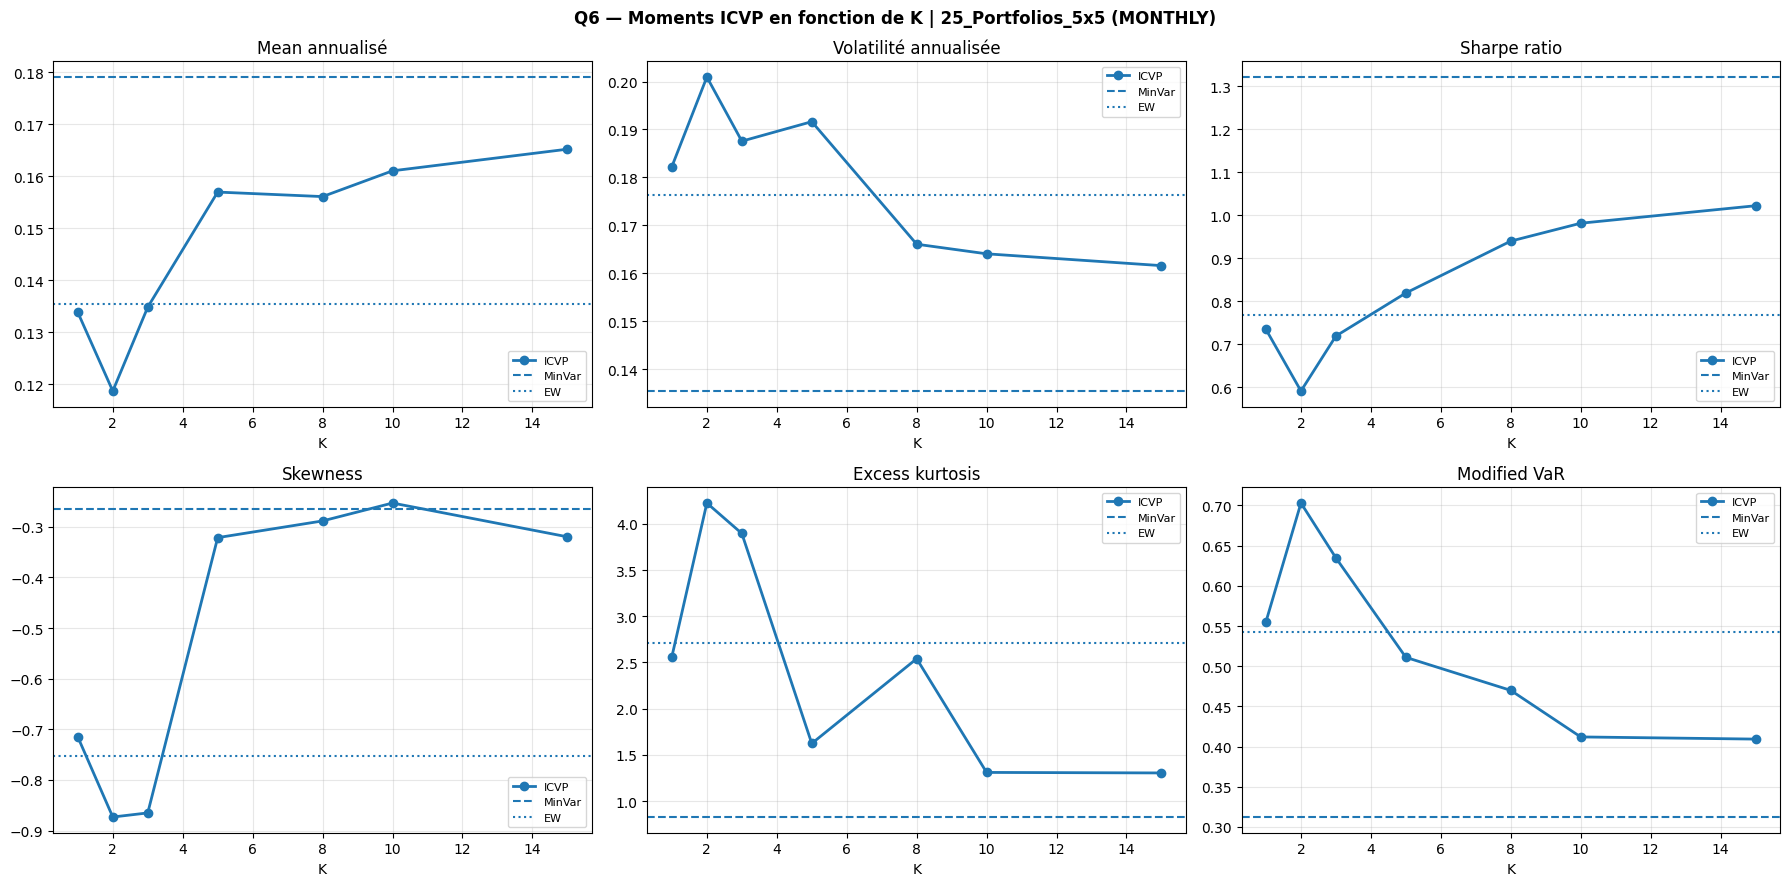

Figure sauvegardée : q6_moments_25_Portfolios_5x5_monthly.png


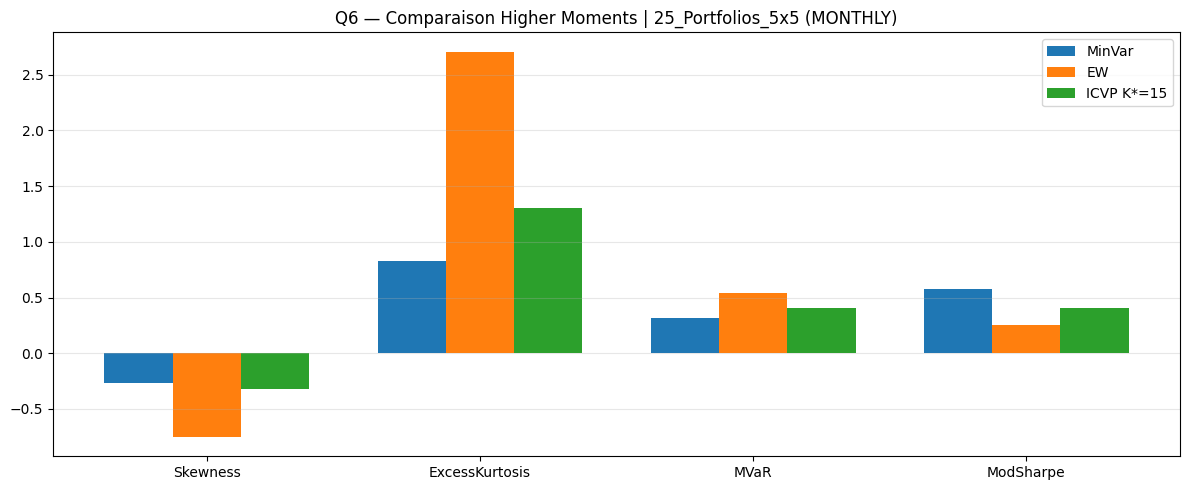

Figure sauvegardée : q6_comparison_25_Portfolios_5x5_monthly.png

Q6 | 25_Portfolios_5x5 | DAILY | T=14121, N=25
K_grid = [1, 2, 3, 5, 8, 10, 15, 20]
  [1/3] MinVar...
  [2/3] EW...
  [3/3] ICVP FastICA...
    K=1   | Mean=0.1340 | Vol=0.1860 | Sharpe=0.7207 | Skew=-0.5768 | Ex.Kurt=11.7949 | MVaR=0.9926 | FailRate=0.00%
    K=2   | Mean=0.1260 | Vol=0.2128 | Sharpe=0.5920 | Skew=-0.0142 | Ex.Kurt=22.6182 | MVaR=1.6143 | FailRate=0.00%
    K=3   | Mean=0.1780 | Vol=0.2045 | Sharpe=0.8702 | Skew=-0.2981 | Ex.Kurt=15.8349 | MVaR=1.2596 | FailRate=0.00%
    K=5   | Mean=0.1567 | Vol=0.1951 | Sharpe=0.8030 | Skew=-0.1835 | Ex.Kurt=10.8054 | MVaR=0.9607 | FailRate=0.00%
    K=8   | Mean=0.1697 | Vol=0.1786 | Sharpe=0.9501 | Skew=0.1814 | Ex.Kurt=9.2178 | MVaR=0.7638 | FailRate=0.00%
    K=10  | Mean=0.1323 | Vol=0.1828 | Sharpe=0.7239 | Skew=-0.0201 | Ex.Kurt=9.7850 | MVaR=0.8378 | FailRate=0.00%
    K=15  | Mean=0.1844 | Vol=0.1758 | Sharpe=1.0490 | Skew=0.1706 | Ex.Kurt=7.2325 | MVaR=0.67

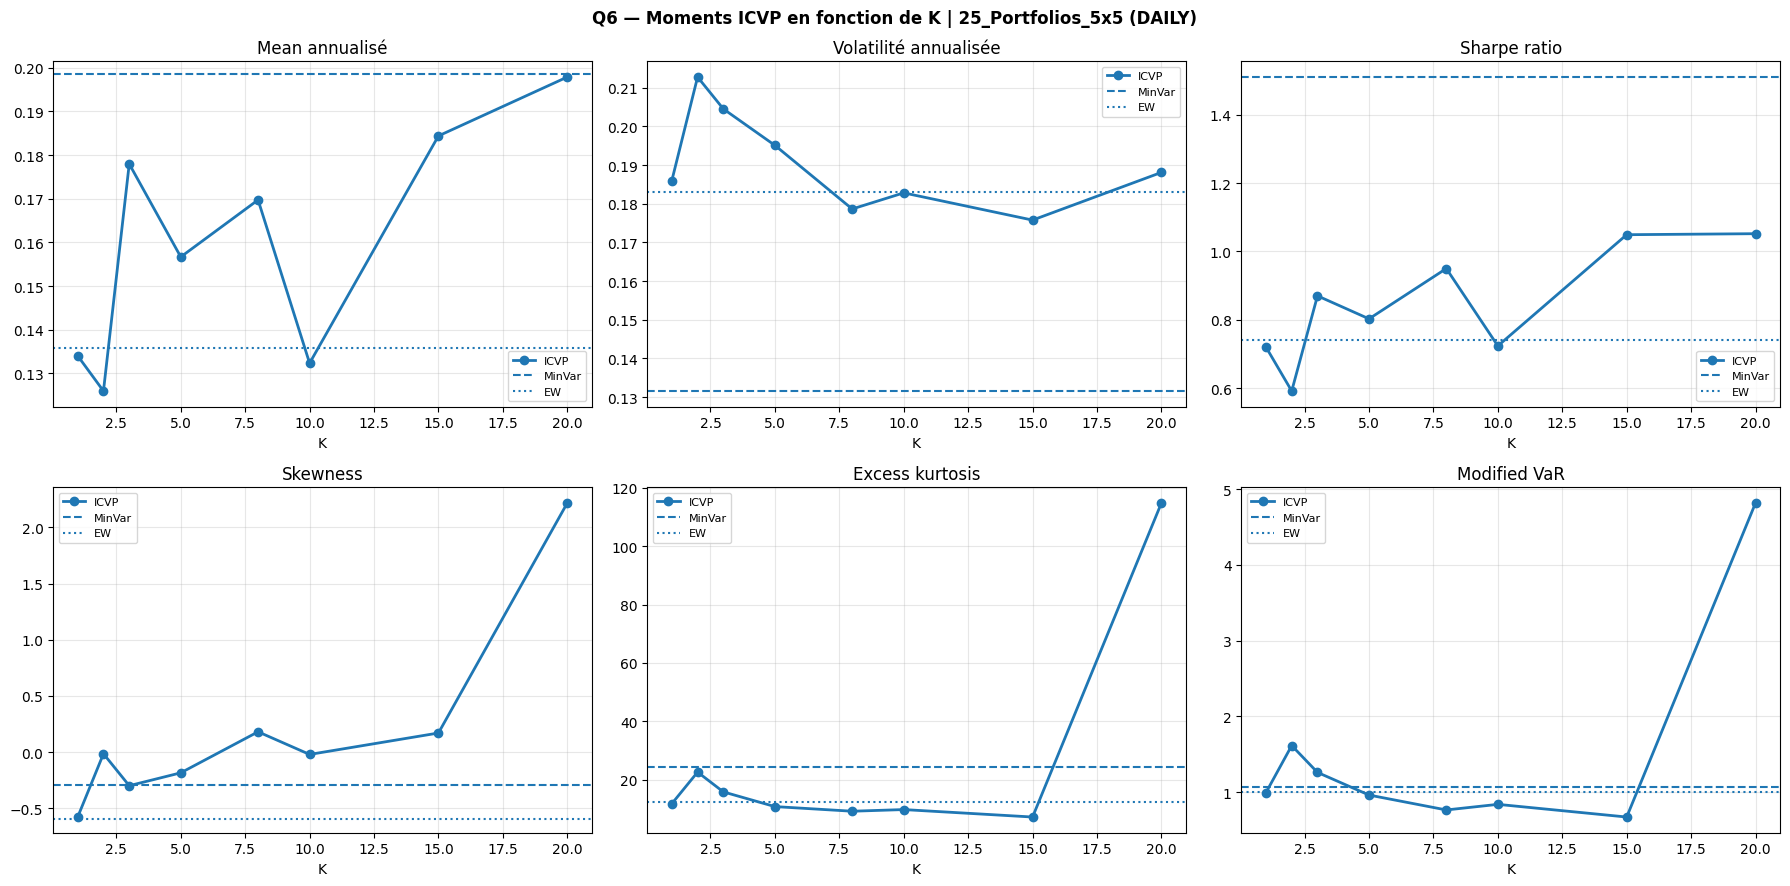

Figure sauvegardée : q6_moments_25_Portfolios_5x5_daily.png


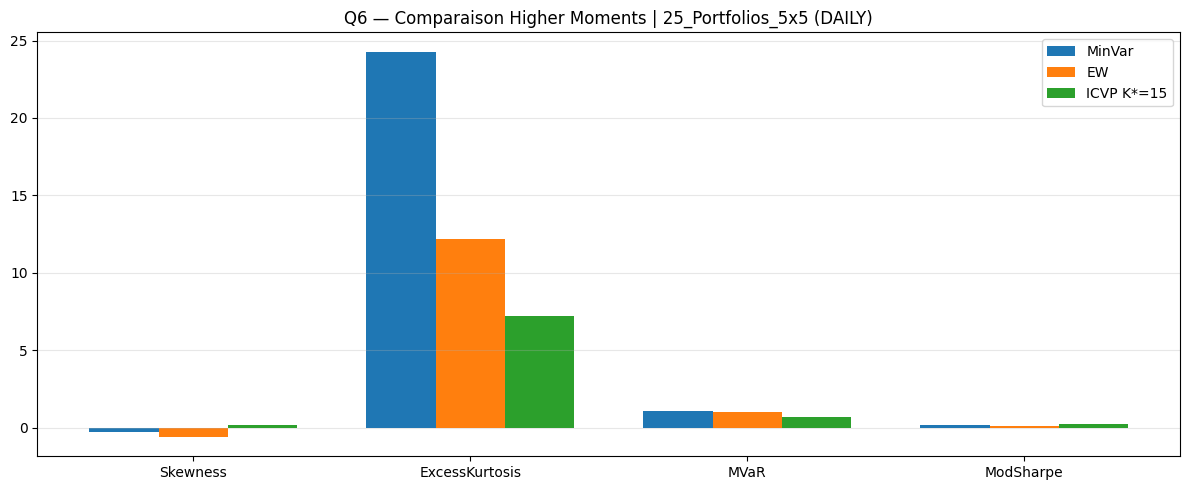

Figure sauvegardée : q6_comparison_25_Portfolios_5x5_daily.png

Q6 | 100_Portfolios_10x10 | MONTHLY | T=672, N=100
K_grid = [1, 2, 3, 5, 8, 10, 15]
  [1/3] MinVar...
  [2/3] EW...
  [3/3] ICVP FastICA...
    K=1   | Mean=0.1345 | Vol=0.1843 | Sharpe=0.7296 | Skew=-0.6991 | Ex.Kurt=2.5885 | MVaR=0.5624 | FailRate=0.00%
    K=2   | Mean=0.1531 | Vol=0.1963 | Sharpe=0.7800 | Skew=-0.4682 | Ex.Kurt=5.2056 | MVaR=0.7029 | FailRate=0.00%
    K=3   | Mean=0.1335 | Vol=0.1772 | Sharpe=0.7532 | Skew=-0.8064 | Ex.Kurt=3.6527 | MVaR=0.5867 | FailRate=0.00%
    K=5   | Mean=0.1579 | Vol=0.1814 | Sharpe=0.8709 | Skew=-0.3838 | Ex.Kurt=2.0165 | MVaR=0.5029 | FailRate=0.00%
    K=8   | Mean=0.1496 | Vol=0.1768 | Sharpe=0.8464 | Skew=-0.2672 | Ex.Kurt=3.3380 | MVaR=0.5359 | FailRate=0.00%
    K=10  | Mean=0.1358 | Vol=0.1682 | Sharpe=0.8078 | Skew=-0.5409 | Ex.Kurt=2.2330 | MVaR=0.4882 | FailRate=0.00%
    K=15  | Mean=0.1345 | Vol=0.1780 | Sharpe=0.7554 | Skew=-0.3608 | Ex.Kurt=4.9397 | MVaR=0.6195 |

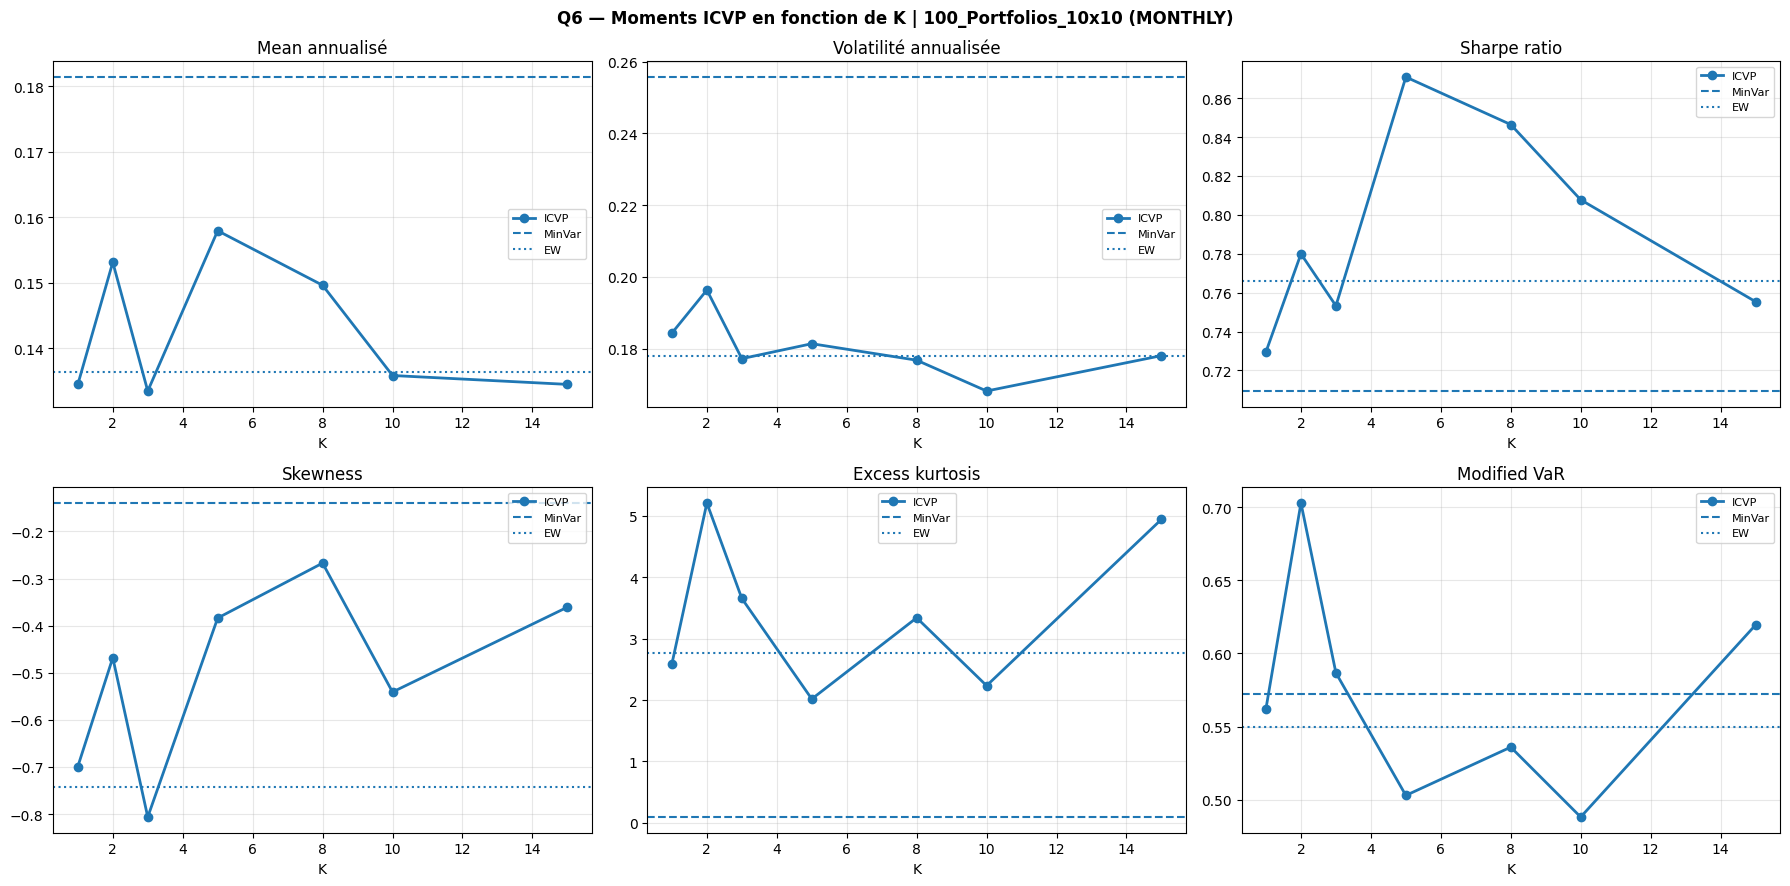

Figure sauvegardée : q6_moments_100_Portfolios_10x10_monthly.png


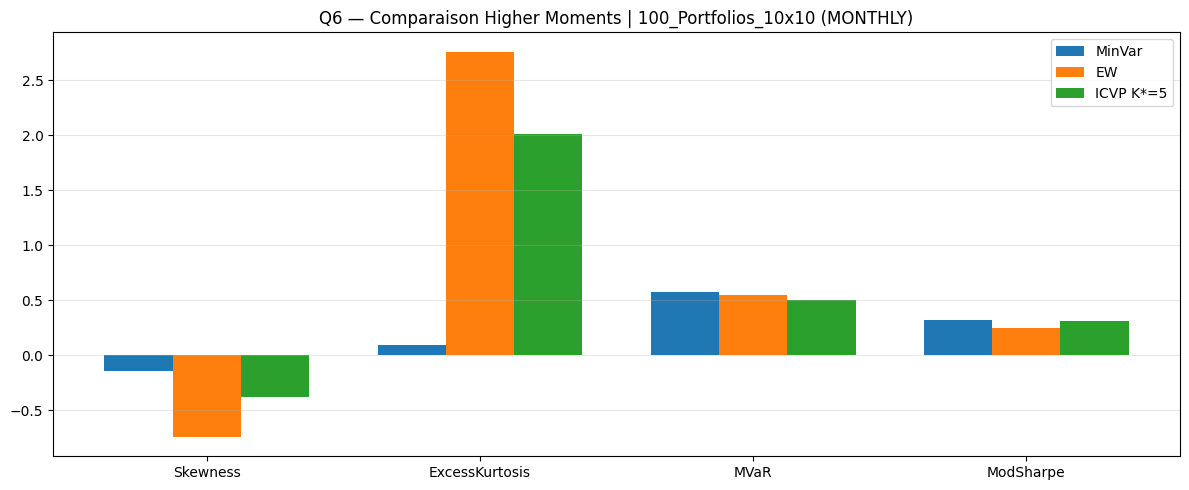

Figure sauvegardée : q6_comparison_100_Portfolios_10x10_monthly.png

Q6 | 100_Portfolios_10x10 | DAILY | T=14121, N=100
K_grid = [1, 2, 3, 5, 8, 10, 15, 20]
  [1/3] MinVar...
  [2/3] EW...
  [3/3] ICVP FastICA...
    K=1   | Mean=0.1351 | Vol=0.1870 | Sharpe=0.7225 | Skew=-0.5748 | Ex.Kurt=11.6783 | MVaR=0.9930 | FailRate=0.00%
    K=2   | Mean=0.1418 | Vol=0.1978 | Sharpe=0.7171 | Skew=-0.4026 | Ex.Kurt=15.4590 | MVaR=1.2124 | FailRate=0.00%
    K=3   | Mean=0.1636 | Vol=0.1940 | Sharpe=0.8435 | Skew=-0.1900 | Ex.Kurt=12.0779 | MVaR=1.0131 | FailRate=0.00%
    K=5   | Mean=0.1372 | Vol=0.1980 | Sharpe=0.6926 | Skew=-0.1338 | Ex.Kurt=12.6009 | MVaR=1.0537 | FailRate=0.00%
    K=8   | Mean=0.1713 | Vol=0.2100 | Sharpe=0.8157 | Skew=-0.3737 | Ex.Kurt=15.7832 | MVaR=1.2991 | FailRate=0.00%
    K=10  | Mean=0.1540 | Vol=0.1959 | Sharpe=0.7861 | Skew=-0.2297 | Ex.Kurt=12.5788 | MVaR=1.0511 | FailRate=0.00%
    K=15  | Mean=0.1284 | Vol=0.1744 | Sharpe=0.7365 | Skew=-0.3621 | Ex.Kurt=9.2936 

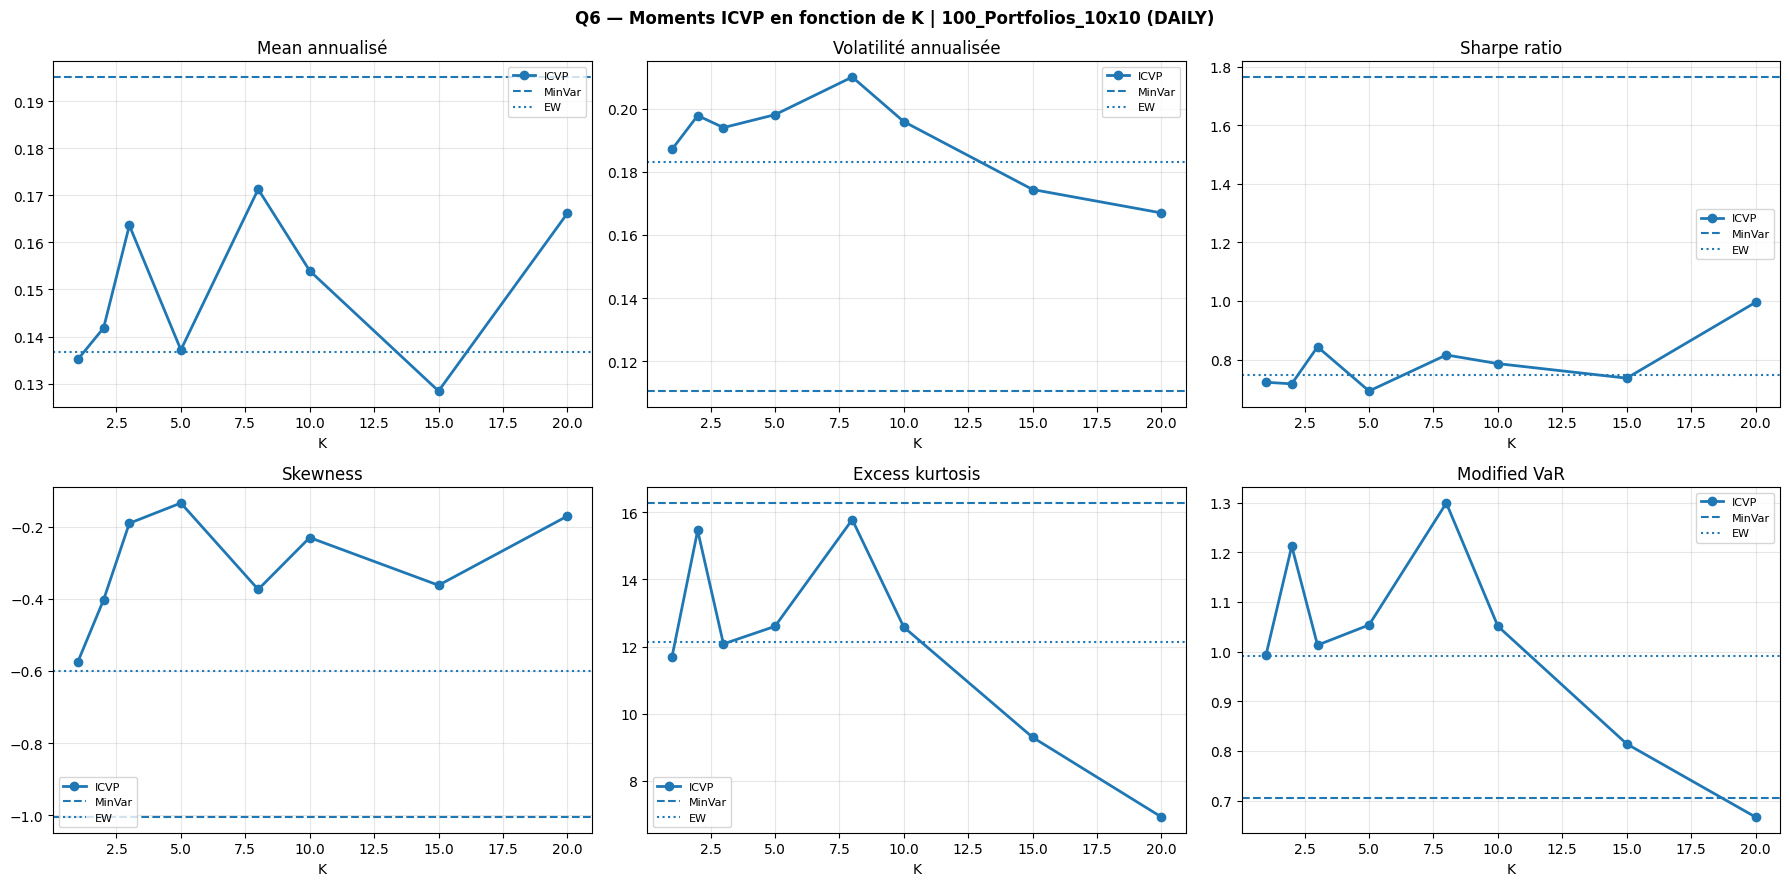

Figure sauvegardée : q6_moments_100_Portfolios_10x10_daily.png


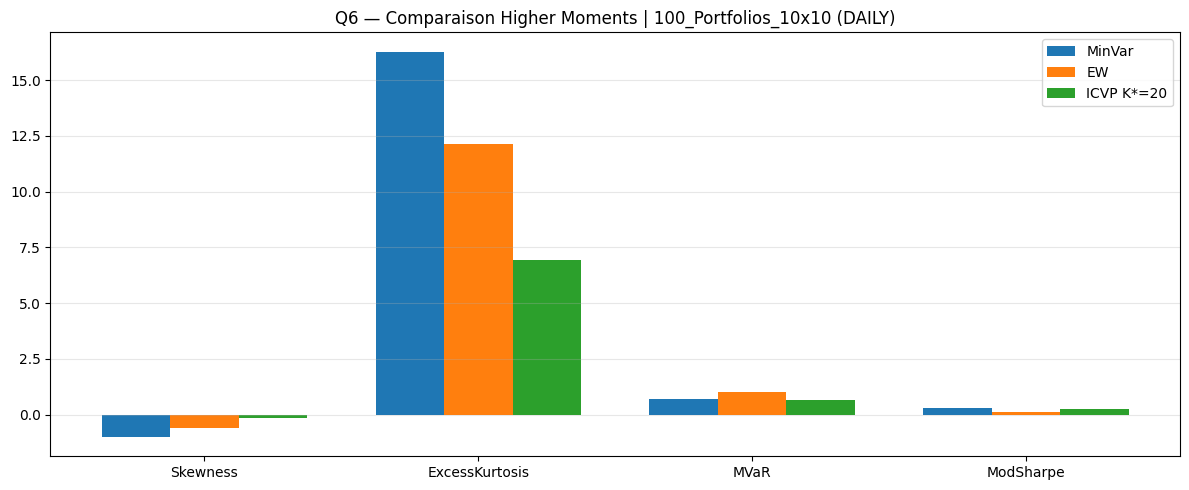

Figure sauvegardée : q6_comparison_100_Portfolios_10x10_daily.png

Q6 | 10_Industry_Portfolios | MONTHLY | T=672, N=10
K_grid = [1, 2, 3, 5, 8, 10]
  [1/3] MinVar...
  [2/3] EW...
  [3/3] ICVP FastICA...
    K=1   | Mean=0.1337 | Vol=0.1611 | Sharpe=0.8304 | Skew=-0.4634 | Ex.Kurt=2.4129 | MVaR=0.4688 | FailRate=0.00%
    K=2   | Mean=0.1355 | Vol=0.1738 | Sharpe=0.7798 | Skew=0.0881 | Ex.Kurt=3.4156 | MVaR=0.4921 | FailRate=0.00%
    K=3   | Mean=0.1281 | Vol=0.1566 | Sharpe=0.8177 | Skew=-0.4323 | Ex.Kurt=1.2613 | MVaR=0.4124 | FailRate=0.00%
    K=5   | Mean=0.1229 | Vol=0.1546 | Sharpe=0.7948 | Skew=-0.0991 | Ex.Kurt=1.3625 | MVaR=0.3842 | FailRate=0.00%
    K=8   | Mean=0.1085 | Vol=0.1487 | Sharpe=0.7292 | Skew=-0.1564 | Ex.Kurt=0.2067 | MVaR=0.3377 | FailRate=0.00%
    K=10  | Mean=0.1157 | Vol=0.1526 | Sharpe=0.7579 | Skew=-0.1498 | Ex.Kurt=0.2883 | MVaR=0.3474 | FailRate=0.00%

Q6 — ICVP FastICA | 10_Industry_Portfolios | MONTHLY
Strategy              Mean       Vol    Sharpe 

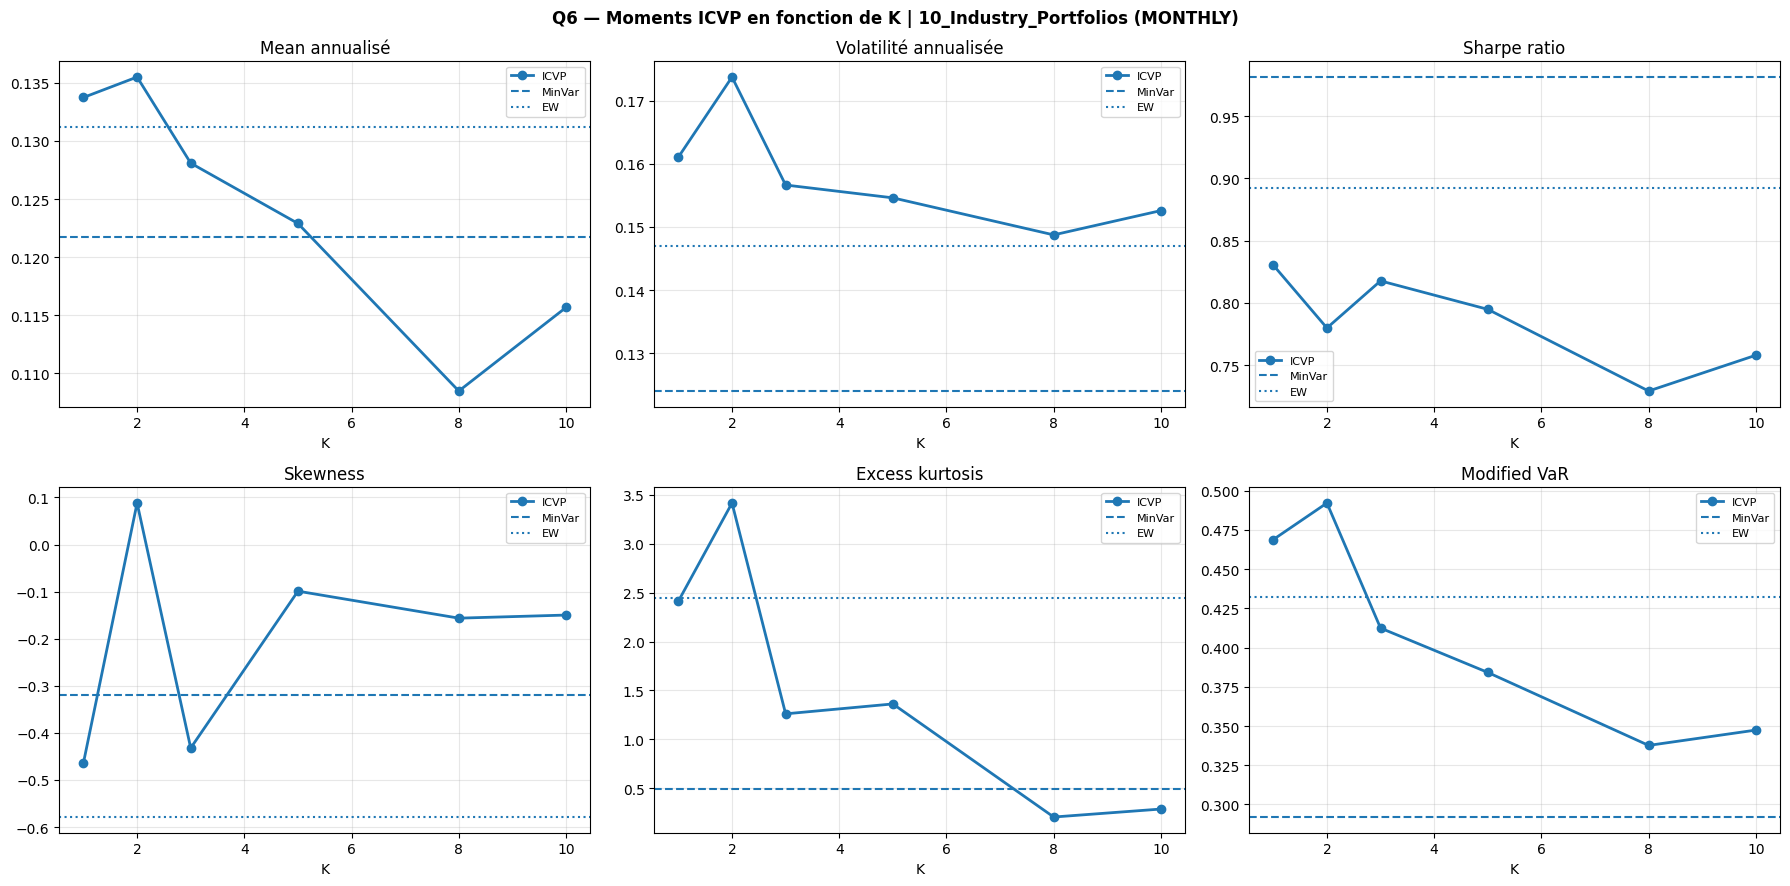

Figure sauvegardée : q6_moments_10_Industry_Portfolios_monthly.png


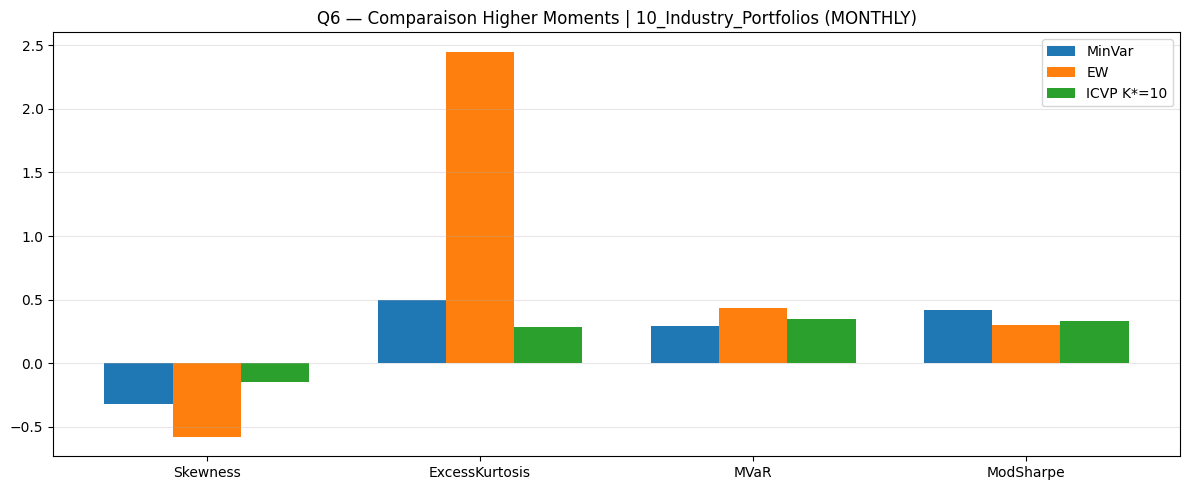

Figure sauvegardée : q6_comparison_10_Industry_Portfolios_monthly.png

Q6 | 10_Industry_Portfolios | DAILY | T=14121, N=10
K_grid = [1, 2, 3, 5, 8, 10]
  [1/3] MinVar...
  [2/3] EW...
  [3/3] ICVP FastICA...
    K=1   | Mean=0.1336 | Vol=0.1744 | Sharpe=0.7656 | Skew=-0.5939 | Ex.Kurt=16.1108 | MVaR=1.1075 | FailRate=0.00%
    K=2   | Mean=0.1463 | Vol=0.2082 | Sharpe=0.7027 | Skew=-0.1266 | Ex.Kurt=9.9797 | MVaR=0.9791 | FailRate=0.00%
    K=3   | Mean=0.1256 | Vol=0.2109 | Sharpe=0.5957 | Skew=-0.3149 | Ex.Kurt=10.6910 | MVaR=1.0507 | FailRate=0.00%
    K=5   | Mean=0.1262 | Vol=0.2120 | Sharpe=0.5953 | Skew=0.0423 | Ex.Kurt=10.8459 | MVaR=1.0162 | FailRate=0.00%
    K=8   | Mean=0.1070 | Vol=0.1963 | Sharpe=0.5448 | Skew=-0.1434 | Ex.Kurt=14.3966 | MVaR=1.1300 | FailRate=0.00%
    K=10  | Mean=0.1088 | Vol=0.1980 | Sharpe=0.5493 | Skew=-0.5831 | Ex.Kurt=16.5253 | MVaR=1.2783 | FailRate=0.00%

Q6 — ICVP FastICA | 10_Industry_Portfolios | DAILY
Strategy              Mean       Vol    

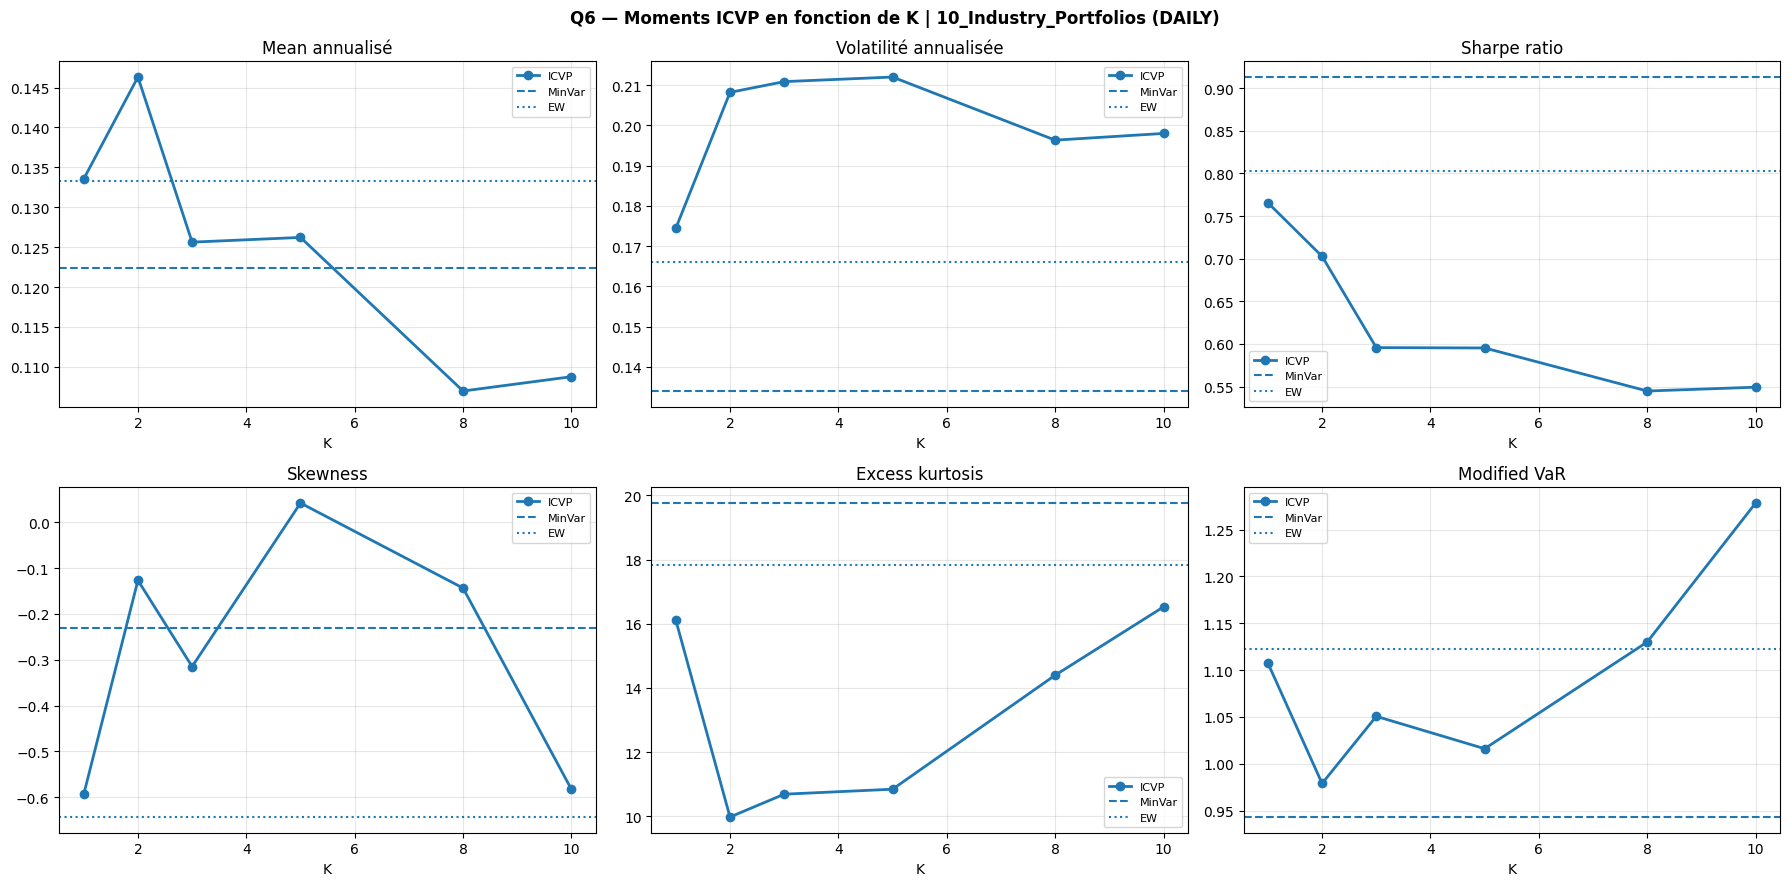

Figure sauvegardée : q6_moments_10_Industry_Portfolios_daily.png


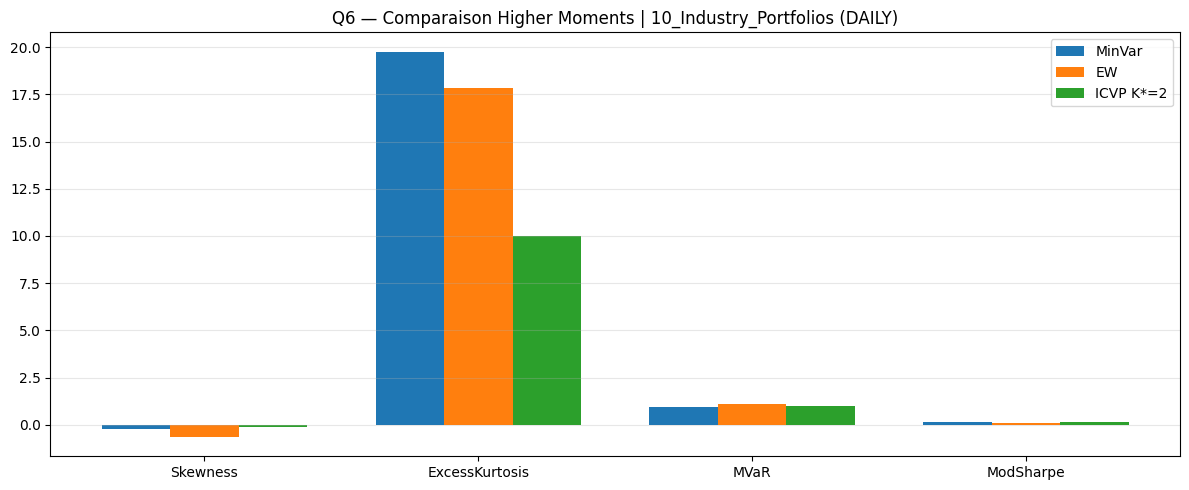

Figure sauvegardée : q6_comparison_10_Industry_Portfolios_daily.png

Q6 | 48_Industry_Portfolios | MONTHLY | T=672, N=48
K_grid = [1, 2, 3, 5, 8, 10, 15]
  [1/3] MinVar...
  [2/3] EW...
  [3/3] ICVP FastICA...
    K=1   | Mean=0.1316 | Vol=0.1755 | Sharpe=0.7497 | Skew=-0.6342 | Ex.Kurt=3.1132 | MVaR=0.5533 | FailRate=0.00%
    K=2   | Mean=0.1130 | Vol=0.2006 | Sharpe=0.5635 | Skew=-0.3488 | Ex.Kurt=1.2471 | MVaR=0.5347 | FailRate=0.00%
    K=3   | Mean=0.0964 | Vol=0.1998 | Sharpe=0.4824 | Skew=-0.2037 | Ex.Kurt=1.6159 | MVaR=0.5392 | FailRate=0.00%
    K=5   | Mean=0.1414 | Vol=0.1755 | Sharpe=0.8055 | Skew=-0.5343 | Ex.Kurt=2.7850 | MVaR=0.5319 | FailRate=0.00%
    K=8   | Mean=0.1338 | Vol=0.1640 | Sharpe=0.8161 | Skew=-0.4964 | Ex.Kurt=1.9030 | MVaR=0.4605 | FailRate=0.00%
    K=10  | Mean=0.1460 | Vol=0.1713 | Sharpe=0.8524 | Skew=-0.1426 | Ex.Kurt=1.1773 | MVaR=0.4202 | FailRate=0.00%
    K=15  | Mean=0.1587 | Vol=0.1606 | Sharpe=0.9887 | Skew=-0.0769 | Ex.Kurt=1.5295 | MVaR=0.

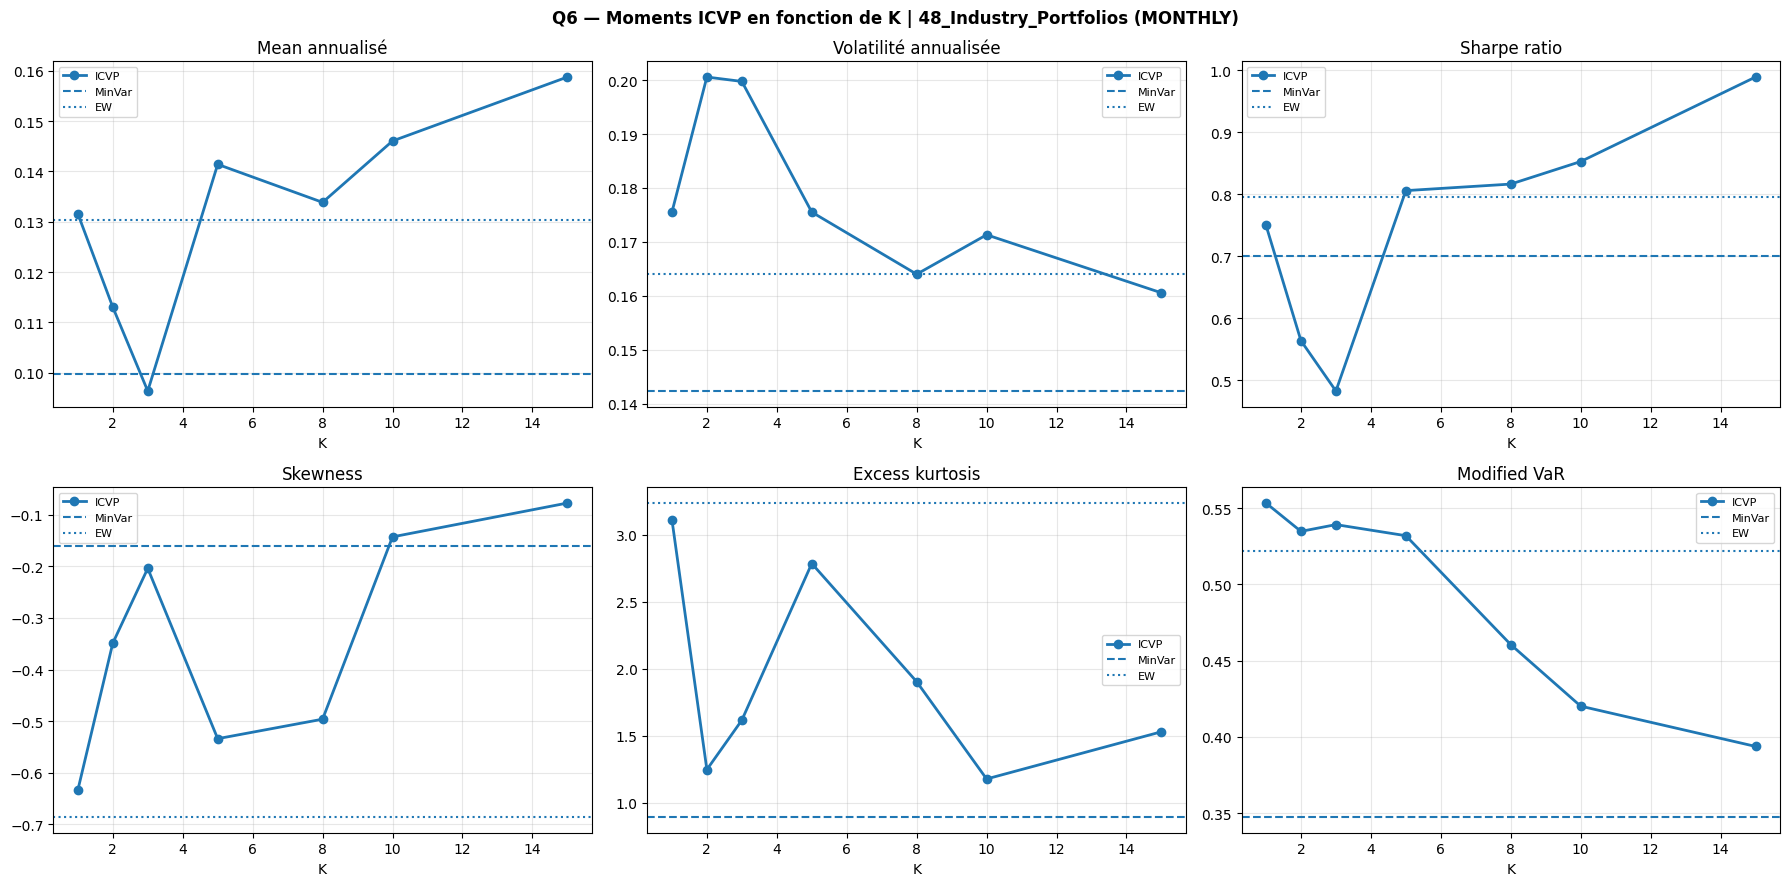

Figure sauvegardée : q6_moments_48_Industry_Portfolios_monthly.png


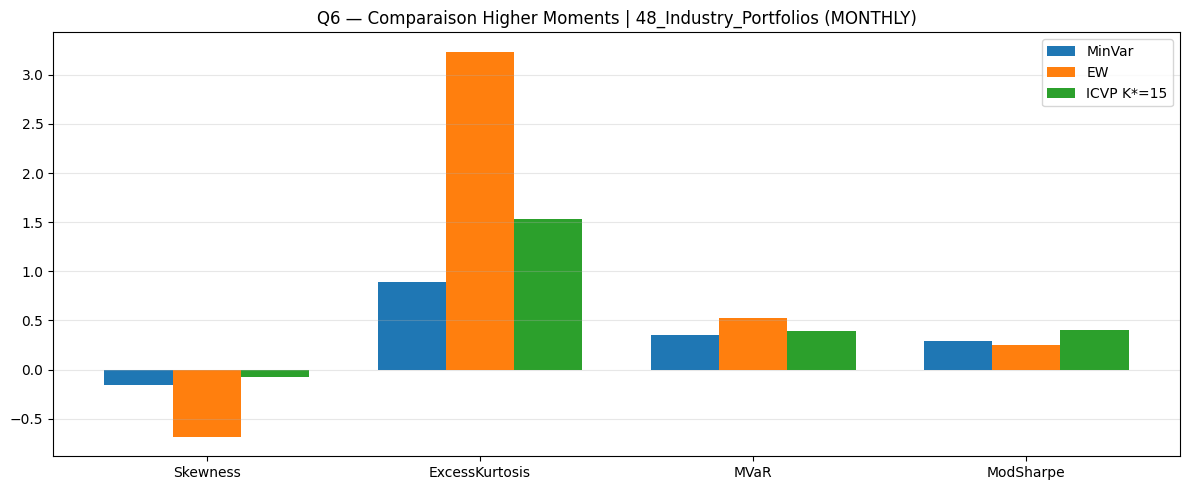

Figure sauvegardée : q6_comparison_48_Industry_Portfolios_monthly.png

Q6 | 48_Industry_Portfolios | DAILY | T=14121, N=48
K_grid = [1, 2, 3, 5, 8, 10, 15, 20]
  [1/3] MinVar...
  [2/3] EW...
  [3/3] ICVP FastICA...
    K=1   | Mean=0.1318 | Vol=0.1831 | Sharpe=0.7199 | Skew=-0.5816 | Ex.Kurt=13.8137 | MVaR=1.0642 | FailRate=0.00%
    K=2   | Mean=0.1468 | Vol=0.2005 | Sharpe=0.7323 | Skew=-0.5580 | Ex.Kurt=13.1599 | MVaR=1.1326 | FailRate=0.00%
    K=3   | Mean=0.0962 | Vol=0.1930 | Sharpe=0.4983 | Skew=-0.4304 | Ex.Kurt=10.6305 | MVaR=0.9704 | FailRate=0.00%
    K=5   | Mean=0.1303 | Vol=0.1941 | Sharpe=0.6710 | Skew=-0.3274 | Ex.Kurt=8.2446 | MVaR=0.8566 | FailRate=0.00%
    K=8   | Mean=0.1443 | Vol=0.1947 | Sharpe=0.7415 | Skew=-0.1956 | Ex.Kurt=7.3467 | MVaR=0.8033 | FailRate=0.00%
    K=10  | Mean=0.1285 | Vol=0.1928 | Sharpe=0.6665 | Skew=-0.0840 | Ex.Kurt=6.7272 | MVaR=0.7550 | FailRate=0.00%
    K=15  | Mean=0.1287 | Vol=0.1751 | Sharpe=0.7350 | Skew=-0.1576 | Ex.Kurt=5.2392 

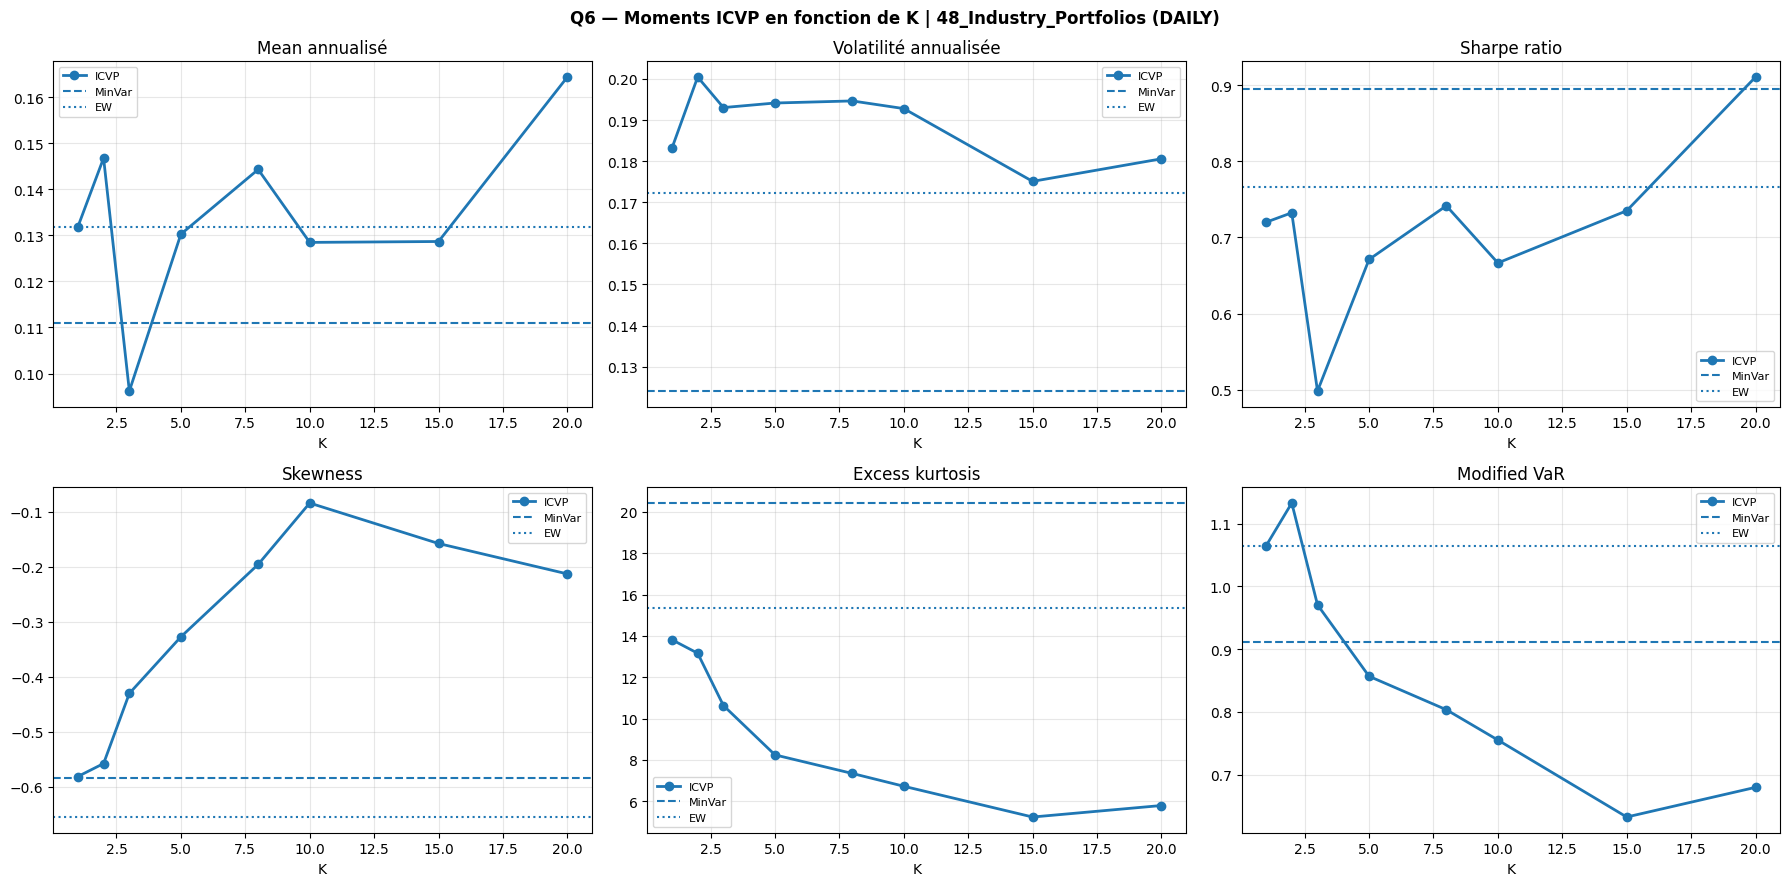

Figure sauvegardée : q6_moments_48_Industry_Portfolios_daily.png


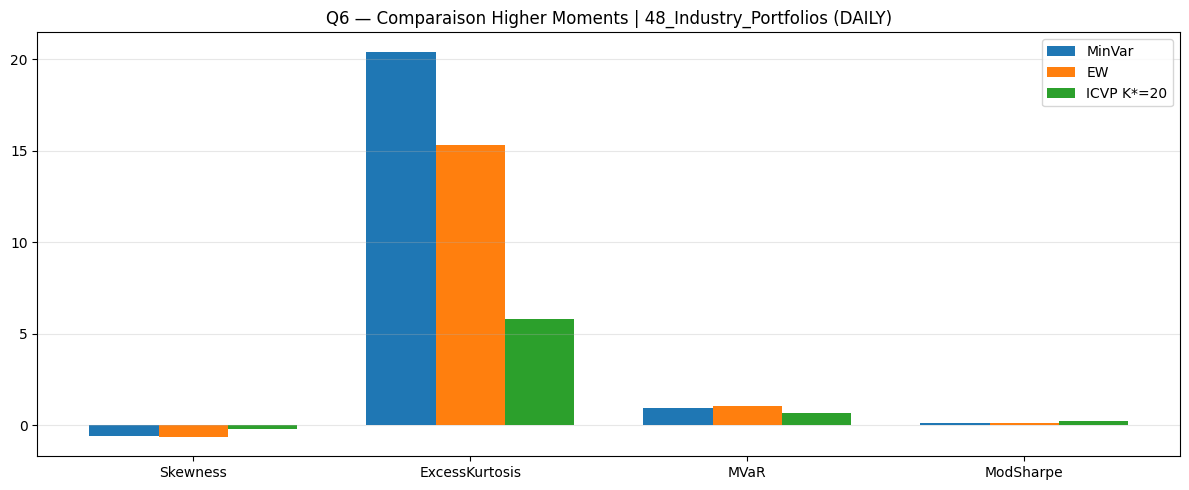

Figure sauvegardée : q6_comparison_48_Industry_Portfolios_daily.png


In [ ]:
from scipy import stats
from sklearn.decomposition import FastICA
import warnings

warnings.filterwarnings("ignore")

def infer_freq(key):
    return "monthly" if key.endswith("_monthly") else "daily"


def get_window_params(freq):
    if freq == "monthly":
        return 120, 6          # 10 ans / 6 mois
    else:
        return 2520, 126       # 10 ans / 6 mois daily


def annualize(mean_ret, vol_ret, freq):
    f = 12 if freq == "monthly" else 252
    ann_mean = mean_ret * f
    ann_vol = vol_ret * np.sqrt(f)
    ann_sr = ann_mean / ann_vol if ann_vol > 1e-10 else np.nan
    return ann_mean, ann_vol, ann_sr


def compute_turnover(weights_list):
    valid = [
        w for w in weights_list
        if w is not None and np.all(np.isfinite(w))
    ]

    if len(valid) < 2:
        return np.nan

    return np.mean([
        np.sum(np.abs(valid[t] - valid[t - 1]))
        for t in range(1, len(valid))
    ])


# ============================================================
# 1. MOMENTS ET MODIFIED VAR
# ============================================================

def compute_moments(port_returns, freq, alpha=0.01):

    r = np.asarray(port_returns, dtype=float)
    valid = np.isfinite(r)

    if valid.sum() < 10:
        return {
            "Mean": np.nan,
            "Vol": np.nan,
            "Sharpe": np.nan,
            "Skewness": np.nan,
            "ExcessKurtosis": np.nan,
            "MVaR": np.nan,
            "ModSharpe": np.nan,
            "FailRate": 1.0
        }

    r = r[valid]

    mu_p = np.mean(r)
    sig_p = np.std(r, ddof=1)

    skew = stats.skew(r, bias=False)
    ex_kurt = stats.kurtosis(r, fisher=True, bias=False)

    ann_mean, ann_vol, ann_sr = annualize(mu_p, sig_p, freq)

    z = stats.norm.ppf(alpha)

    z_cf = (
        z
        + ((z**2 - 1) * skew) / 6
        + ((z**3 - 3*z) * ex_kurt) / 24
        - ((2*z**3 - 5*z) * skew**2) / 36
    )

    var_mod_periodic = -(mu_p + sig_p * z_cf)

    f = 12 if freq == "monthly" else 252
    mvar_ann = var_mod_periodic * np.sqrt(f)

    mod_sharpe = ann_mean / abs(mvar_ann) if abs(mvar_ann) > 1e-10 else np.nan

    return {
        "Mean": ann_mean,
        "Vol": ann_vol,
        "Sharpe": ann_sr,
        "Skewness": skew,
        "ExcessKurtosis": ex_kurt,
        "MVaR": mvar_ann,
        "ModSharpe": mod_sharpe,
        "FailRate": 1 - valid.sum() / len(port_returns)
    }


# ============================================================
# 2. MINIMUM-VARIANCE BENCHMARK
# ============================================================

def compute_minvar(returns, tol=1e-10):
    Sigma = returns.cov().values
    Sigma = (Sigma + Sigma.T) / 2

    N = Sigma.shape[0]
    ones = np.ones(N)

    try:
        w = np.linalg.solve(Sigma, ones)
    except np.linalg.LinAlgError:
        return np.full(N, np.nan)

    denom = ones @ w

    if abs(denom) < tol:
        return np.full(N, np.nan)

    return w / denom


def compute_ew(N):
    return np.ones(N) / N


# ============================================================
# 3. PCA + FASTICA SELON LE COURS
# ============================================================

def run_fastICA_course(returns, K, random_state=42):

    X_raw = returns.values
    T_obs, N = X_raw.shape

    K = int(np.clip(K, 1, min(N, T_obs - 2)))

    X = X_raw - X_raw.mean(axis=0, keepdims=True)

    Sigma = np.cov(X.T)
    Sigma = (Sigma + Sigma.T) / 2

    eigvals, eigvecs = np.linalg.eigh(Sigma)
    idx = np.argsort(eigvals)[::-1]

    eigvals = np.maximum(eigvals[idx], 1e-12)
    eigvecs = eigvecs[:, idx]

    Vk = eigvecs[:, :K]
    Lk = eigvals[:K]

    # PCs standardisés : Var(Y*) = I_K
    Y_star = (np.diag(1.0 / np.sqrt(Lk)) @ Vk.T @ X.T).T

    ica = FastICA(
        n_components=K,
        fun="logcosh",
        algorithm="deflation",
        whiten=False,
        random_state=random_state,
        max_iter=2000,
        tol=1e-6
    )

    try:
        ica.fit(Y_star)
        R_perp = ica.components_

        row_norms = np.linalg.norm(R_perp, axis=1, keepdims=True)
        row_norms = np.where(row_norms < 1e-12, 1.0, row_norms)
        R_perp = R_perp / row_norms

    except Exception:
        return None, None, None, None, False

    T_mix = Vk @ np.diag(np.sqrt(Lk)) @ R_perp.T

    return Vk, Lk, R_perp, T_mix, True


# ============================================================
# 4. PORTEFEUILLE IC-VARIANCE-PARITY
# ============================================================

def compute_icvp_weights(Vk, Lk, R_perp, N, tol=1e-10):

    ones = np.ones(N)

    L_inv_sqrt = 1.0 / np.sqrt(Lk)

    inner = R_perp @ (L_inv_sqrt * (Vk.T @ ones))

    signs = np.sign(inner)
    signs[signs == 0] = 1.0

    w_num = Vk @ np.diag(L_inv_sqrt) @ R_perp.T @ signs

    denom = ones @ w_num

    if abs(denom) < tol or not np.isfinite(denom):
        return np.full(N, np.nan)

    w = w_num / denom

    if not np.all(np.isfinite(w)):
        return np.full(N, np.nan)

    return w


# ============================================================
# 5. OUT-OF-SAMPLE ICVP POUR K FIXÉ
# ============================================================

def compute_oos_icvp_fixed_K(returns, freq, K, random_state=42):
    window, roll_step = get_window_params(freq)

    T, N = returns.shape

    if T <= window:
        empty = {
            "Mean": np.nan,
            "Vol": np.nan,
            "Sharpe": np.nan,
            "Skewness": np.nan,
            "ExcessKurtosis": np.nan,
            "MVaR": np.nan,
            "ModSharpe": np.nan,
            "FailRate": 1.0
        }
        return empty, np.nan, []

    oos_returns = []
    weights = []

    t = window

    while t < T:
        step = min(roll_step, T - t)

        train = returns.iloc[t - window:t]
        test = returns.iloc[t:t + step]

        Vk, Lk, R_perp, T_mix, ok = run_fastICA_course(
            train,
            K,
            random_state=random_state
        )

        if not ok:
            w = np.full(N, np.nan)
        else:
            w = compute_icvp_weights(Vk, Lk, R_perp, N)

        weights.append(w)

        if np.any(~np.isfinite(w)):
            oos_returns.extend([np.nan] * step)
        else:
            oos_returns.extend(test.values @ w)

        t += step

    moments = compute_moments(oos_returns, freq)
    turnover = compute_turnover(weights)

    return moments, turnover, weights


# ============================================================
# 6. OUT-OF-SAMPLE MINVAR ET EW
# ============================================================

def compute_oos_minvar(returns, freq):
    window, roll_step = get_window_params(freq)

    T, N = returns.shape

    oos_returns = []
    weights = []

    t = window

    while t < T:
        step = min(roll_step, T - t)

        train = returns.iloc[t - window:t]
        test = returns.iloc[t:t + step]

        w = compute_minvar(train)
        weights.append(w)

        if np.any(~np.isfinite(w)):
            oos_returns.extend([np.nan] * step)
        else:
            oos_returns.extend(test.values @ w)

        t += step

    moments = compute_moments(oos_returns, freq)
    turnover = compute_turnover(weights)

    return moments, turnover, weights


def compute_oos_ew(returns, freq):
    window, roll_step = get_window_params(freq)

    T, N = returns.shape

    w = compute_ew(N)
    oos_returns = []

    t = window

    while t < T:
        step = min(roll_step, T - t)
        test = returns.iloc[t:t + step]

        oos_returns.extend(test.values @ w)

        t += step

    moments = compute_moments(oos_returns, freq)

    return moments, 0.0, [w]


# ============================================================
# 7. GRILLE DE K
# ============================================================

def make_K_grid(N, freq):
    if freq == "monthly":
        max_K = min(N, 15)
    else:
        max_K = min(N, 20)

    candidates = [1, 2, 3, 5, 8, 10, 15, max_K]

    return sorted(set(k for k in candidates if 1 <= k <= max_K))


# ============================================================
# 8. QUESTION 6 POUR UN DATASET
# ============================================================

def run_q6_one_dataset(returns, freq, dataset_name, random_state=42):
    T, N = returns.shape
    K_grid = make_K_grid(N, freq)

    print(f"\n{'='*90}")
    print(f"Q6 | {dataset_name} | {freq.upper()} | T={T}, N={N}")
    print(f"K_grid = {K_grid}")
    print(f"{'='*90}")

    results = {
        "K_grid": K_grid,
        "icvp": {}
    }

    print("  [1/3] MinVar...")
    mom_mv, to_mv, w_mv = compute_oos_minvar(returns, freq)

    print("  [2/3] EW...")
    mom_ew, to_ew, w_ew = compute_oos_ew(returns, freq)

    results["minvar"] = {
        "moments": mom_mv,
        "turnover": to_mv,
        "weights": w_mv
    }

    results["ew"] = {
        "moments": mom_ew,
        "turnover": to_ew,
        "weights": w_ew
    }

    print("  [3/3] ICVP FastICA...")
    for K in K_grid:
        mom_K, to_K, w_K = compute_oos_icvp_fixed_K(
            returns,
            freq,
            K,
            random_state=random_state
        )

        results["icvp"][K] = {
            "moments": mom_K,
            "turnover": to_K,
            "weights": w_K
        }

        print(
            f"    K={K:<3} | "
            f"Mean={mom_K['Mean']:.4f} | "
            f"Vol={mom_K['Vol']:.4f} | "
            f"Sharpe={mom_K['Sharpe']:.4f} | "
            f"Skew={mom_K['Skewness']:.4f} | "
            f"Ex.Kurt={mom_K['ExcessKurtosis']:.4f} | "
            f"MVaR={mom_K['MVaR']:.4f} | "
            f"FailRate={100*mom_K['FailRate']:.2f}%"
        )

    print_results_q6(dataset_name, freq, results)
    plot_q6_moments(dataset_name, freq, results)
    plot_q6_comparison(dataset_name, freq, results)

    return results


# ============================================================
# 9. AFFICHAGE TABLE
# ============================================================

def print_results_q6(dataset_name, freq, results):
    print(f"\n{'='*115}")
    print(f"Q6 — ICVP FastICA | {dataset_name} | {freq.upper()}")
    print(f"{'='*115}")

    header = (
        f"{'Strategy':<16} "
        f"{'Mean':>9} {'Vol':>9} {'Sharpe':>9} "
        f"{'Skew':>9} {'Ex.Kurt':>10} {'MVaR':>10} "
        f"{'ModSR':>9} {'TO':>9} {'Fail':>9}"
    )

    print(header)
    print("-" * 115)

    def row(label, mom, to):
        print(
            f"{label:<16} "
            f"{mom['Mean']:>9.4f} "
            f"{mom['Vol']:>9.4f} "
            f"{mom['Sharpe']:>9.4f} "
            f"{mom['Skewness']:>9.4f} "
            f"{mom['ExcessKurtosis']:>10.4f} "
            f"{mom['MVaR']:>10.4f} "
            f"{mom['ModSharpe']:>9.4f} "
            f"{to:>9.4f} "
            f"{100*mom['FailRate']:>8.2f}%"
        )

    row("MinVar", results["minvar"]["moments"], results["minvar"]["turnover"])
    row("EW", results["ew"]["moments"], results["ew"]["turnover"])

    print("-" * 115)

    for K in results["K_grid"]:
        r = results["icvp"][K]
        row(f"ICVP K={K}", r["moments"], r["turnover"])


# ============================================================
# 10. GRAPHIQUES
# ============================================================

def plot_q6_moments(dataset_name, freq, results):
    K_grid = results["K_grid"]

    metrics = [
        "Mean",
        "Vol",
        "Sharpe",
        "Skewness",
        "ExcessKurtosis",
        "MVaR"
    ]

    titles = [
        "Mean annualisé",
        "Volatilité annualisée",
        "Sharpe ratio",
        "Skewness",
        "Excess kurtosis",
        "Modified VaR"
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    mom_mv = results["minvar"]["moments"]
    mom_ew = results["ew"]["moments"]

    for ax, metric, title in zip(axes.flat, metrics, titles):
        vals = [
            results["icvp"][K]["moments"][metric]
            for K in K_grid
        ]

        ax.plot(K_grid, vals, "o-", linewidth=2, label="ICVP")

        if np.isfinite(mom_mv[metric]):
            ax.axhline(
                mom_mv[metric],
                linestyle="--",
                linewidth=1.5,
                label="MinVar"
            )

        if np.isfinite(mom_ew[metric]):
            ax.axhline(
                mom_ew[metric],
                linestyle=":",
                linewidth=1.5,
                label="EW"
            )

        ax.set_title(title)
        ax.set_xlabel("K")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle(
        f"Q6 — Moments ICVP en fonction de K | {dataset_name} ({freq.upper()})",
        fontsize=12,
        fontweight="bold"
    )

    plt.tight_layout()

    fname = f"q6_moments_{dataset_name}_{freq}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Figure sauvegardée : {fname}")


def plot_q6_comparison(dataset_name, freq, results):

    K_grid = results["K_grid"]

    best_K = None
    best_score = -np.inf

    for K in K_grid:
        score = results["icvp"][K]["moments"]["ModSharpe"]

        if np.isfinite(score) and score > best_score:
            best_score = score
            best_K = K

    if best_K is None:
        best_K = K_grid[0]

    mom_mv = results["minvar"]["moments"]
    mom_ew = results["ew"]["moments"]
    mom_ic = results["icvp"][best_K]["moments"]

    labels = ["MinVar", "EW", f"ICVP K*={best_K}"]

    metrics = ["Skewness", "ExcessKurtosis", "MVaR", "ModSharpe"]

    values = {
        "MinVar": [mom_mv[m] for m in metrics],
        "EW": [mom_ew[m] for m in metrics],
        f"ICVP K*={best_K}": [mom_ic[m] for m in metrics]
    }

    x = np.arange(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))

    for i, label in enumerate(labels):
        ax.bar(x + (i - 1) * width, values[label], width, label=label)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_title(
        f"Q6 — Comparaison Higher Moments | {dataset_name} ({freq.upper()})"
    )
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()

    fname = f"q6_comparison_{dataset_name}_{freq}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Figure sauvegardée : {fname}")


# ============================================================
# 11. PIPELINE GLOBAL QUESTION 6
# ============================================================


def run_question6(all_data, random_state=42):
    all_results_q6 = {}

    print("\n" + "█" * 90)
    print("QUESTION 6 — IC Variance-Parity Portfolio avec FastICA")
    print("█" * 90)

    for key, returns in all_data.items():
        freq = infer_freq(key)
        dataset_name = key.replace("_monthly", "").replace("_daily", "")

        res = run_q6_one_dataset(
            returns=returns,
            freq=freq,
            dataset_name=dataset_name,
            random_state=random_state
        )

        all_results_q6[key] = res

    return all_results_q6


# ============================================================
# 12. LANCEMENT
# ============================================================

all_results_q6 = run_question6(all_data, random_state=42)

## **Question 7**


██████████████████████████████████████████████████████████████████████
  Q7 OSCAR | 25_Portfolios_5x5_monthly | T=672, N=25
██████████████████████████████████████████████████████████████████████
  [1/3] EW...
  [2/3] MinVar...
  [3/3] OSCAR rapide...
    OSCAR fenêtre   1 | alpha=0.020, c=1.860 | clusters=6
    OSCAR fenêtre   2 | alpha=0.020, c=1.860 | clusters=6
    OSCAR fenêtre   3 | alpha=0.020, c=1.860 | clusters=4
    OSCAR fenêtre  10 | alpha=0.020, c=1.860 | clusters=5
    OSCAR fenêtre  20 | alpha=0.020, c=1.860 | clusters=7
    OSCAR fenêtre  30 | alpha=0.020, c=1.860 | clusters=6
    OSCAR fenêtre  40 | alpha=0.020, c=1.860 | clusters=6
    OSCAR fenêtre  50 | alpha=0.020, c=1.860 | clusters=10
    OSCAR fenêtre  60 | alpha=0.020, c=1.860 | clusters=5
    OSCAR fenêtre  70 | alpha=0.020, c=1.860 | clusters=4
    OSCAR fenêtre  80 | alpha=0.020, c=1.860 | clusters=6
    OSCAR fenêtre  90 | alpha=0.020, c=1.860 | clusters=4

  Q7 — OSCAR | 25_Portfolios_5x5 | MONTHLY
  Strat

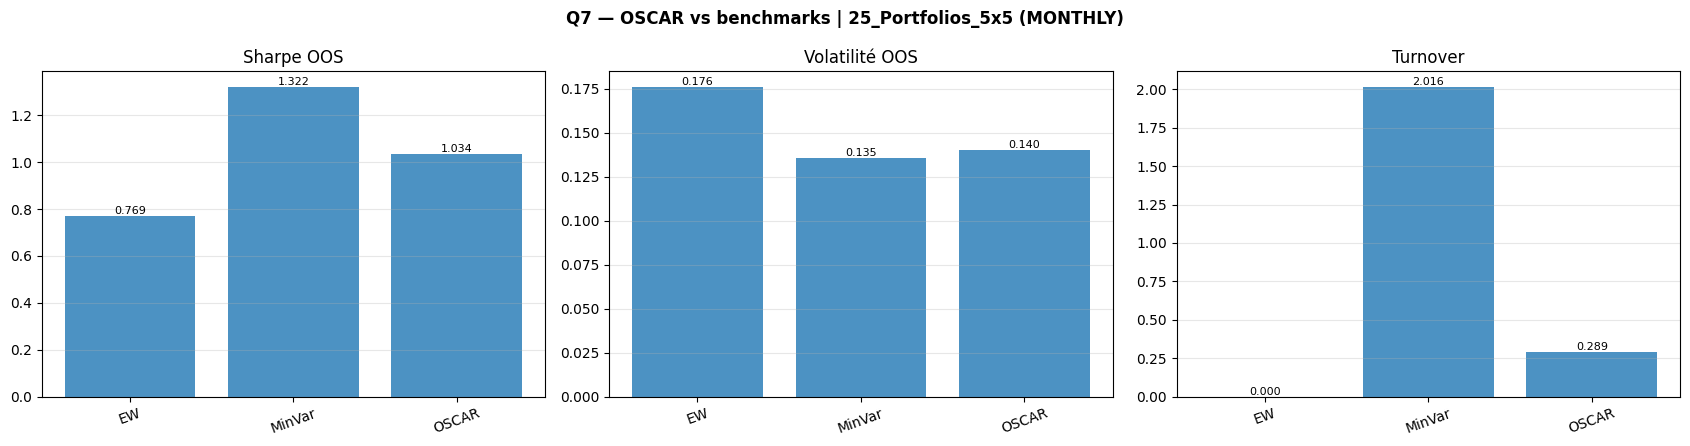

  Figure sauvegardée : q7_oscar_25_Portfolios_5x5_monthly.png

  Paramètres OSCAR : alpha=0.0200, c=1.8600
  Clusters moyens : 5.52

██████████████████████████████████████████████████████████████████████
  Q7 OSCAR | 25_Portfolios_5x5_daily | T=14121, N=25
██████████████████████████████████████████████████████████████████████
  [1/3] EW...
  [2/3] MinVar...
  [3/3] OSCAR rapide...
    OSCAR fenêtre   1 | alpha=0.020, c=1.860 | clusters=4
    OSCAR fenêtre   2 | alpha=0.020, c=1.860 | clusters=8
    OSCAR fenêtre   3 | alpha=0.020, c=1.860 | clusters=7
    OSCAR fenêtre  10 | alpha=0.020, c=1.860 | clusters=6
    OSCAR fenêtre  20 | alpha=0.020, c=1.860 | clusters=5
    OSCAR fenêtre  30 | alpha=0.020, c=1.860 | clusters=5
    OSCAR fenêtre  40 | alpha=0.020, c=1.860 | clusters=7
    OSCAR fenêtre  50 | alpha=0.020, c=1.860 | clusters=6
    OSCAR fenêtre  60 | alpha=0.020, c=1.860 | clusters=7
    OSCAR fenêtre  70 | alpha=0.020, c=1.860 | clusters=4
    OSCAR fenêtre  80 | alpha=0.020,

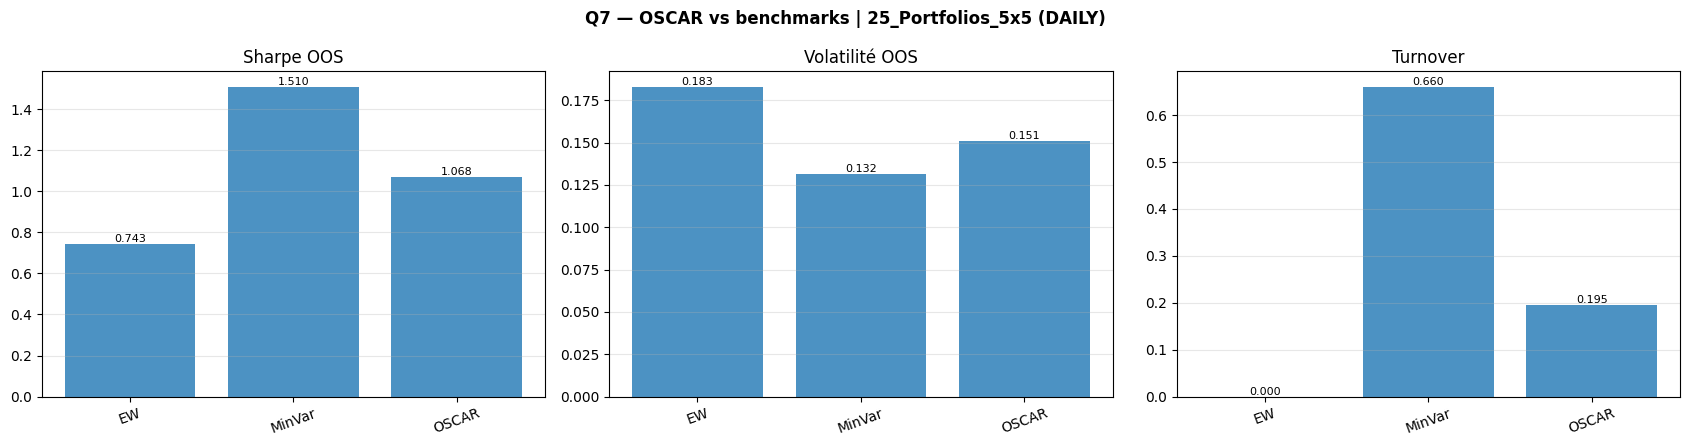

  Figure sauvegardée : q7_oscar_25_Portfolios_5x5_daily.png

  Paramètres OSCAR : alpha=0.0200, c=1.8600
  Clusters moyens : 6.04

██████████████████████████████████████████████████████████████████████
  Q7 OSCAR | 100_Portfolios_10x10_monthly | T=672, N=100
██████████████████████████████████████████████████████████████████████
  [1/3] EW...
  [2/3] MinVar...
  [3/3] OSCAR rapide...
    OSCAR fenêtre   1 | alpha=0.020, c=2.985 | clusters=5
    OSCAR fenêtre   2 | alpha=0.020, c=2.985 | clusters=7
    OSCAR fenêtre   3 | alpha=0.020, c=2.985 | clusters=8
    OSCAR fenêtre  10 | alpha=0.020, c=2.985 | clusters=8
    OSCAR fenêtre  20 | alpha=0.020, c=2.985 | clusters=8
    OSCAR fenêtre  30 | alpha=0.020, c=2.985 | clusters=11
    OSCAR fenêtre  40 | alpha=0.020, c=2.985 | clusters=7
    OSCAR fenêtre  50 | alpha=0.020, c=2.985 | clusters=10
    OSCAR fenêtre  60 | alpha=0.020, c=2.985 | clusters=6
    OSCAR fenêtre  70 | alpha=0.020, c=2.985 | clusters=6
    OSCAR fenêtre  80 | alpha=0.

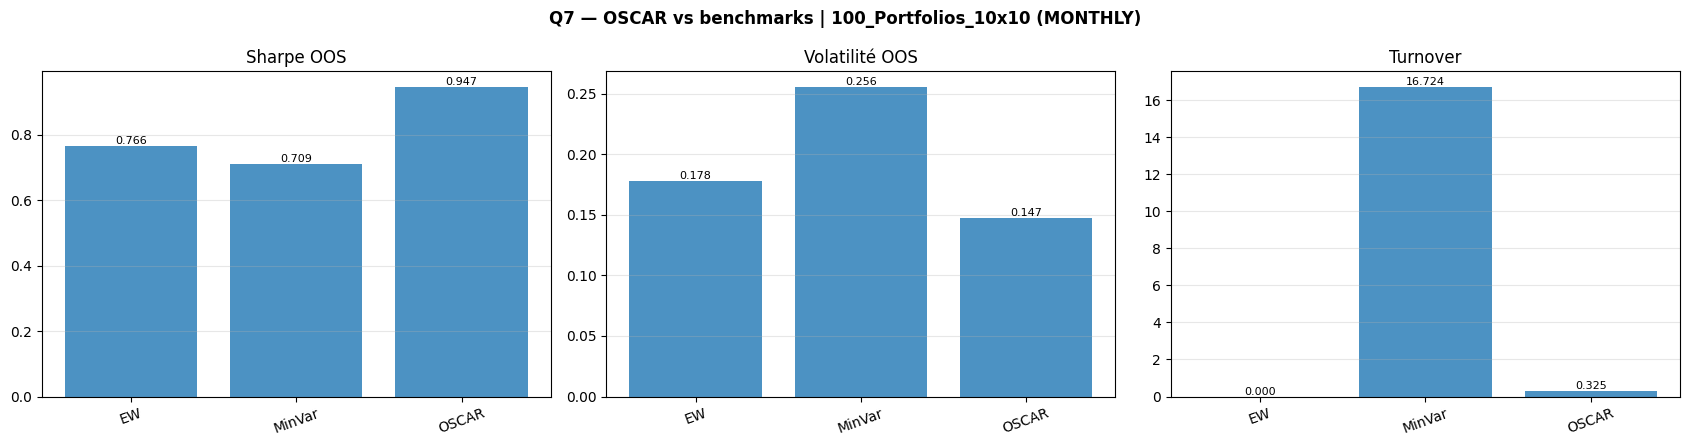

  Figure sauvegardée : q7_oscar_100_Portfolios_10x10_monthly.png

  Paramètres OSCAR : alpha=0.0200, c=2.9850
  Clusters moyens : 7.63

██████████████████████████████████████████████████████████████████████
  Q7 OSCAR | 100_Portfolios_10x10_daily | T=14121, N=100
██████████████████████████████████████████████████████████████████████
  [1/3] EW...
  [2/3] MinVar...
  [3/3] OSCAR rapide...
    OSCAR fenêtre   1 | alpha=0.020, c=2.985 | clusters=14
    OSCAR fenêtre   2 | alpha=0.020, c=2.985 | clusters=10
    OSCAR fenêtre   3 | alpha=0.020, c=2.985 | clusters=8
    OSCAR fenêtre  10 | alpha=0.020, c=2.985 | clusters=11
    OSCAR fenêtre  20 | alpha=0.020, c=2.985 | clusters=10
    OSCAR fenêtre  30 | alpha=0.020, c=2.985 | clusters=8
    OSCAR fenêtre  40 | alpha=0.020, c=2.985 | clusters=10
    OSCAR fenêtre  50 | alpha=0.020, c=2.985 | clusters=8
    OSCAR fenêtre  60 | alpha=0.020, c=2.985 | clusters=5
    OSCAR fenêtre  70 | alpha=0.020, c=2.985 | clusters=6
    OSCAR fenêtre  80 | 

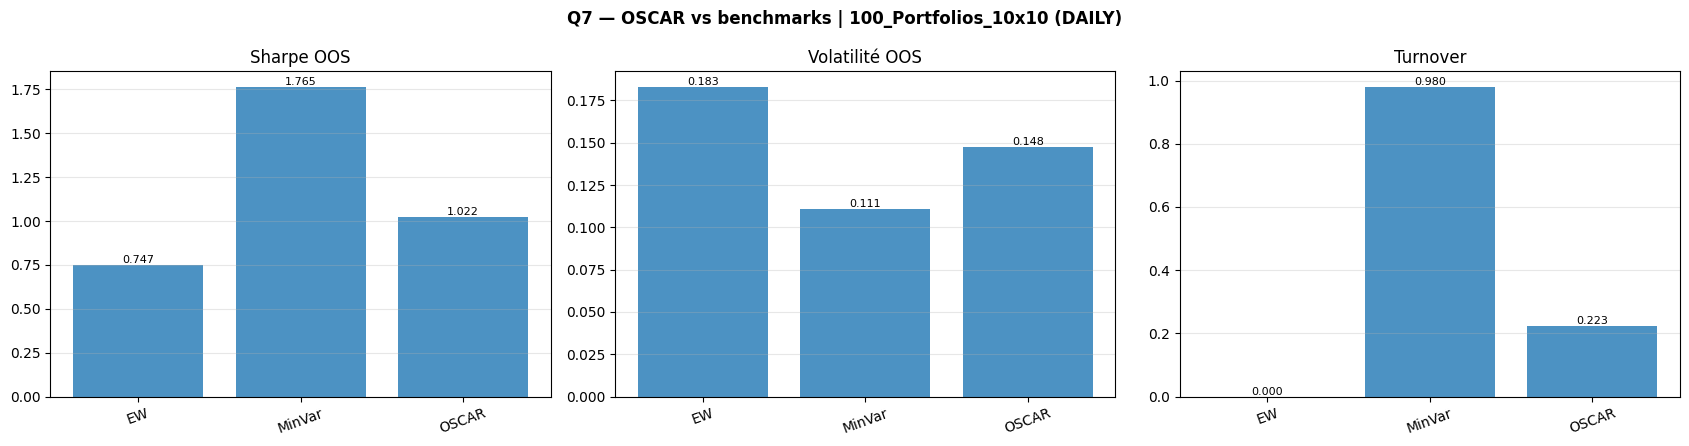

  Figure sauvegardée : q7_oscar_100_Portfolios_10x10_daily.png

  Paramètres OSCAR : alpha=0.0200, c=2.9850
  Clusters moyens : 8.59

██████████████████████████████████████████████████████████████████████
  Q7 OSCAR | 10_Industry_Portfolios_monthly | T=672, N=10
██████████████████████████████████████████████████████████████████████
  [1/3] EW...
  [2/3] MinVar...
  [3/3] OSCAR rapide...
    OSCAR fenêtre   1 | alpha=0.020, c=1.635 | clusters=6
    OSCAR fenêtre   2 | alpha=0.020, c=1.635 | clusters=6
    OSCAR fenêtre   3 | alpha=0.020, c=1.635 | clusters=6
    OSCAR fenêtre  10 | alpha=0.020, c=1.635 | clusters=6
    OSCAR fenêtre  20 | alpha=0.020, c=1.635 | clusters=8
    OSCAR fenêtre  30 | alpha=0.020, c=1.635 | clusters=6
    OSCAR fenêtre  40 | alpha=0.020, c=1.635 | clusters=8
    OSCAR fenêtre  50 | alpha=0.020, c=1.635 | clusters=8
    OSCAR fenêtre  60 | alpha=0.020, c=1.635 | clusters=7
    OSCAR fenêtre  70 | alpha=0.020, c=1.635 | clusters=6
    OSCAR fenêtre  80 | alpha=

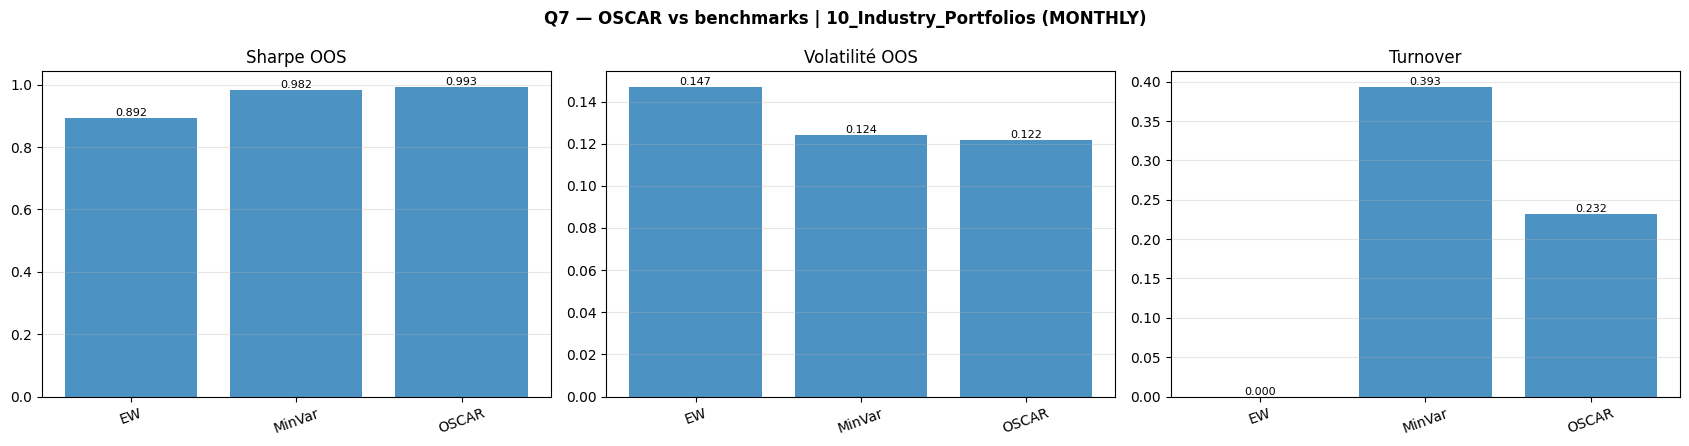

  Figure sauvegardée : q7_oscar_10_Industry_Portfolios_monthly.png

  Paramètres OSCAR : alpha=0.0200, c=1.6350
  Clusters moyens : 7.62

██████████████████████████████████████████████████████████████████████
  Q7 OSCAR | 10_Industry_Portfolios_daily | T=14121, N=10
██████████████████████████████████████████████████████████████████████
  [1/3] EW...
  [2/3] MinVar...
  [3/3] OSCAR rapide...
    OSCAR fenêtre   1 | alpha=0.020, c=1.635 | clusters=7
    OSCAR fenêtre   2 | alpha=0.020, c=1.635 | clusters=8
    OSCAR fenêtre   3 | alpha=0.020, c=1.635 | clusters=8
    OSCAR fenêtre  10 | alpha=0.020, c=1.635 | clusters=8
    OSCAR fenêtre  20 | alpha=0.020, c=1.635 | clusters=7
    OSCAR fenêtre  30 | alpha=0.020, c=1.635 | clusters=7
    OSCAR fenêtre  40 | alpha=0.020, c=1.635 | clusters=8
    OSCAR fenêtre  50 | alpha=0.020, c=1.635 | clusters=9
    OSCAR fenêtre  60 | alpha=0.020, c=1.635 | clusters=7
    OSCAR fenêtre  70 | alpha=0.020, c=1.635 | clusters=6
    OSCAR fenêtre  80 | al

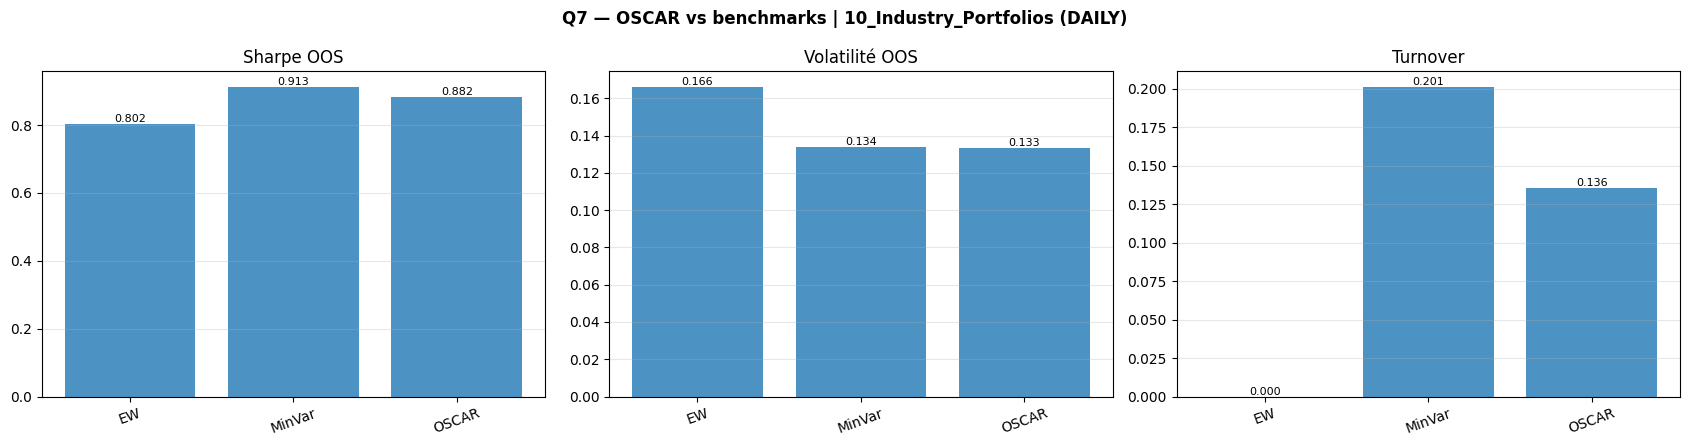

  Figure sauvegardée : q7_oscar_10_Industry_Portfolios_daily.png

  Paramètres OSCAR : alpha=0.0200, c=1.6350
  Clusters moyens : 7.82

██████████████████████████████████████████████████████████████████████
  Q7 OSCAR | 48_Industry_Portfolios_monthly | T=672, N=48
██████████████████████████████████████████████████████████████████████
  [1/3] EW...
  [2/3] MinVar...
  [3/3] OSCAR rapide...
    OSCAR fenêtre   1 | alpha=0.020, c=2.205 | clusters=8
    OSCAR fenêtre   2 | alpha=0.020, c=2.205 | clusters=10
    OSCAR fenêtre   3 | alpha=0.020, c=2.205 | clusters=10
    OSCAR fenêtre  10 | alpha=0.020, c=2.205 | clusters=9
    OSCAR fenêtre  20 | alpha=0.020, c=2.205 | clusters=9
    OSCAR fenêtre  30 | alpha=0.020, c=2.205 | clusters=8
    OSCAR fenêtre  40 | alpha=0.020, c=2.205 | clusters=11
    OSCAR fenêtre  50 | alpha=0.020, c=2.205 | clusters=13
    OSCAR fenêtre  60 | alpha=0.020, c=2.205 | clusters=16
    OSCAR fenêtre  70 | alpha=0.020, c=2.205 | clusters=11
    OSCAR fenêtre  80 

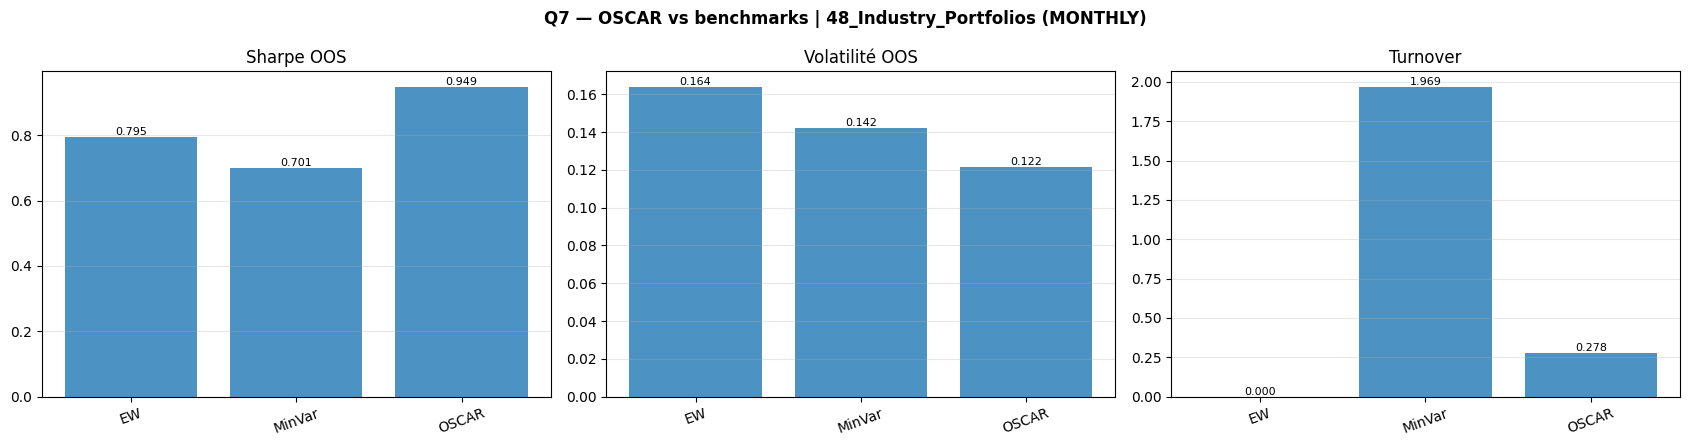

  Figure sauvegardée : q7_oscar_48_Industry_Portfolios_monthly.png

  Paramètres OSCAR : alpha=0.0200, c=2.2050
  Clusters moyens : 11.17

██████████████████████████████████████████████████████████████████████
  Q7 OSCAR | 48_Industry_Portfolios_daily | T=14121, N=48
██████████████████████████████████████████████████████████████████████
  [1/3] EW...
  [2/3] MinVar...
  [3/3] OSCAR rapide...
    OSCAR fenêtre   1 | alpha=0.020, c=2.205 | clusters=8
    OSCAR fenêtre   2 | alpha=0.020, c=2.205 | clusters=9
    OSCAR fenêtre   3 | alpha=0.020, c=2.205 | clusters=10
    OSCAR fenêtre  10 | alpha=0.020, c=2.205 | clusters=9
    OSCAR fenêtre  20 | alpha=0.020, c=2.205 | clusters=6
    OSCAR fenêtre  30 | alpha=0.020, c=2.205 | clusters=11
    OSCAR fenêtre  40 | alpha=0.020, c=2.205 | clusters=16
    OSCAR fenêtre  50 | alpha=0.020, c=2.205 | clusters=17
    OSCAR fenêtre  60 | alpha=0.020, c=2.205 | clusters=18
    OSCAR fenêtre  70 | alpha=0.020, c=2.205 | clusters=10
    OSCAR fenêtre  

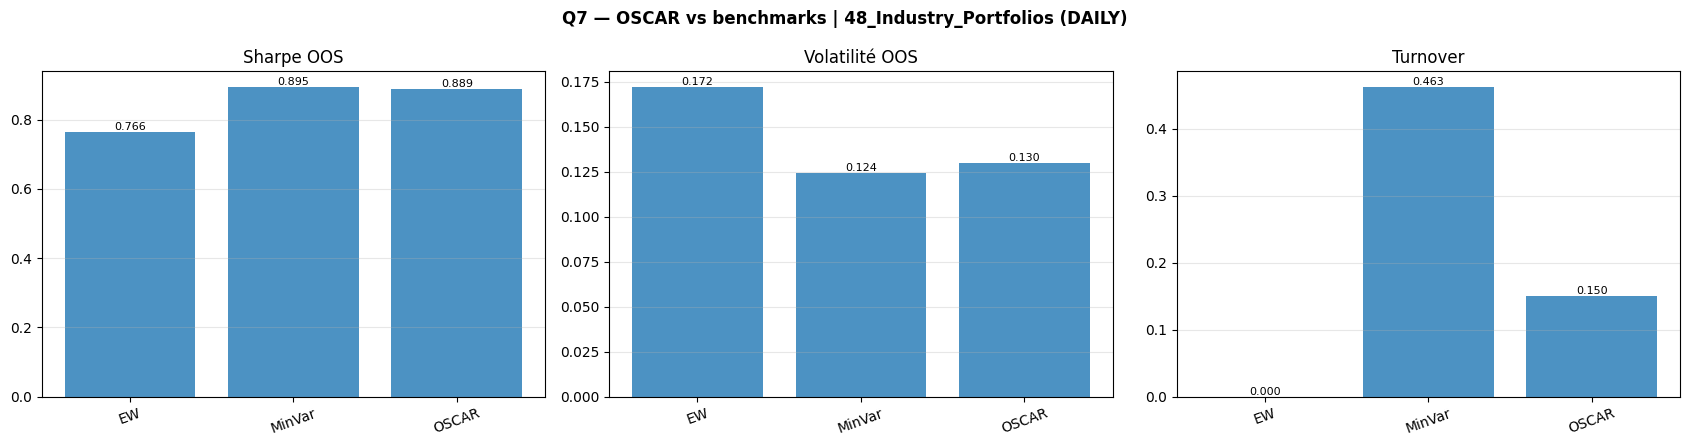

  Figure sauvegardée : q7_oscar_48_Industry_Portfolios_daily.png

  Paramètres OSCAR : alpha=0.0200, c=2.2050
  Clusters moyens : 12.34


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 1. OUTILS GÉNÉRAUX
# ============================================================

def infer_freq(key):
    return "monthly" if key.endswith("_monthly") else "daily"


def get_window_params(freq):
    return (120, 6) if freq == "monthly" else (2520, 126)


def annualize(mean_ret, vol_ret, freq):
    f = 12 if freq == "monthly" else 252
    ann_mean = mean_ret * f
    ann_vol = vol_ret * np.sqrt(f)
    ann_sr = ann_mean / ann_vol if ann_vol > 1e-12 else np.nan
    return ann_mean, ann_vol, ann_sr


def compute_performance(port_returns, freq):
    r = np.asarray(port_returns, dtype=float)
    ok = np.isfinite(r)

    if ok.sum() == 0:
        return {"Mean": np.nan, "Vol": np.nan, "Sharpe": np.nan, "FailRate": 1.0}

    rv = r[ok]
    ann_mean, ann_vol, ann_sr = annualize(
        np.mean(rv), np.std(rv, ddof=1), freq
    )

    return {
        "Mean": ann_mean,
        "Vol": ann_vol,
        "Sharpe": ann_sr,
        "FailRate": 1.0 - ok.sum() / len(r)
    }


def compute_turnover(weights_list):
    valid = [w for w in weights_list if w is not None and np.all(np.isfinite(w))]

    if len(valid) < 2:
        return np.nan

    return np.mean([
        np.sum(np.abs(valid[t] - valid[t - 1]))
        for t in range(1, len(valid))
    ])


# ============================================================
# 2. BENCHMARKS : EW ET MINVAR
# ============================================================

def compute_ew(N):
    return np.ones(N) / N


def compute_minvar_from_sigma(Sigma, tol=1e-10):
    Sigma = (Sigma + Sigma.T) / 2
    N = Sigma.shape[0]
    ones = np.ones(N)

    try:
        w = np.linalg.solve(Sigma, ones)
    except np.linalg.LinAlgError:
        w = np.linalg.pinv(Sigma) @ ones

    denom = ones @ w

    if abs(denom) < tol:
        return np.full(N, np.nan)

    return w / denom


def compute_oos_strategy(returns, freq, strategy):
    window, roll_step = get_window_params(freq)
    T, N = returns.shape

    oos_returns = []
    weights = []

    t = window
    while t < T:
        step = min(roll_step, T - t)

        train = returns.iloc[t - window:t]
        test = returns.iloc[t:t + step]

        if strategy == "EW":
            w = compute_ew(N)

        elif strategy == "MinVar":
            Sigma = train.cov().values
            w = compute_minvar_from_sigma(Sigma)

        else:
            raise ValueError("strategy doit être 'EW' ou 'MinVar'.")

        weights.append(w)

        if np.any(~np.isfinite(w)):
            oos_returns.extend([np.nan] * step)
        else:
            oos_returns.extend(test.values @ w)

        t += step

    return {
        "perf": compute_performance(oos_returns, freq),
        "turnover": compute_turnover(weights),
        "weights": weights
    }


# ============================================================
# 3. OSCAR —
# ============================================================

def oscar_norm_ew(N, alpha):
    return 1.0 + alpha * (N - 1) / 2.0


def oscar_norm_expr(w, alpha, N):

    abs_w = cp.abs(w)
    expr = cp.norm1(w)

    for k in range(1, N):
        expr += alpha * cp.sum_largest(abs_w, k)

    return expr


def solve_oscar(Sigma, alpha, c):
    Sigma = (Sigma + Sigma.T) / 2
    N = Sigma.shape[0]

    if c <= oscar_norm_ew(N, alpha):
        return np.full(N, np.nan), False

    w = cp.Variable(N)

    objective = cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma)))

    constraints = [
        cp.sum(w) == 1,
        oscar_norm_expr(w, alpha, N) <= c
    ]

    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(
            solver=cp.CLARABEL,
            verbose=False
        )

        if w.value is None or problem.status in ["infeasible", "unbounded"]:
            problem.solve(
                solver=cp.SCS,
                verbose=False,
                eps=1e-4,
                max_iters=4000
            )

        if w.value is None or problem.status in ["infeasible", "unbounded"]:
            return np.full(N, np.nan), False

        return np.asarray(w.value).flatten(), True

    except Exception:
        return np.full(N, np.nan), False


def count_clusters(w, threshold=1e-3):
    if np.any(~np.isfinite(w)):
        return np.nan

    vals = np.sort(np.abs(w))[::-1]
    vals = vals[vals > threshold]

    if len(vals) == 0:
        return 0

    clusters = 1
    ref = vals[0]

    for v in vals[1:]:
        if abs(v - ref) > threshold:
            clusters += 1
            ref = v

    return clusters


# ============================================================
# 4. CHOIX FIXE DES PARAMÈTRES OSCAR
# ============================================================

def choose_oscar_params(N, alpha=0.02, mult=1.50):

    c_min = oscar_norm_ew(N, alpha)
    c = c_min * mult
    return alpha, c


# ============================================================
# 5. OOS OSCAR RAPIDE
# ============================================================

def compute_oos_oscar_fast(
    returns,
    freq,
    alpha=0.02,
    mult=1.50
):
    window, roll_step = get_window_params(freq)
    T, N = returns.shape

    oos_returns = []
    weights = []
    params = []
    clusters = []

    alpha, c = choose_oscar_params(N, alpha=alpha, mult=mult)

    t = window
    win_count = 0

    while t < T:
        step = min(roll_step, T - t)

        train = returns.iloc[t - window:t]
        test = returns.iloc[t:t + step]

        Sigma = train.cov().values
        w, ok = solve_oscar(Sigma, alpha, c)

        weights.append(w)
        params.append((alpha, c))
        clusters.append(count_clusters(w))

        if not ok or np.any(~np.isfinite(w)):
            oos_returns.extend([np.nan] * step)
        else:
            oos_returns.extend(test.values @ w)

        win_count += 1
        if win_count <= 3 or win_count % 10 == 0:
            print(
                f"    OSCAR fenêtre {win_count:>3} | "
                f"alpha={alpha:.3f}, c={c:.3f} | "
                f"clusters={clusters[-1]}"
            )

        t += step

    return {
        "perf": compute_performance(oos_returns, freq),
        "turnover": compute_turnover(weights),
        "weights": weights,
        "params": params,
        "clusters": clusters
    }


# ============================================================
# 6. AFFICHAGE
# ============================================================

def print_q7_table(dataset_name, freq, results):
    print(f"\n{'=' * 86}")
    print(f"  Q7 — OSCAR | {dataset_name} | {freq.upper()}")
    print(f"{'=' * 86}")

    print(
        f"  {'Strategy':<18} {'Mean':>10} {'Vol':>10} "
        f"{'Sharpe':>10} {'Turnover':>10} {'FailRate':>10}"
    )
    print(f"  {'-' * 76}")

    for name, res in results.items():
        p = res["perf"]
        to = res["turnover"]

        print(
            f"  {name:<18} "
            f"{p['Mean']:>10.4f} "
            f"{p['Vol']:>10.4f} "
            f"{p['Sharpe']:>10.4f} "
            f"{to:>10.4f} "
            f"{p['FailRate']:>10.2%}"
        )


def plot_q7(dataset_name, freq, results):
    names = list(results.keys())

    sharpes = [results[n]["perf"]["Sharpe"] for n in names]
    vols = [results[n]["perf"]["Vol"] for n in names]
    turnovers = [results[n]["turnover"] for n in names]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    fig.suptitle(
        f"Q7 — OSCAR vs benchmarks | {dataset_name} ({freq.upper()})",
        fontsize=12,
        fontweight="bold"
    )

    for ax, values, title in zip(
        axes,
        [sharpes, vols, turnovers],
        ["Sharpe OOS", "Volatilité OOS", "Turnover"]
    ):
        ax.bar(names, values, alpha=0.8)
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=20)
        ax.grid(axis="y", alpha=0.3)

        for i, v in enumerate(values):
            if np.isfinite(v):
                ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    fname = f"q7_oscar_{dataset_name}_{freq}.png"
    plt.savefig(fname, dpi=160, bbox_inches="tight")
    plt.show()

    print(f"  Figure sauvegardée : {fname}")


# ============================================================
# 7. PIPELINE Q7
# ============================================================

def run_q7_one_dataset(
    key,
    returns,
    alpha=0.02,
    mult=1.50
):
    freq = infer_freq(key)
    dataset_name = key.replace("_monthly", "").replace("_daily", "")
    T, N = returns.shape

    print(f"\n{'█' * 70}")
    print(f"  Q7 OSCAR | {key} | T={T}, N={N}")
    print(f"{'█' * 70}")

    results = {}

    print("  [1/3] EW...")
    results["EW"] = compute_oos_strategy(returns, freq, "EW")

    print("  [2/3] MinVar...")
    results["MinVar"] = compute_oos_strategy(returns, freq, "MinVar")

    print("  [3/3] OSCAR rapide...")
    results["OSCAR"] = compute_oos_oscar_fast(
        returns,
        freq,
        alpha=alpha,
        mult=mult
    )

    print_q7_table(dataset_name, freq, results)
    plot_q7(dataset_name, freq, results)

    oscar_params = results["OSCAR"]["params"]
    oscar_clusters = np.array(results["OSCAR"]["clusters"], dtype=float)

    print(
        f"\n  Paramètres OSCAR : "
        f"alpha={oscar_params[0][0]:.4f}, "
        f"c={oscar_params[0][1]:.4f}"
    )

    print(
        f"  Clusters moyens : "
        f"{np.nanmean(oscar_clusters):.2f}"
    )

    return results


def run_question7(
    all_data,
    alpha=0.02,
    mult=1.50
):
    all_results_q7 = {}

    for key, returns in all_data.items():
        all_results_q7[key] = run_q7_one_dataset(
            key,
            returns,
            alpha=alpha,
            mult=mult
        )

    return all_results_q7


# ============================================================
# 8. LANCEMENT
# ============================================================

all_results_q7 = run_question7(
    all_data,
    alpha=0.02,
    mult=1.50
)

## **Question 8**

# **Partie Bonus**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# ============================================================
# 1. LOAD DATA
# ============================================================

import numpy as np
import pandas as pd
import cvxpy as cp
from sklearn.covariance import LedoitWolf
import warnings
warnings.filterwarnings("ignore")

def load_bonus_txt(path, start_date="1980-01-01"):
    df = pd.read_csv(path, sep=r"\s+", header=None, engine="python")
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    df.columns = [f"Stock_{i+1}" for i in range(df.shape[1])]
    df.index = pd.bdate_range(start=start_date, periods=len(df))

    return df


def daily_to_monthly_returns(daily_returns):
    monthly_returns = (1.0 + daily_returns).resample("M").prod() - 1.0
    monthly_returns = monthly_returns.replace([np.inf, -np.inf], np.nan)
    monthly_returns = monthly_returns.fillna(0.0)
    return monthly_returns


# ============================================================
# 2. PERFORMANCE METRICS
# ============================================================

def annualize(mean_ret, vol_ret, freq="monthly"):
    f = 12 if freq == "monthly" else 252
    ann_mean = mean_ret * f
    ann_vol = vol_ret * np.sqrt(f)
    sharpe = ann_mean / ann_vol if ann_vol > 1e-12 else np.nan
    return ann_mean, ann_vol, sharpe


def compute_performance(port_returns, freq="monthly"):
    r = np.asarray(port_returns, dtype=float)
    r = r[np.isfinite(r)]

    if len(r) == 0:
        return {"Mean": np.nan, "Vol": np.nan, "Sharpe": np.nan}

    ann_mean, ann_vol, sharpe = annualize(
        np.mean(r),
        np.std(r, ddof=1),
        freq=freq
    )

    return {"Mean": ann_mean, "Vol": ann_vol, "Sharpe": sharpe}


def print_performance_table(perf_mv, perf_ew):
    table = pd.DataFrame({
        "Strategy": ["Regularized Mean-Variance", "Equal-Weight"],
        "Annual Return": [perf_mv["Mean"], perf_ew["Mean"]],
        "Volatility": [perf_mv["Vol"], perf_ew["Vol"]],
        "Sharpe Ratio": [perf_mv["Sharpe"], perf_ew["Sharpe"]]
    })

    display = table.copy()
    display["Annual Return"] = display["Annual Return"].map(lambda x: f"{100*x:.2f}%")
    display["Volatility"] = display["Volatility"].map(lambda x: f"{100*x:.2f}%")
    display["Sharpe Ratio"] = display["Sharpe Ratio"].map(lambda x: f"{x:.3f}")

    print("\n" + "=" * 80)
    print("Out-of-Sample Performance on In-Sample Data 1980–2009")
    print("=" * 80)
    print(display.to_string(index=False))
    print("=" * 80)

    return table


# ============================================================
# 3. ROBUST INPUTS
# ============================================================

def make_psd(Sigma, eps=1e-8):
    """
    Rend la matrice symétrique et semi-définie positive.
    Corrige les petites valeurs propres négatives dues aux erreurs numériques.
    """
    Sigma = np.asarray(Sigma, dtype=float)
    Sigma = (Sigma + Sigma.T) / 2

    eigvals, eigvecs = np.linalg.eigh(Sigma)
    eigvals = np.maximum(eigvals, eps)

    Sigma_psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
    Sigma_psd = (Sigma_psd + Sigma_psd.T) / 2

    return Sigma_psd


def estimate_robust_inputs(returns, mean_shrink=0.50):
    X = returns.values

    mu_sample = returns.mean().values
    grand_mean = np.mean(mu_sample)

    mu_robust = (1.0 - mean_shrink) * mu_sample + mean_shrink * grand_mean

    lw = LedoitWolf().fit(X)
    Sigma_lw = lw.covariance_
    Sigma_lw = make_psd(Sigma_lw)

    return mu_robust, Sigma_lw


# ============================================================
# 4. REGULARIZED MEAN-VARIANCE OPTIMIZATION
# ============================================================

def solve_regularized_mean_variance(
    mu,
    Sigma,
    risk_aversion=10.0,
    ridge=1e-3,
    long_only=True,
    max_weight=0.05
):
    N = len(mu)

    Sigma = make_psd(Sigma)
    Sigma_cvx = cp.psd_wrap(Sigma)

    w = cp.Variable(N)

    objective = cp.Maximize(
        mu @ w
        - risk_aversion * cp.quad_form(w, Sigma_cvx)
        - ridge * cp.sum_squares(w)
    )

    constraints = [cp.sum(w) == 1]

    if long_only:
        constraints.append(w >= 0)

    if max_weight is not None:
        constraints.append(w <= max_weight)

    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(
            solver=cp.CLARABEL,
            verbose=False
        )
    except Exception:
        problem.solve(
            solver=cp.SCS,
            verbose=False,
            eps=1e-5,
            max_iters=20000
        )

    if w.value is None:
        return np.full(N, np.nan)

    weights = np.asarray(w.value).flatten()

    weights[weights < 1e-10] = 0.0

    if not np.all(np.isfinite(weights)) or weights.sum() <= 1e-12:
        return np.full(N, np.nan)

    weights = weights / weights.sum()

    return weights


def compute_equal_weight(N):
    return np.ones(N) / N


# ============================================================
# 5. ROLLING BACKTEST ON 1980–2009
# ============================================================

def rolling_backtest(
    monthly_returns,
    window_years=10,
    test_months=12,
    mean_shrink=0.50,
    risk_aversion=10.0,
    ridge=1e-3,
    max_weight=0.05
):
    window = 12 * window_years
    T, N = monthly_returns.shape

    mv_returns = []
    ew_returns = []
    weights_list = []

    t = window

    while t < T:
        step = min(test_months, T - t)

        train = monthly_returns.iloc[t-window:t]
        test = monthly_returns.iloc[t:t+step]

        mu, Sigma = estimate_robust_inputs(train, mean_shrink=mean_shrink)

        w_mv = solve_regularized_mean_variance(
            mu,
            Sigma,
            risk_aversion=risk_aversion,
            ridge=ridge,
            long_only=True,
            max_weight=max_weight
        )

        if np.any(~np.isfinite(w_mv)):
            mv_returns.extend([np.nan] * step)
        else:
            mv_returns.extend(test.values @ w_mv)

        w_ew = compute_equal_weight(N)
        ew_returns.extend(test.values @ w_ew)

        weights_list.append(w_mv)

        t += step

    perf_mv = compute_performance(mv_returns, freq="monthly")
    perf_ew = compute_performance(ew_returns, freq="monthly")

    return perf_mv, perf_ew, weights_list


# ============================================================
# 6. GRID SEARCH
# ============================================================

def tune_parameters(monthly_returns):
    grid = []

    for mean_shrink in [0.30, 0.50, 0.70, 0.90]:
        for risk_aversion in [5, 10, 20, 40]:
            for ridge in [1e-4, 1e-3, 1e-2]:
                for max_weight in [0.03, 0.05, 0.08]:
                    grid.append((mean_shrink, risk_aversion, ridge, max_weight))

    results = []

    for i, (mean_shrink, risk_aversion, ridge, max_weight) in enumerate(grid, 1):
        perf_mv, perf_ew, _ = rolling_backtest(
            monthly_returns,
            mean_shrink=mean_shrink,
            risk_aversion=risk_aversion,
            ridge=ridge,
            max_weight=max_weight
        )

        results.append({
            "mean_shrink": mean_shrink,
            "risk_aversion": risk_aversion,
            "ridge": ridge,
            "max_weight": max_weight,
            "Mean": perf_mv["Mean"],
            "Vol": perf_mv["Vol"],
            "Sharpe": perf_mv["Sharpe"],
            "EW_Sharpe": perf_ew["Sharpe"]
        })

        if i % 20 == 0:
            print(f"  Paramètres testés : {i}/{len(grid)}")

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("Sharpe", ascending=False)

    return results_df


# ============================================================
# 7. FINAL PORTFOLIO
# ============================================================

def compute_final_bonus_weights(monthly_returns, best_params):
    mu, Sigma = estimate_robust_inputs(
        monthly_returns,
        mean_shrink=best_params["mean_shrink"]
    )

    weights = solve_regularized_mean_variance(
        mu,
        Sigma,
        risk_aversion=best_params["risk_aversion"],
        ridge=best_params["ridge"],
        long_only=True,
        max_weight=best_params["max_weight"]
    )

    return weights


# ============================================================
# 8. SAVE EXCEL
# ============================================================

def save_bonus_weights(weights, columns, output_path="portfolio_weights_q1.xlsx"):
    weights_df = pd.DataFrame({
        "Asset": columns,
        "Weight": weights
    })

    weights_df.to_excel(output_path, index=False)

    print(f"\nFichier sauvegardé : {output_path}")
    print(f"Somme des poids : {weights.sum():.8f}")
    print(f"Poids min : {weights.min():.6f}")
    print(f"Poids max : {weights.max():.6f}")
    print(f"Nombre de poids positifs : {(weights > 1e-8).sum()}")

    return weights_df


# ============================================================
# 9. MAIN PIPELINE
# ============================================================

def run_bonus_strategy(
    input_txt_path,
    output_excel_path="portfolio_weights_q1.xlsx"
):
    daily_returns = load_bonus_txt(input_txt_path)
    print("Données journalières :", daily_returns.shape)

    monthly_returns = daily_to_monthly_returns(daily_returns)
    print("Données mensuelles :", monthly_returns.shape)

    print("\nTuning des paramètres...")
    tuning_results = tune_parameters(monthly_returns)

    print("\nTop 10 paramètres :")
    print(tuning_results.head(10).to_string(index=False))

    best_params = tuning_results.iloc[0].to_dict()

    print("\nParamètres retenus :")
    print(best_params)

    perf_mv, perf_ew, _ = rolling_backtest(
        monthly_returns,
        mean_shrink=best_params["mean_shrink"],
        risk_aversion=best_params["risk_aversion"],
        ridge=best_params["ridge"],
        max_weight=best_params["max_weight"]
    )

    performance_table = print_performance_table(perf_mv, perf_ew)
    performance_table.to_excel("bonus_internal_performance.xlsx", index=False)

    final_weights = compute_final_bonus_weights(
        monthly_returns,
        best_params
    )

    weights_df = save_bonus_weights(
        final_weights,
        monthly_returns.columns,
        output_path=output_excel_path
    )

    tuning_results.to_excel("bonus_tuning_results.xlsx", index=False)

    return weights_df, final_weights, tuning_results, performance_table



input_path = "/content/drive/MyDrive/In-sample data.txt"

weights_df, final_weights, tuning_results, performance_table = run_bonus_strategy(
    input_txt_path=input_path,
    output_excel_path="portfolio_weights_q1_2.xlsx"
)

Données journalières : (7560, 300)
Données mensuelles : (348, 300)

Tuning des paramètres...
  Paramètres testés : 20/144
  Paramètres testés : 40/144
  Paramètres testés : 60/144
  Paramètres testés : 80/144
  Paramètres testés : 100/144
  Paramètres testés : 120/144
  Paramètres testés : 140/144

Top 10 paramètres :
 mean_shrink  risk_aversion  ridge  max_weight     Mean      Vol   Sharpe  EW_Sharpe
         0.3              5 0.0100        0.03 0.195520 0.158908 1.230393   1.241142
         0.3              5 0.0010        0.03 0.195791 0.159442 1.227974   1.241142
         0.3              5 0.0001        0.03 0.195806 0.159485 1.227736   1.241142
         0.3              5 0.0100        0.05 0.195290 0.165608 1.179228   1.241142
         0.5              5 0.0100        0.03 0.188322 0.160385 1.174189   1.241142
         0.3              5 0.0010        0.05 0.195668 0.166835 1.172826   1.241142
         0.3              5 0.0001        0.05 0.195660 0.166956 1.171923   1.241142


In [ ]:
import os
from google.colab import files
!zip -r toutes_mes_figures_projet.zip *.png

files.download('toutes_mes_figures_projet.zip')